Loading new factor file: density0.0333_damping0.005_0S125_bias_summary.pkl
Loading new factor file: density0.0333_damping0.005_0S456_bias_summary.pkl
Loading new factor file: density0.0333_damping0.005_0S_bias_summary.pkl
Loading new factor file: density0.0333_damping0.010_0S125_bias_summary.pkl
Loading new factor file: density0.0333_damping0.010_0S456_bias_summary.pkl
Loading new factor file: density0.0333_damping0.010_0S_bias_summary.pkl
Loading new factor file: density0.0333_damping0.015_0S_bias_summary.pkl
Loading new factor file: density0.0333_damping0.020_0S125_bias_summary.pkl
Loading new factor file: density0.0333_damping0.020_0S456_bias_summary.pkl
Loading new factor file: density0.0333_damping0.020_0S_bias_summary.pkl
Loading new factor file: density0.0333_damping0.025_0S_bias_summary.pkl
Loading new factor file: density0.0333_damping0.030_0S_bias_summary.pkl
Loading new factor file: density0.1667_damping0.005_0S125_bias_summary.pkl
Loading new factor file: density0.1667_damp

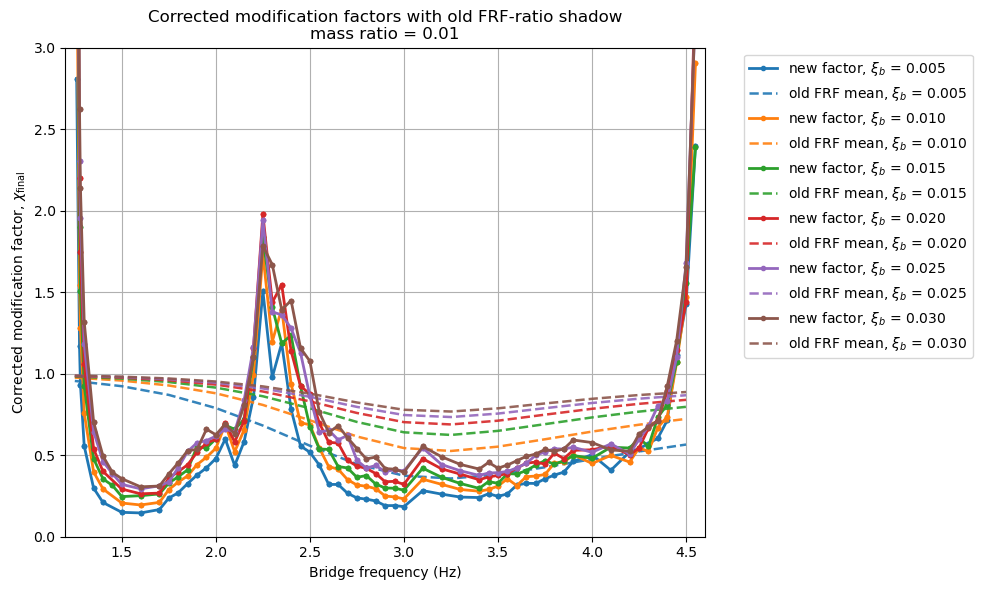

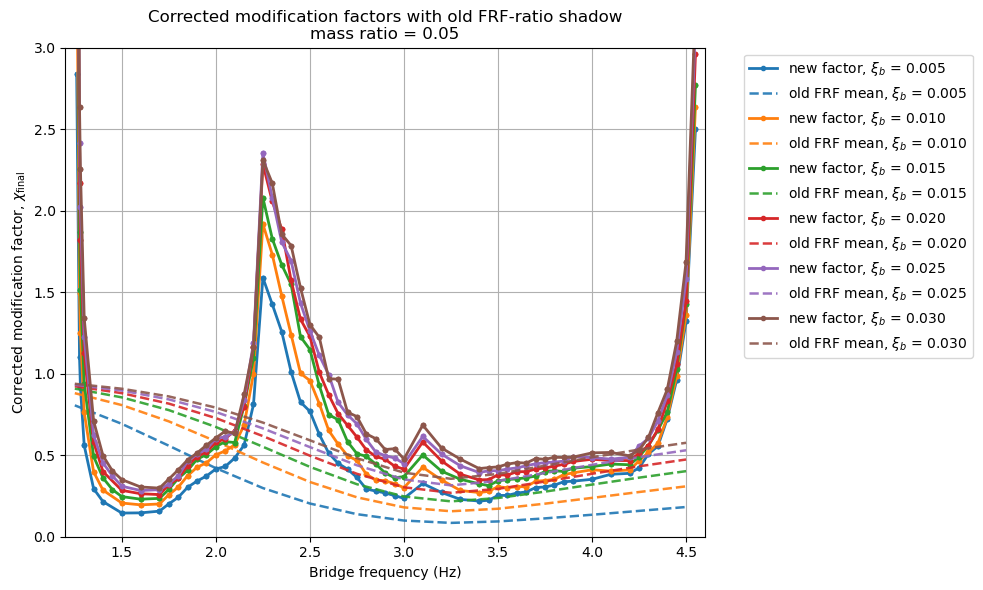

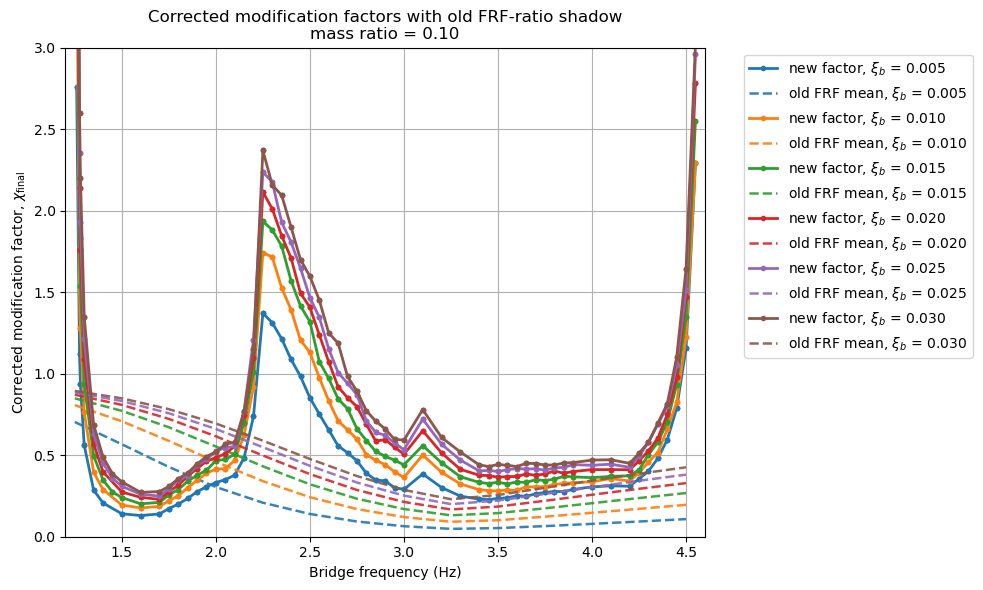

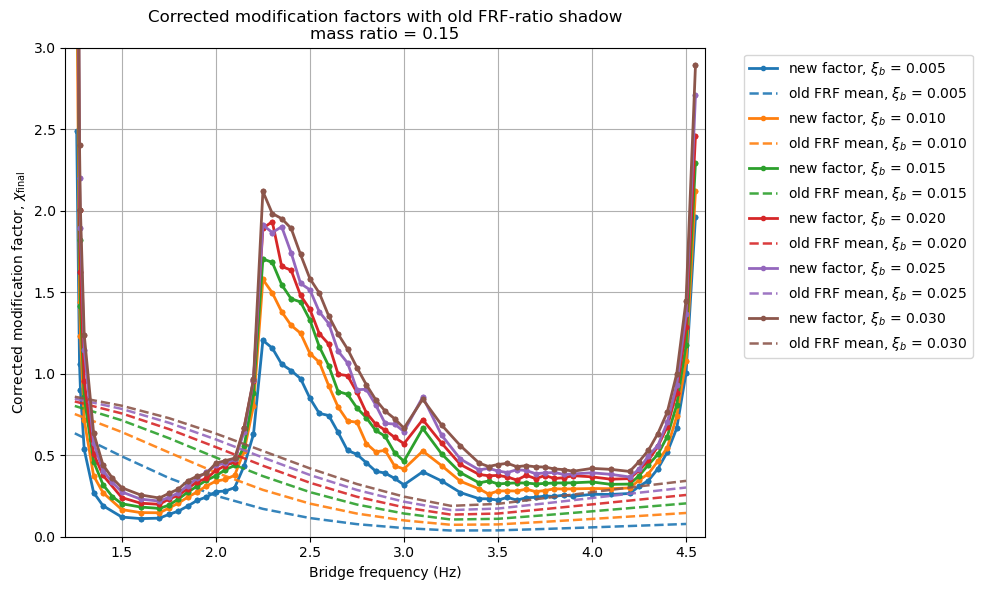

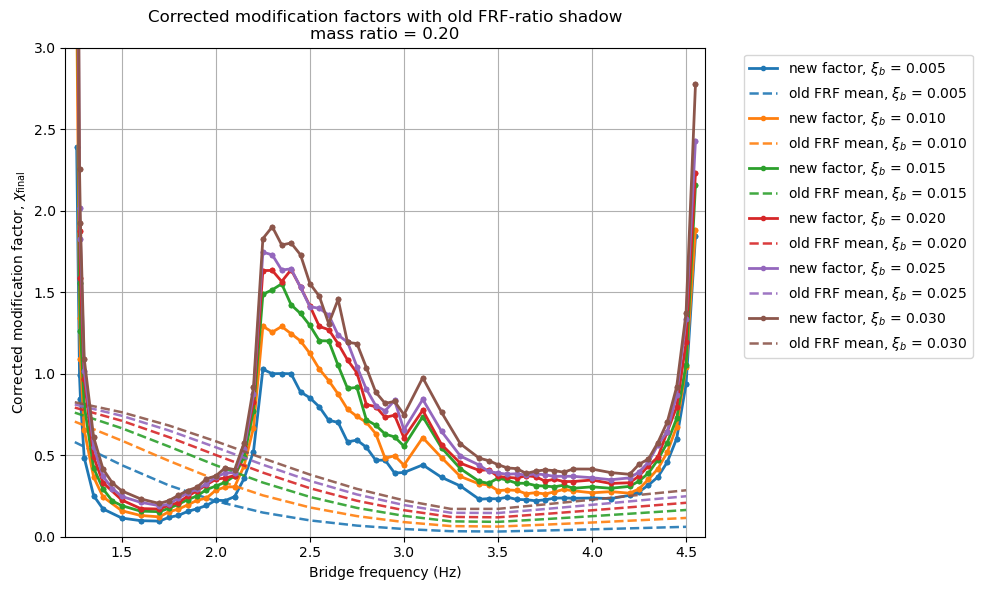

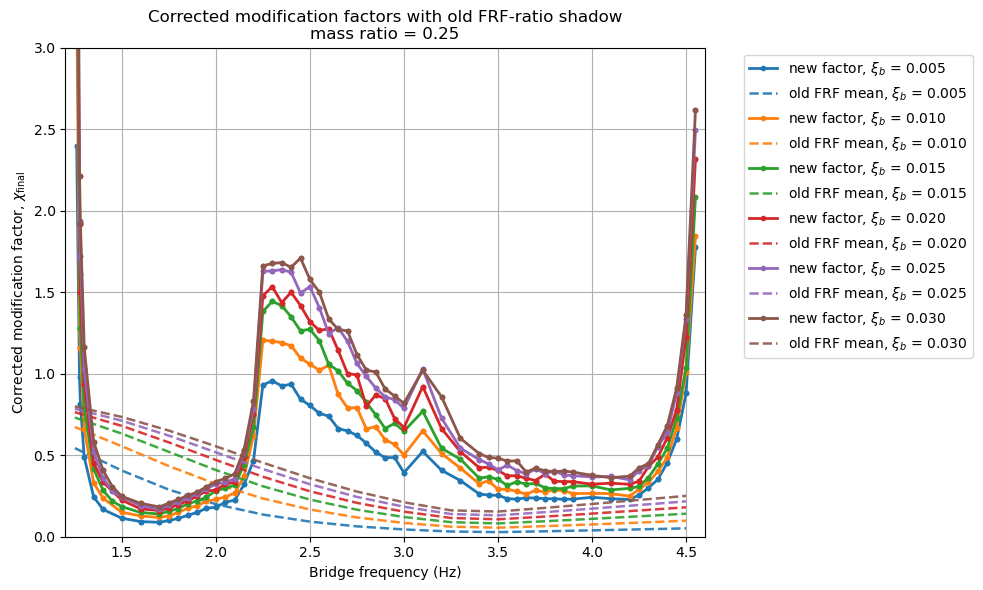

In [2]:
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ==================================================
# SETTINGS
# ==================================================

folder = Path(".")

PLOT_COLUMN = "final_modification_factor"
MEASURE_TO_PLOT = None

OLD_FRF_PKL = folder / "forcefactors_bridgeF_bridgedamp.pkl"

DAMPINGS_TO_COMPARE = [0.005, 0.010, 0.015, 0.020, 0.025, 0.030]

# Old FRF suggestion only for densities < 1
MAX_DENSITY_FOR_OLD_FRF = 1.0

SAVE_PLOTS = False

density_to_mass_ratio = {
    0.0333: 0.01,
    0.1667: 0.05,
    0.3333: 0.10,
    0.5000: 0.15,
    0.6667: 0.20,
    0.8333: 0.25,
    1.0000: 0.30,
}

ylabel_map = {
    "final_modification_factor": r"Corrected modification factor, $\chi_{\mathrm{final}}$",
    "initial_modification_factor": r"Initial modification factor, $\chi_0$",
    "residual_correction_factor": r"Residual correction factor, $\lambda$",
    "code_bias_mean": "Mean code bias",
    "simplified_bias_mean": "Mean simplified bias",
    "corrected_bias_mean": "Mean corrected bias",
}

ylabel = ylabel_map.get(PLOT_COLUMN, PLOT_COLUMN.replace("_", " "))

# ==================================================
# LOAD NEW CORRECTED MODIFICATION FACTORS
# ==================================================

pattern = re.compile(
    r"density(?P<density>\d+\.\d+)_"
    r"damping(?P<damping>\d+\.\d+)_"
    r"(?P<region>0S(?:125|456)?)_bias_summary\.pkl$"
)

pkl_files = sorted(folder.glob("density*_damping*_0S*_bias_summary.pkl"))

all_dfs = []

for file in pkl_files:
    match = pattern.match(file.name)

    if match is None:
        print(f"Skipping file because name does not match expected format: {file.name}")
        continue

    file_density = float(match.group("density"))
    file_damping = float(match.group("damping"))
    file_region = match.group("region")

    print("Loading new factor file:", file.name)

    with open(file, "rb") as f:
        df = pickle.load(f)

    if not isinstance(df, pd.DataFrame):
        df = pd.DataFrame(df)

    df = df.copy()

    df["source_file"] = file.name
    df["file_density"] = file_density
    df["file_damping"] = file_damping
    df["file_region"] = file_region

    if "target_density" not in df.columns:
        df["target_density"] = file_density

    if "target_beamdamp" not in df.columns:
        df["target_beamdamp"] = file_damping

    all_dfs.append(df)

if len(all_dfs) == 0:
    raise FileNotFoundError("No matching new modification-factor summary files were found.")

corrected_df = pd.concat(all_dfs, ignore_index=True)

needed_cols = [
    "bridge_frequency",
    "target_density",
    "target_beamdamp",
    PLOT_COLUMN,
]

for col in needed_cols:
    corrected_df[col] = pd.to_numeric(corrected_df[col], errors="coerce")

corrected_df = corrected_df.dropna(subset=needed_cols).copy()

corrected_df["density_key"] = corrected_df["target_density"].round(4)
corrected_df["damping_key"] = corrected_df["target_beamdamp"].round(3)

if MEASURE_TO_PLOT is not None:
    if "measure" not in corrected_df.columns:
        raise KeyError("MEASURE_TO_PLOT is set, but dataframe has no 'measure' column.")

    corrected_df = corrected_df[
        corrected_df["measure"].astype(str) == MEASURE_TO_PLOT
    ].copy()

    if corrected_df.empty:
        raise ValueError(f"No rows found for measure: {MEASURE_TO_PLOT}")

# Keep the intended frequency ranges from 0S, 0S125, and 0S456
# ==================================================
# KEEP FREQUENCY REGIONS INTELLIGENTLY
# ==================================================
# For old damping cases, you may have:
#   0S125 = low range
#   0S    = middle range
#   0S456 = high range
#
# For newer damping cases, such as 0.015, 0.025, 0.030,
#   0S already contains the full frequency range.
#
# Therefore:
#   - if only 0S exists for a density/damping case, keep all 0S frequencies
#   - if 0S125/0S456 also exist, stitch the regions as before

stitched_parts = []

for (damp_key, density_key), g in corrected_df.groupby(["damping_key", "density_key"]):

    available_regions = set(g["file_region"].dropna().unique())

    # Case A: only 0S exists -> keep full range
    if available_regions == {"0S"}:
        stitched_parts.append(g.copy())
        continue

    # Case B: multiple regional files exist -> stitch them
    g_keep = g[
        (
            (g["file_region"] == "0S125") &
            (g["bridge_frequency"] < 1.40)
        )
        |
        (
            (g["file_region"] == "0S") &
            (g["bridge_frequency"] >= 1.40) &
            (g["bridge_frequency"] <= 3.40)
        )
        |
        (
            (g["file_region"] == "0S456") &
            (g["bridge_frequency"] > 3.40)
        )
    ].copy()

    # Safety fallback:
    # If stitching removed everything for some unexpected naming case,
    # keep all available rows.
    if g_keep.empty:
        print(
            f"Warning: stitching removed all rows for "
            f"damping={damp_key}, density={density_key}. Keeping all rows."
        )
        g_keep = g.copy()

    stitched_parts.append(g_keep)

corrected_df = pd.concat(stitched_parts, ignore_index=True)


        
corrected_df = corrected_df.sort_values(
    ["damping_key", "density_key", "bridge_frequency"]
)

# Remove duplicates from multiple response measures
# ==================================================
# KEEP ALL RESPONSE MEASURES
# Remove only true duplicate rows
# ==================================================

corrected_df["measure"] = corrected_df["measure"].astype(str).str.strip()

corrected_df = corrected_df.drop_duplicates(
    subset=[
        "damping_key",
        "density_key",
        "bridge_frequency",
        "measure",
    ],
    keep="first"
).copy()

print("\nMeasure coverage after keeping all measures:")
print(corrected_df["measure"].value_counts().to_string())
# Keep only the damping ratios we want
corrected_df = corrected_df[
    corrected_df["damping_key"].isin([round(x, 3) for x in DAMPINGS_TO_COMPARE])
].copy()

print("\nNew corrected-factor coverage:")
print(
    corrected_df
    .groupby(["damping_key", "density_key"])["bridge_frequency"]
    .agg(["min", "max", "count"])
    .reset_index()
)

# ==================================================
# LOAD OLD FRF-RATIO PKL
# Your saved structure:
# results_all[beamdamp][bf][density]["accel_ratio"]
# ==================================================

if not OLD_FRF_PKL.exists():
    raise FileNotFoundError(f"Old FRF-ratio pkl not found: {OLD_FRF_PKL}")

with open(OLD_FRF_PKL, "rb") as f:
    old_data = pickle.load(f)

results_all = old_data["results_all"]

print("\nLoaded old FRF-ratio file:", OLD_FRF_PKL.name)
print("Saved damping values:", old_data.get("damping_values", "not found"))
print("Saved densities:", old_data.get("densities", "not found"))
print("Saved NUM_SIMULATIONS:", old_data.get("NUM_SIMULATIONS", "not found"))

# ==================================================
# EXTRACT OLD FRF RATIOS DIRECTLY FROM NESTED DICT
# ==================================================

frf_rows = []

for beamdamp, freq_dict in results_all.items():

    beamdamp_float = float(beamdamp)

    for bf, density_dict in freq_dict.items():

        bf_float = float(bf)

        for density, data in density_dict.items():

            density_float = float(density)

            if not isinstance(data, dict):
                print(f"Skipping non-dict entry: damping={beamdamp}, bf={bf}, density={density}")
                continue

            if "accel_ratio" not in data:
                print(f"Skipping entry with no accel_ratio: damping={beamdamp}, bf={bf}, density={density}")
                continue

            accel_values = np.asarray(data["accel_ratio"], dtype=float).ravel()

            for sim_id, accel_ratio in enumerate(accel_values):
                if np.isfinite(accel_ratio):
                    frf_rows.append({
                        "target_beamdamp": beamdamp_float,
                        "bridge_frequency": bf_float,
                        "target_density": density_float,
                        "simulation": sim_id,
                        "accel_ratio": float(accel_ratio),
                    })

frf_df = pd.DataFrame(frf_rows)

if frf_df.empty:
    raise ValueError("No old FRF accel_ratio values were extracted.")

frf_df["density_key"] = frf_df["target_density"].round(4)
frf_df["damping_key"] = frf_df["target_beamdamp"].round(3)

# Keep only the damping ratios we want
frf_df = frf_df[
    frf_df["damping_key"].isin([round(x, 3) for x in DAMPINGS_TO_COMPARE])
].copy()

# Old FRF overlay only for densities < 1
frf_df = frf_df[
    frf_df["target_density"] < MAX_DENSITY_FOR_OLD_FRF
].copy()

frf_summary = (
    frf_df
    .groupby(["damping_key", "density_key", "bridge_frequency"])["accel_ratio"]
    .agg(
        frf_mean="mean",
        frf_p5=lambda x: np.percentile(x, 5),
        frf_p50="median",
        frf_p95=lambda x: np.percentile(x, 95),
        n="count",
    )
    .reset_index()
)

print("\nOld FRF-ratio summary coverage:")
print(
    frf_summary
    .groupby(["damping_key", "density_key"])["bridge_frequency"]
    .agg(["min", "max", "count"])
    .reset_index()
)

# ==================================================
# PLOT: ONE FIGURE PER MASS RATIO, COMPARE 3 DAMPINGS
# ==================================================

for density in sorted(corrected_df["density_key"].dropna().unique()):

    # You said the FRF comparison is for densities less than 1
    if density >= MAX_DENSITY_FOR_OLD_FRF:
        continue

    mr = density_to_mass_ratio.get(round(float(density), 4), None)

    if mr is not None:
        title_density = f"mass ratio = {mr:.2f}"
        out_density = f"massratio{mr:.2f}"
    else:
        title_density = f"density = {density:.4f}"
        out_density = f"density{density:.4f}"

    plt.figure(figsize=(10, 6))

    for damp in DAMPINGS_TO_COMPARE:

        damp_key = round(damp, 3)

        # ---------------- New corrected factor ----------------
        sub = corrected_df[
            np.isclose(corrected_df["density_key"], density) &
            np.isclose(corrected_df["damping_key"], damp_key)
        ].copy()

        sub = sub.sort_values("bridge_frequency")

        if sub.empty:
            print(f"No corrected factor data for density={density:.4f}, damping={damp:.3f}")
            continue

        line = plt.plot(
            sub["bridge_frequency"].values,
            sub[PLOT_COLUMN].values,
            marker="o",
            markersize=3,
            linewidth=2,
            label=rf"new factor, $\xi_b$ = {damp:.3f}",
        )[0]

        line_color = line.get_color()

        # ---------------- Old FRF-ratio shadow ----------------
        frf_sub = frf_summary[
            np.isclose(frf_summary["density_key"], density) &
            np.isclose(frf_summary["damping_key"], damp_key)
        ].copy()

        # Limit old FRF to the plot frequency range
        frf_sub = frf_sub[
            (frf_sub["bridge_frequency"] >= 1.2) &
            (frf_sub["bridge_frequency"] <= 4.6)
        ].copy()

        frf_sub = frf_sub.sort_values("bridge_frequency")

        if not frf_sub.empty:
            plt.fill_between(
                frf_sub["bridge_frequency"].values,
                frf_sub["frf_p5"].values,
                frf_sub["frf_p95"].values,
                color=line_color,
                alpha=0.15,
                linewidth=0,
            )

            plt.plot(
                frf_sub["bridge_frequency"].values,
                frf_sub["frf_mean"].values,
                linestyle="--",
                linewidth=1.8,
                color=line_color,
                alpha=0.9,
                label=rf"old FRF mean, $\xi_b$ = {damp:.3f}",
            )
        else:
            print(f"No old FRF data for density={density:.4f}, damping={damp:.3f}")

    plt.xlabel("Bridge frequency (Hz)")
    plt.xlim(1.2, 4.6)

    plt.ylabel(ylabel)
    plt.ylim(0, 3.0)

    plt.title(
        "Corrected modification factors with old FRF-ratio shadow\n"
        + title_density
    )

    plt.grid(True)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()

    if SAVE_PLOTS:
        outname = f"compare_damping_old_FRF_shadow_{out_density}.png"
        plt.savefig(outname, dpi=300, bbox_inches="tight")
        print("Saved:", outname)

    plt.show()


Damping ratios to fit:
[np.float64(0.005), np.float64(0.01), np.float64(0.015), np.float64(0.02), np.float64(0.025), np.float64(0.03)]

Available data coverage:
 damping_key  density_key  min  max  count
       0.005       0.0333 1.26 4.55    177
       0.005       0.1667 1.26 4.55    177
       0.005       0.3333 1.26 4.55    177
       0.005       0.5000 1.26 4.55    177
       0.005       0.6667 1.26 4.55    177
       0.005       0.8333 1.26 4.55    177
       0.005       1.0000 1.30 4.55    168
       0.010       0.0333 1.26 4.55    177
       0.010       0.1667 1.26 4.55    177
       0.010       0.3333 1.26 4.55    177
       0.010       0.5000 1.26 4.55    177
       0.010       0.6667 1.26 4.55    177
       0.010       0.8333 1.26 4.55    177
       0.010       1.0000 1.26 4.55    177
       0.015       0.0333 1.26 4.55    180
       0.015       0.1667 1.26 4.55    180
       0.015       0.3333 1.26 4.55    180
       0.015       0.5000 1.26 4.55    180
       0.015       0.

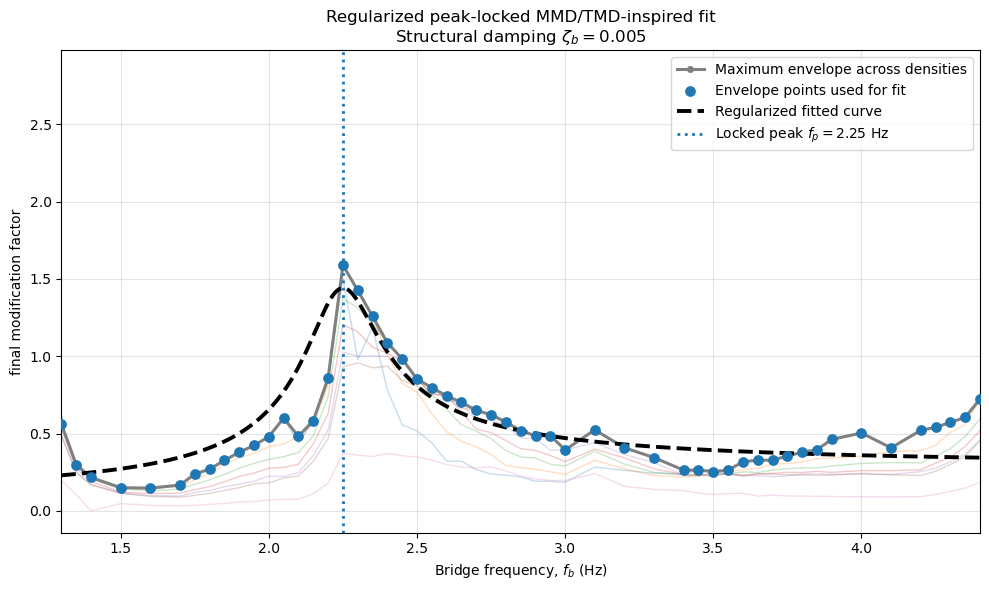


Fitting damping = 0.010
Number of fitting points: 53
Fitting frequency range: 1.3 to 4.4

Reference parameters from smooth equations
------------------------------------------
y0_ref      = 0.14922300
B_ref       = 2.14828000e-01
mu_ref      = 0.16605900
alpha_ref   = 0.55733900
zeta_a_ref  = 0.37235100

Initial guesses
----------------
y0       = 0.18457658
B        = 1.66862507e-01
mu       = 0.16605900
alpha    = 0.55733900
zeta_a   = 0.37235100
beta_p0  = 1.01213536

Bounds used
------------
lower = [0.       0.       0.131059 0.5      0.312351]
upper = [9.59279159e+00 1.00000000e+06 2.01059000e-01 6.37339000e-01
 4.32351000e-01]

Fitted parameters: regularized peak-locked B model
--------------------------------------------------
y0              = 0.13934773
B               = 1.96405776e-01
mu              = 0.17460887
alpha           = 0.55361355
zeta_b          = 0.01000000 fixed
zeta_a          = 0.33539075
beta_p          = 1.01726954
Q(beta_p)       = 8.21500924
A equivalent

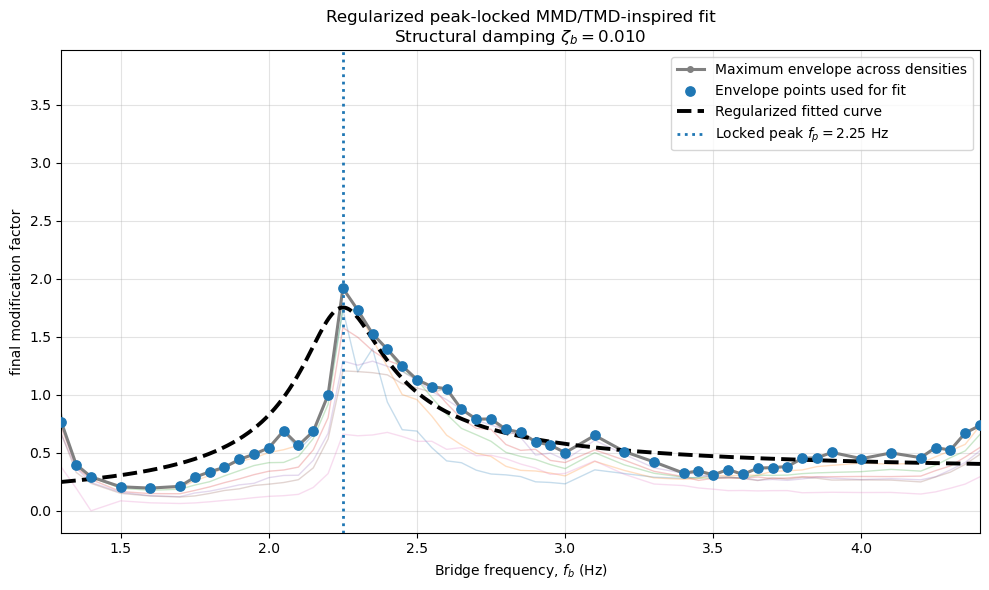


Fitting damping = 0.015
Number of fitting points: 54
Fitting frequency range: 1.3 to 4.4

Reference parameters from smooth equations
------------------------------------------
y0_ref      = 0.17073450
B_ref       = 2.60642000e-01
mu_ref      = 0.15398850
alpha_ref   = 0.59245850
zeta_a_ref  = 0.35467650

Initial guesses
----------------
y0       = 0.19586185
B        = 1.99242646e-01
mu       = 0.15398850
alpha    = 0.59245850
zeta_a   = 0.35467650
beta_p0  = 1.01540257

Bounds used
------------
lower = [0.        0.        0.1189885 0.5124585 0.2946765]
upper = [1.04008067e+01 1.00000000e+06 1.88988500e-01 6.72458500e-01
 4.14676500e-01]

Fitted parameters: regularized peak-locked B model
--------------------------------------------------
y0              = 0.12019828
B               = 2.39667951e-01
mu              = 0.16608910
alpha           = 0.59412479
zeta_b          = 0.01500000 fixed
zeta_a          = 0.29690885
beta_p          = 1.02473746
Q(beta_p)       = 7.54299157
A equiv

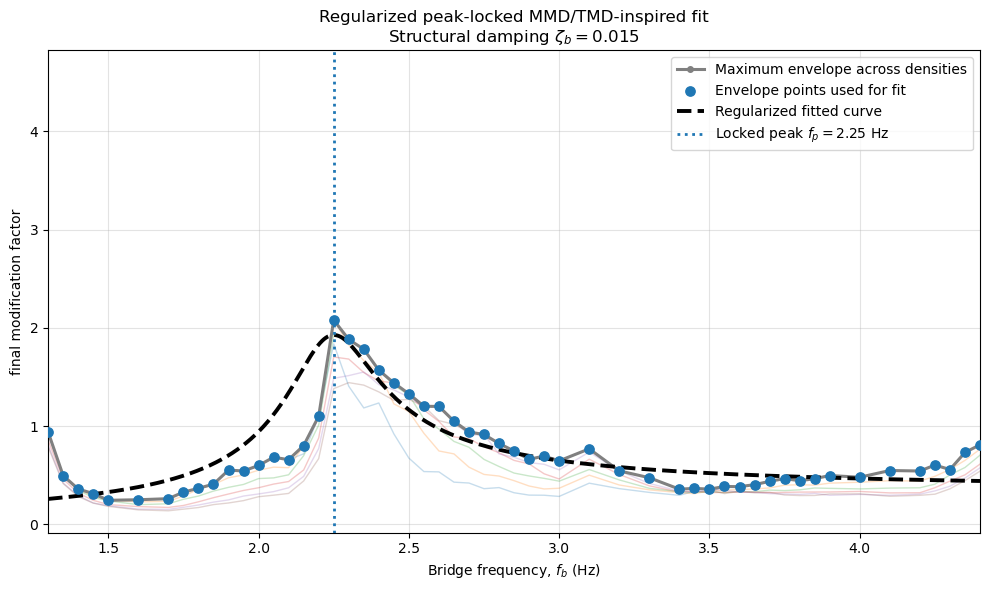


Fitting damping = 0.020
Number of fitting points: 53
Fitting frequency range: 1.3 to 4.4

Reference parameters from smooth equations
------------------------------------------
y0_ref      = 0.19224600
B_ref       = 3.06456000e-01
mu_ref      = 0.14191800
alpha_ref   = 0.62757800
zeta_a_ref  = 0.33700200

Initial guesses
----------------
y0       = 0.19781183
B        = 2.25501066e-01
mu       = 0.14191800
alpha    = 0.62757800
zeta_a   = 0.33700200
beta_p0  = 1.01820303

Bounds used
------------
lower = [0.       0.       0.106918 0.547578 0.277002]
upper = [1.14361058e+01 1.00000000e+06 1.76918000e-01 7.07578000e-01
 3.97002000e-01]

Fitted parameters: regularized peak-locked B model
--------------------------------------------------
y0              = 0.10041851
B               = 2.78166016e-01
mu              = 0.15456001
alpha           = 0.61679558
zeta_b          = 0.02000000 fixed
zeta_a          = 0.29694775
beta_p          = 1.02567095
Q(beta_p)       = 6.96827895
A equivalent

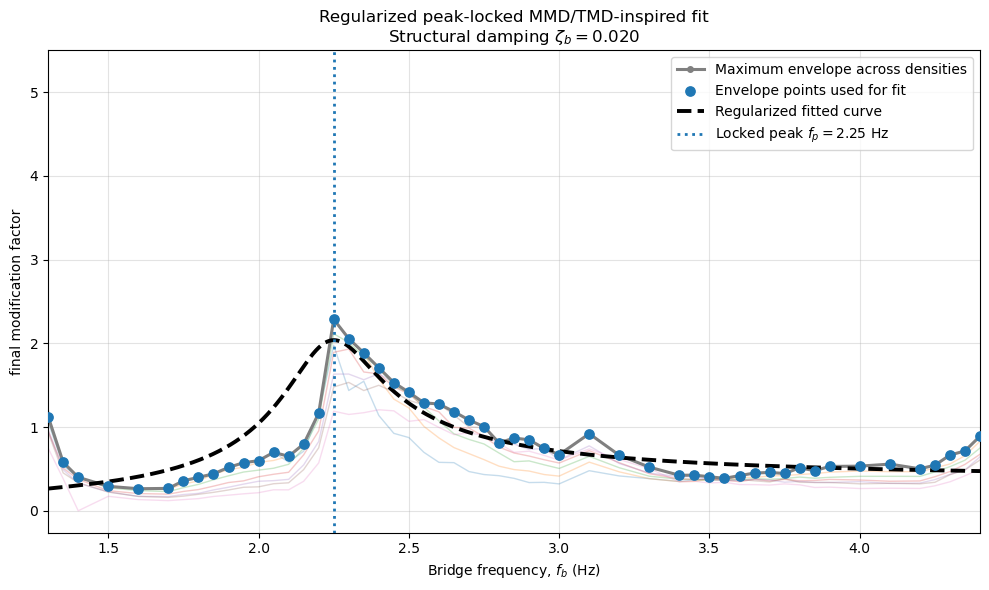


Fitting damping = 0.025
Number of fitting points: 54
Fitting frequency range: 1.3 to 4.4

Reference parameters from smooth equations
------------------------------------------
y0_ref      = 0.21375750
B_ref       = 3.52270000e-01
mu_ref      = 0.12984750
alpha_ref   = 0.66269750
zeta_a_ref  = 0.31932750

Initial guesses
----------------
y0       = 0.20698616
B        = 2.46436668e-01
mu       = 0.12984750
alpha    = 0.66269750
zeta_a   = 0.31932750
beta_p0  = 1.02193699

Bounds used
------------
lower = [0.        0.        0.0948475 0.5826975 0.2593275]
upper = [1.17730019e+01 1.00000000e+06 1.64847500e-01 7.42697500e-01
 3.79327500e-01]

Fitted parameters: regularized peak-locked B model
--------------------------------------------------
y0              = 0.07181675
B               = 3.24310757e-01
mu              = 0.14813201
alpha           = 0.66407763
zeta_b          = 0.02500000 fixed
zeta_a          = 0.26549021
beta_p          = 1.03547258
Q(beta_p)       = 6.26422923
A equiv

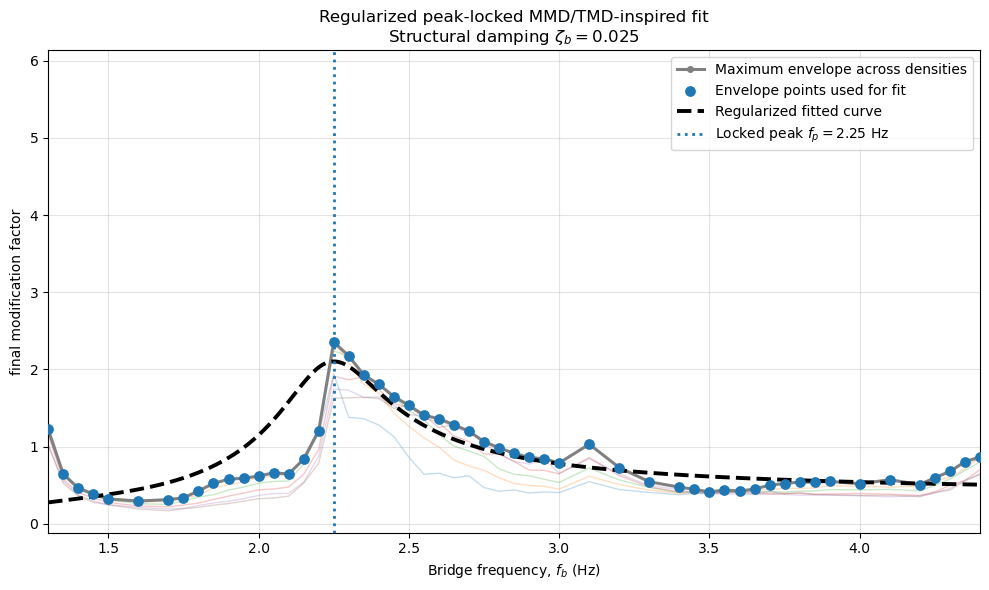


Fitting damping = 0.030
Number of fitting points: 54
Fitting frequency range: 1.3 to 4.4

Reference parameters from smooth equations
------------------------------------------
y0_ref      = 0.23526900
B_ref       = 3.98084000e-01
mu_ref      = 0.11777700
alpha_ref   = 0.69781700
zeta_a_ref  = 0.30165300

Initial guesses
----------------
y0       = 0.21533152
B        = 2.63579511e-01
mu       = 0.11777700
alpha    = 0.69781700
zeta_a   = 0.30165300
beta_p0  = 1.02520420

Bounds used
------------
lower = [0.       0.       0.082777 0.617817 0.25    ]
upper = [1.18478981e+01 1.00000000e+06 1.52777000e-01 7.77817000e-01
 3.61653000e-01]

Fitted parameters: regularized peak-locked B model
--------------------------------------------------
y0              = 0.06105834
B               = 3.48271707e-01
mu              = 0.13408367
alpha           = 0.67745328
zeta_b          = 0.03000000 fixed
zeta_a          = 0.26463183
beta_p          = 1.03453909
Q(beta_p)       = 6.07783178
A equivalent

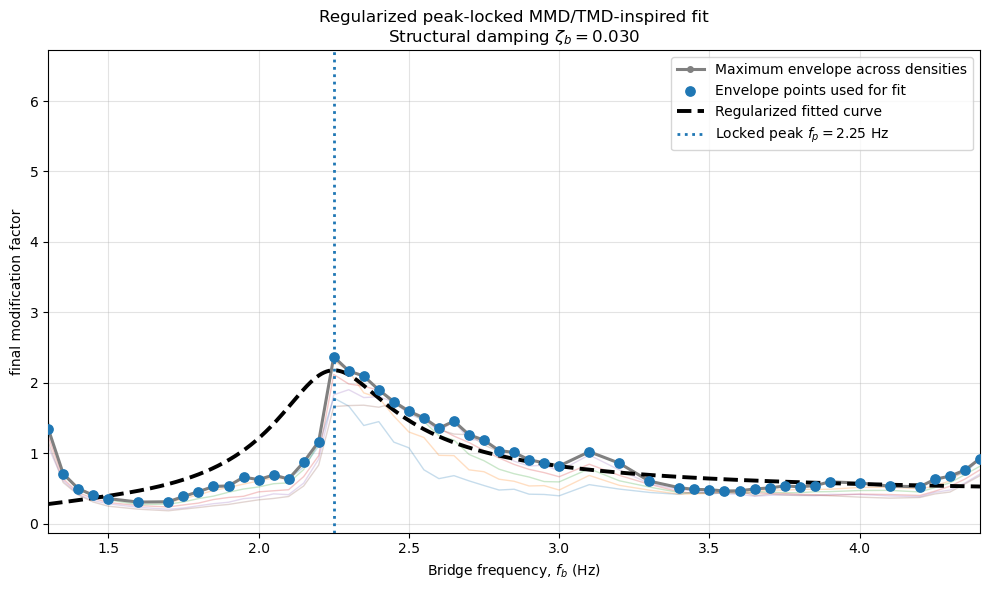


SUMMARY OF REGULARIZED FITTED PARAMETERS
 zeta_b   y0_ref    B_ref   mu_ref  alpha_ref  zeta_a_ref       y0        B       mu    alpha   zeta_a   beta_p  Q_beta_p  A_equivalent  f_p  checked_peak_frequency  checked_peak_value  success     cost  n_fit_points  fit_fmin  fit_fmax  reg_strength
  0.005 0.127712 0.169014 0.178129   0.522219    0.390026 0.152599 0.141651 0.179834 0.520308 0.369006 1.011669  9.094418      1.288231 2.25                2.251301            1.440817     True 1.283036            53       1.3       4.4          0.25
  0.010 0.149223 0.214828 0.166059   0.557339    0.372351 0.139348 0.196406 0.174609 0.553614 0.335391 1.017270  8.215009      1.613475 2.25                2.251301            1.752809     True 1.228679            53       1.3       4.4          0.25
  0.015 0.170735 0.260642 0.153989   0.592458    0.354677 0.120198 0.239668 0.166089 0.594125 0.296909 1.024737  7.542992      1.807813 2.25                2.251301            1.927998     True 1.237024   

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

# ==================================================
# SETTINGS
# ==================================================

# Use None to automatically fit all damping ratios available in corrected_df
DAMPINGS_TO_FIT = None
# DAMPINGS_TO_FIT = [0.005, 0.010, 0.015, 0.020, 0.025, 0.030]

Y_COL = "final_modification_factor"

FIT_FMIN = 1.30
FIT_FMAX = 4.40

F_TARGET_PEAK = 2.25

MEASURE_TO_USE = None
# MEASURE_TO_USE = "Peak 1-sec RMS"

BETA_MIN = 0.20
BETA_MAX = 3.00
N_BETA_PEAK = 6000

SAVE_PLOTS = False
SAVE_PARAMS = False

# Regularization strength.
# Increase to 0.50 if 0.020/0.025/0.030 are still too sharp.
# Decrease to 0.10 if the fit becomes too stiff.
REG_STRENGTH = 0.25


# ==================================================
# SMOOTH PARAMETER EQUATIONS
# From your latest fitted-line plots
# ==================================================

def parameter_reference_from_equations(xi_b):
    """
    Smooth reference parameters from the latest fitted equations.
    These are used to guide the fit and prevent strange high-damping shapes.
    """

    y0 = 4.3023 * xi_b + 0.1062
    B = 9.1628 * xi_b + 0.1232
    mu = -2.4141 * xi_b + 0.1902
    alpha = 7.0239 * xi_b + 0.4871
    zeta_a = -3.5349 * xi_b + 0.4077

    return {
        "y0": y0,
        "B": B,
        "mu": mu,
        "alpha": alpha,
        "zeta_a": zeta_a,
        "f_p": 2.25,
        "beta_p": 1.0,
    }


# ==================================================
# CLOSED-FORM MMD / TMD ACCELERATION SHAPE Q(beta)
# ==================================================

def Q_mmd(beta, mu, alpha, zeta_b, zeta_a):
    beta = np.asarray(beta, dtype=float)

    N_R = alpha**2 - beta**2
    N_I = 2.0 * zeta_a * alpha * beta

    D_R = (
        (1.0 - beta**2) * (alpha**2 - beta**2)
        - 4.0 * zeta_b * zeta_a * alpha * beta**2
        - mu * alpha**2 * beta**2
    )

    D_I = (
        2.0 * beta
        * (
            zeta_a * alpha * (1.0 - (1.0 + mu) * beta**2)
            + zeta_b * (alpha**2 - beta**2)
        )
    )

    numerator_abs = np.sqrt(N_R**2 + N_I**2)
    denominator_abs = np.sqrt(D_R**2 + D_I**2)

    return beta**2 * numerator_abs / (denominator_abs + 1e-14)


def beta_peak_for_parameters(mu, alpha, zeta_a, zeta_b):
    beta_grid = np.linspace(BETA_MIN, BETA_MAX, N_BETA_PEAK)

    Q_grid = Q_mmd(
        beta=beta_grid,
        mu=mu,
        alpha=alpha,
        zeta_b=zeta_b,
        zeta_a=zeta_a
    )

    return beta_grid[np.nanargmax(Q_grid)]


def chi_peak_locked_B_model(f_bridge, y0, B, mu, alpha, zeta_a, zeta_b):
    """
    Peak-locked model:

        chi(f_b) = y0 + B * Q(beta_eff)

    where:

        beta_eff = beta_p * f_b / F_TARGET_PEAK

    and beta_p is found internally from the current shape parameters.
    This locks the peak at F_TARGET_PEAK.
    """

    beta_p = beta_peak_for_parameters(
        mu=mu,
        alpha=alpha,
        zeta_a=zeta_a,
        zeta_b=zeta_b
    )

    beta_eff = beta_p * (f_bridge / F_TARGET_PEAK)

    Q_eff = Q_mmd(
        beta=beta_eff,
        mu=mu,
        alpha=alpha,
        zeta_b=zeta_b,
        zeta_a=zeta_a
    )

    return y0 + B * Q_eff


# ==================================================
# PREPARE ALL DATA ONCE
# ==================================================

df_all = corrected_df.copy()

required_cols = [
    "bridge_frequency",
    "target_beamdamp",
    "target_density",
    Y_COL,
]

missing_cols = [c for c in required_cols if c not in df_all.columns]
if missing_cols:
    raise KeyError(f"Missing required columns in corrected_df: {missing_cols}")

df_all["bridge_frequency"] = pd.to_numeric(df_all["bridge_frequency"], errors="coerce")
df_all["target_beamdamp"] = pd.to_numeric(df_all["target_beamdamp"], errors="coerce")
df_all["target_density"] = pd.to_numeric(df_all["target_density"], errors="coerce")
df_all[Y_COL] = pd.to_numeric(df_all[Y_COL], errors="coerce")

df_all = df_all.dropna(
    subset=[
        "bridge_frequency",
        "target_beamdamp",
        "target_density",
        Y_COL,
    ]
).copy()

df_all["damping_key"] = df_all["target_beamdamp"].round(3)
df_all["freq_key"] = df_all["bridge_frequency"].round(6)
df_all["density_key"] = df_all["target_density"].round(4)

if MEASURE_TO_USE is not None:
    if "measure" not in df_all.columns:
        raise KeyError("MEASURE_TO_USE is set, but corrected_df has no 'measure' column.")

    df_all = df_all[df_all["measure"].astype(str) == MEASURE_TO_USE].copy()

if DAMPINGS_TO_FIT is None:
    DAMPINGS_TO_FIT = sorted(df_all["damping_key"].dropna().unique())
else:
    DAMPINGS_TO_FIT = [round(float(x), 3) for x in DAMPINGS_TO_FIT]

print("\nDamping ratios to fit:")
print(DAMPINGS_TO_FIT)

print("\nAvailable data coverage:")
print(
    df_all.groupby(["damping_key", "density_key"])["bridge_frequency"]
    .agg(["min", "max", "count"])
    .reset_index()
    .to_string(index=False)
)


# ==================================================
# FIT FUNCTION FOR ONE DAMPING RATIO
# ==================================================

def fit_one_damping(damping_to_fit):

    zeta_b = float(damping_to_fit)
    damp_key = round(zeta_b, 3)

    df = df_all[np.isclose(df_all["damping_key"], damp_key)].copy()

    if df.empty:
        print(f"\nSkipping damping = {zeta_b:.3f}: no data found.")
        return None

    # Remove repeated rows.
    # For fitting final_modification_factor envelope, one row per frequency-density is enough.
    # If multiple measures exist, final_modification_factor is usually the same per case.
    df_unique = df.drop_duplicates(
        subset=["freq_key", "density_key"],
        keep="first"
    ).copy()

    # ==================================================
    # MAXIMUM ENVELOPE ACROSS DENSITIES
    # ==================================================

    env_df = (
        df_unique
        .groupby("freq_key", as_index=False)
        .agg(
            bridge_frequency=("bridge_frequency", "mean"),
            y_env=(Y_COL, "max")
        )
        .sort_values("bridge_frequency")
    )

    fit_df = env_df[
        (env_df["bridge_frequency"] >= FIT_FMIN) &
        (env_df["bridge_frequency"] <= FIT_FMAX)
    ].copy()

    x_fit = fit_df["bridge_frequency"].to_numpy()
    y_fit = fit_df["y_env"].to_numpy()

    if len(x_fit) < 8:
        print(f"\nSkipping damping = {zeta_b:.3f}: too few fitting points.")
        return None

    print("\n" + "=" * 80)
    print(f"Fitting damping = {zeta_b:.3f}")
    print("=" * 80)
    print("Number of fitting points:", len(x_fit))
    print("Fitting frequency range:", x_fit.min(), "to", x_fit.max())

    # ==================================================
    # REFERENCE PARAMETERS FROM SMOOTH EQUATIONS
    # ==================================================

    p_ref = parameter_reference_from_equations(zeta_b)

    y0_ref = p_ref["y0"]
    B_ref = p_ref["B"]
    mu_ref = p_ref["mu"]
    alpha_ref = p_ref["alpha"]
    zeta_a_ref = p_ref["zeta_a"]

    print("\nReference parameters from smooth equations")
    print("------------------------------------------")
    print(f"y0_ref      = {y0_ref:.8f}")
    print(f"B_ref       = {B_ref:.8e}")
    print(f"mu_ref      = {mu_ref:.8f}")
    print(f"alpha_ref   = {alpha_ref:.8f}")
    print(f"zeta_a_ref  = {zeta_a_ref:.8f}")

    # ==================================================
    # INITIAL GUESSES
    # Estimate y0 and B from data while using smooth reference shape.
    # ==================================================

    beta_p_ref = beta_peak_for_parameters(
        mu=mu_ref,
        alpha=alpha_ref,
        zeta_a=zeta_a_ref,
        zeta_b=zeta_b
    )

    beta_eff_ref = beta_p_ref * (x_fit / F_TARGET_PEAK)

    Q_ref = Q_mmd(
        beta=beta_eff_ref,
        mu=mu_ref,
        alpha=alpha_ref,
        zeta_b=zeta_b,
        zeta_a=zeta_a_ref
    )

    X_ref = np.column_stack([np.ones_like(Q_ref), Q_ref])
    y0_guess, B_guess = np.linalg.lstsq(X_ref, y_fit, rcond=None)[0]

    y0_guess = max(y0_guess, 1e-8)
    B_guess = max(B_guess, 1e-8)

    p0 = np.array([
        y0_guess,
        B_guess,
        mu_ref,
        alpha_ref,
        zeta_a_ref
    ])

    print("\nInitial guesses")
    print("----------------")
    print(f"y0       = {p0[0]:.8f}")
    print(f"B        = {p0[1]:.8e}")
    print(f"mu       = {p0[2]:.8f}")
    print(f"alpha    = {p0[3]:.8f}")
    print(f"zeta_a   = {p0[4]:.8f}")
    print(f"beta_p0  = {beta_p_ref:.8f}")

    # ==================================================
    # TIGHT BOUNDS AROUND SMOOTH PARAMETER TREND
    # ==================================================

    ymax = np.nanmax(y_fit)

    lower_bounds = np.array([
        0.00,                           # y0
        0.00,                           # B
        max(0.02, mu_ref - 0.035),      # mu
        max(0.50, alpha_ref - 0.08),    # alpha
        max(0.25, zeta_a_ref - 0.06),   # zeta_a
    ])

    upper_bounds = np.array([
        5.0 * ymax,                     # y0
        1e6,                            # B
        min(0.25, mu_ref + 0.035),      # mu
        min(0.90, alpha_ref + 0.08),    # alpha
        min(0.50, zeta_a_ref + 0.06),   # zeta_a
    ])

    small = 1e-10
    p0 = np.maximum(p0, lower_bounds + small)
    p0 = np.minimum(p0, upper_bounds - small)

    print("\nBounds used")
    print("------------")
    print("lower =", lower_bounds)
    print("upper =", upper_bounds)

    # ==================================================
    # FIT OBJECTIVE WITH REGULARIZATION
    # ==================================================

    eps = 1e-12

    # Gentler weights than before
    RIGHT_SHOULDER_WEIGHT = 1.25
    POST_PEAK_SHOULDER_WEIGHT = 1.10
    PEAK_WEIGHT_STRENGTH = 0.05

    def residuals(p):
        y0, B, mu, alpha, zeta_a = p

        y_model = chi_peak_locked_B_model(
            f_bridge=x_fit,
            y0=y0,
            B=B,
            mu=mu,
            alpha=alpha,
            zeta_a=zeta_a,
            zeta_b=zeta_b
        )

        if np.any(y_model <= 0):
            return 1e6 * np.ones_like(y_fit)

        # Data residual in log-space
        res_data = np.log(y_model + eps) - np.log(y_fit + eps)

        # Mild weights only
        peak_weight = 1.0 + PEAK_WEIGHT_STRENGTH * np.exp(
            -0.5 * ((x_fit - F_TARGET_PEAK) / 0.25)**2
        )

        right_weight = np.where(
            x_fit > F_TARGET_PEAK,
            RIGHT_SHOULDER_WEIGHT,
            1.0
        )

        post_peak_weight = np.where(
            (x_fit >= 2.35) & (x_fit <= 3.00),
            POST_PEAK_SHOULDER_WEIGHT,
            1.0
        )

        res_data = peak_weight * right_weight * post_peak_weight * res_data

        # Regularization residual:
        # keeps shape parameters near smooth equations.
        res_reg = REG_STRENGTH * np.array([
            (mu - mu_ref) / 0.035,
            (alpha - alpha_ref) / 0.08,
            (zeta_a - zeta_a_ref) / 0.06,
        ])

        return np.concatenate([res_data, res_reg])

    # ==================================================
    # RUN OPTIMIZATION
    # ==================================================

    result = least_squares(
        residuals,
        p0,
        bounds=(lower_bounds, upper_bounds),
        loss="soft_l1",
        f_scale=0.1,
        max_nfev=50000
    )

    y0_fit, B_fit, mu_fit, alpha_fit, zeta_a_fit = result.x

    beta_p_fit = beta_peak_for_parameters(
        mu=mu_fit,
        alpha=alpha_fit,
        zeta_a=zeta_a_fit,
        zeta_b=zeta_b
    )

    Q_beta_p_fit = Q_mmd(
        beta=beta_p_fit,
        mu=mu_fit,
        alpha=alpha_fit,
        zeta_b=zeta_b,
        zeta_a=zeta_a_fit
    )

    A_equivalent = B_fit * Q_beta_p_fit

    # ==================================================
    # SMOOTH FITTED CURVE
    # ==================================================

    x_smooth = np.linspace(FIT_FMIN, FIT_FMAX, 1500)

    y_smooth = chi_peak_locked_B_model(
        f_bridge=x_smooth,
        y0=y0_fit,
        B=B_fit,
        mu=mu_fit,
        alpha=alpha_fit,
        zeta_a=zeta_a_fit,
        zeta_b=zeta_b
    )

    peak_idx = np.nanargmax(y_smooth)

    print("\nFitted parameters: regularized peak-locked B model")
    print("--------------------------------------------------")
    print(f"y0              = {y0_fit:.8f}")
    print(f"B               = {B_fit:.8e}")
    print(f"mu              = {mu_fit:.8f}")
    print(f"alpha           = {alpha_fit:.8f}")
    print(f"zeta_b          = {zeta_b:.8f} fixed")
    print(f"zeta_a          = {zeta_a_fit:.8f}")
    print(f"beta_p          = {beta_p_fit:.8f}")
    print(f"Q(beta_p)       = {Q_beta_p_fit:.8f}")
    print(f"A equivalent    = B * Q(beta_p) = {A_equivalent:.8f}")
    print(f"Checked peak frequency = {x_smooth[peak_idx]:.6f} Hz")
    print(f"Checked peak value     = {y_smooth[peak_idx]:.6f}")
    print("Success:", result.success)
    print("Message:", result.message)
    print("Cost:", result.cost)

    # ==================================================
    # PLOT
    # ==================================================

    plt.figure(figsize=(10, 6))

    # Individual density curves
    for density in sorted(df_unique["density_key"].unique()):
        sub = df_unique[
            np.isclose(df_unique["density_key"], density)
        ].sort_values("bridge_frequency")

        plt.plot(
            sub["bridge_frequency"],
            sub[Y_COL],
            linewidth=1.0,
            alpha=0.25
        )

    # Envelope
    plt.plot(
        env_df["bridge_frequency"],
        env_df["y_env"],
        "o-",
        linewidth=2.2,
        markersize=4,
        color="gray",
        label="Maximum envelope across densities"
    )

    # Points used for fit
    plt.scatter(
        x_fit,
        y_fit,
        s=45,
        zorder=5,
        label="Envelope points used for fit"
    )

    # Fitted curve
    plt.plot(
        x_smooth,
        y_smooth,
        "k--",
        linewidth=2.8,
        label="Regularized fitted curve"
    )

    plt.axvline(
        F_TARGET_PEAK,
        linestyle=":",
        linewidth=2.0,
        label=rf"Locked peak $f_p={F_TARGET_PEAK:.2f}$ Hz"
    )

    plt.xlabel(r"Bridge frequency, $f_b$ (Hz)")
    plt.xlim(FIT_FMIN, FIT_FMAX)
    plt.ylabel(Y_COL.replace("_", " "))
    plt.title(
        "Regularized peak-locked MMD/TMD-inspired fit\n"
        rf"Structural damping $\zeta_b={zeta_b:.3f}$"
    )

    plt.grid(True, alpha=0.35)
    plt.legend()
    plt.tight_layout()

    if SAVE_PLOTS:
        outname = f"regularized_peak_locked_fit_damping{zeta_b:.3f}.png"
        plt.savefig(outname, dpi=300, bbox_inches="tight")
        print("Saved:", outname)

    plt.show()

    # Return summary row
    return {
        "zeta_b": zeta_b,

        "y0_ref": y0_ref,
        "B_ref": B_ref,
        "mu_ref": mu_ref,
        "alpha_ref": alpha_ref,
        "zeta_a_ref": zeta_a_ref,

        "y0": y0_fit,
        "B": B_fit,
        "mu": mu_fit,
        "alpha": alpha_fit,
        "zeta_a": zeta_a_fit,
        "beta_p": beta_p_fit,
        "Q_beta_p": Q_beta_p_fit,
        "A_equivalent": A_equivalent,
        "f_p": F_TARGET_PEAK,

        "checked_peak_frequency": x_smooth[peak_idx],
        "checked_peak_value": y_smooth[peak_idx],
        "success": result.success,
        "cost": result.cost,
        "n_fit_points": len(x_fit),
        "fit_fmin": x_fit.min(),
        "fit_fmax": x_fit.max(),
        "reg_strength": REG_STRENGTH,
    }


# ==================================================
# LOOP OVER ALL DAMPING RATIOS
# ==================================================

fit_rows = []

for damp in DAMPINGS_TO_FIT:
    row = fit_one_damping(damp)

    if row is not None:
        fit_rows.append(row)

fit_summary_df = pd.DataFrame(fit_rows)

print("\n" + "=" * 80)
print("SUMMARY OF REGULARIZED FITTED PARAMETERS")
print("=" * 80)

if fit_summary_df.empty:
    print("No successful fits.")
else:
    print(fit_summary_df.to_string(index=False))

    if SAVE_PARAMS:
        fit_summary_df.to_csv(
            "regularized_peak_locked_fit_parameters_all_dampings.csv",
            index=False
        )
        print("\nSaved: regularized_peak_locked_fit_parameters_all_dampings.csv")

Using fit_summary_df from notebook memory.

Stored fitted parameter table:
 xi_b       y0        B       mu    alpha   zeta_a   beta_p  f_p  xi_b_scaled
0.005 0.152599 0.141651 0.179834 0.520308 0.369006 1.011669 2.25          0.5
0.010 0.139348 0.196406 0.174609 0.553614 0.335391 1.017270 2.25          1.0
0.015 0.120198 0.239668 0.166089 0.594125 0.296909 1.024737 2.25          1.5
0.020 0.100419 0.278166 0.154560 0.616796 0.296948 1.025671 2.25          2.0
0.025 0.071817 0.324311 0.148132 0.664078 0.265490 1.035473 2.25          2.5
0.030 0.061058 0.348272 0.134084 0.677453 0.264632 1.034539 2.25          3.0

Linear equations using real xi_b
$y_o$ = -3.88615871 xi_b + 0.17558094
$B$ = 8.31610193 xi_b + 0.10921371
$\mu$ = -1.82692650 xi_b + 0.19152251
$\alpha$ = 6.51309317 xi_b + 0.49041628
$\zeta_a$ = -4.18017883 xi_b + 0.37788228
$\beta_p$ = 0.97082847 xi_b + 1.00790354
$f_p$ = -0.00000000 xi_b + 2.25000000

Equation table:
parameter       slope_m  intercept_c                    

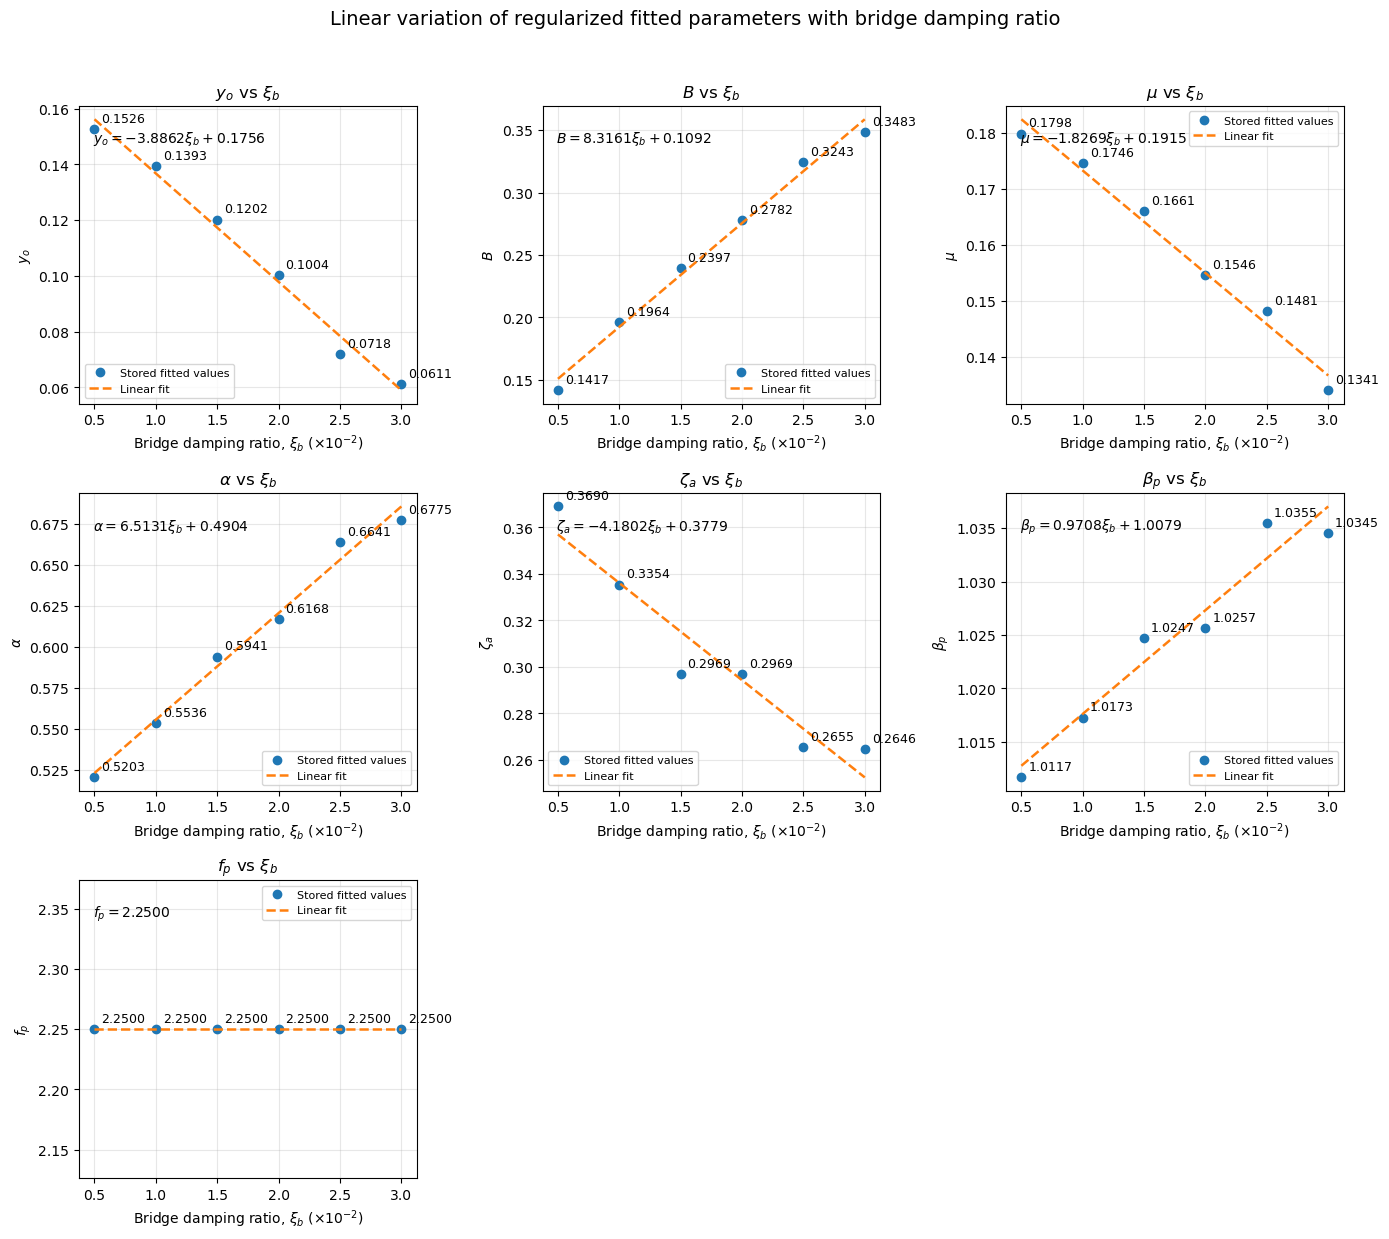

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ==================================================
# LOAD / USE STORED FITTED PARAMETERS
# ==================================================

csv_file = Path("regularized_peak_locked_fit_parameters_all_dampings.csv")

# If fit_summary_df already exists in notebook memory, use it.
# Otherwise load it from CSV.
if "fit_summary_df" in globals():
    df_params = fit_summary_df.copy()
    print("Using fit_summary_df from notebook memory.")
elif csv_file.exists():
    df_params = pd.read_csv(csv_file)
    print(f"Loaded fitted parameters from: {csv_file}")
else:
    raise FileNotFoundError(
        "Could not find fit_summary_df in memory or "
        "regularized_peak_locked_fit_parameters_all_dampings.csv on disk."
    )

# Rename damping column to xi_b for plotting
if "zeta_b" in df_params.columns:
    df_params = df_params.rename(columns={"zeta_b": "xi_b"})

# Keep only required columns
required_cols = ["xi_b", "y0", "B", "mu", "alpha", "zeta_a", "beta_p", "f_p"]

missing_cols = [c for c in required_cols if c not in df_params.columns]
if missing_cols:
    raise KeyError(f"Missing required columns: {missing_cols}")

df_params = df_params[required_cols].copy()

# Convert to numeric
for col in required_cols:
    df_params[col] = pd.to_numeric(df_params[col], errors="coerce")

df_params = df_params.dropna(subset=required_cols).copy()
df_params = df_params.sort_values("xi_b").reset_index(drop=True)

# Scaled x-axis only for plotting
df_params["xi_b_scaled"] = df_params["xi_b"] * 1e2

print("\nStored fitted parameter table:")
print(df_params.to_string(index=False))


# ==================================================
# LABELS
# ==================================================

symbol_labels = {
    "y0": r"$y_o$",
    "B": r"$B$",
    "mu": r"$\mu$",
    "alpha": r"$\alpha$",
    "zeta_a": r"$\zeta_a$",
    "beta_p": r"$\beta_p$",
    "f_p": r"$f_p$",
    "xi_b": r"$\xi_b$",
}

symbol_raw = {
    "y0": r"y_o",
    "B": r"B",
    "mu": r"\mu",
    "alpha": r"\alpha",
    "zeta_a": r"\zeta_a",
    "beta_p": r"\beta_p",
    "f_p": r"f_p",
    "xi_b": r"\xi_b",
}

params_to_plot = ["y0", "B", "mu", "alpha", "zeta_a", "beta_p", "f_p"]


# ==================================================
# LINEAR FITS: parameter = m * xi_b + c
# ==================================================

linear_equations = {}

print("\nLinear equations using real xi_b")
print("================================")

equation_rows = []

for param in params_to_plot:

    x_real = df_params["xi_b"].to_numpy()
    y = df_params[param].to_numpy()

    m, c = np.polyfit(x_real, y, 1)

    linear_equations[param] = {
        "slope": m,
        "intercept": c,
    }

    equation_rows.append({
        "parameter": param,
        "slope_m": m,
        "intercept_c": c,
        "equation": f"{param} = {m:.8f} * xi_b + {c:.8f}",
    })

    print(f"{symbol_labels[param]} = {m:.8f} xi_b + {c:.8f}")

df_equations = pd.DataFrame(equation_rows)

print("\nEquation table:")
print(df_equations.to_string(index=False))

df_equations.to_csv("linear_equations_from_regularized_fit.csv", index=False)
print("\nSaved: linear_equations_from_regularized_fit.csv")


# ==================================================
# PLOT DATA + LINEAR FIT
# ==================================================

n = len(params_to_plot)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(14, 4.2 * nrows)
)

axes = np.asarray(axes).reshape(-1)

# Real xi_b for fitting
xi_fit = np.linspace(
    df_params["xi_b"].min(),
    df_params["xi_b"].max(),
    200
)

# Scaled only for plotting
xi_fit_scaled = xi_fit * 1e2

for ax, param in zip(axes, params_to_plot):

    xi_scaled = df_params["xi_b_scaled"].to_numpy()
    y = df_params[param].to_numpy()

    m = linear_equations[param]["slope"]
    c = linear_equations[param]["intercept"]

    y_fit = m * xi_fit + c

    # Stored fitted points
    ax.plot(
        xi_scaled,
        y,
        marker="o",
        linestyle="",
        markersize=6,
        label="Stored fitted values"
    )

    # Linear fit line
    ax.plot(
        xi_fit_scaled,
        y_fit,
        linestyle="--",
        linewidth=1.8,
        label="Linear fit"
    )

    # Annotate values
    for x_plot, yi in zip(xi_scaled, y):
        ax.annotate(
            f"{yi:.4f}",
            (x_plot, yi),
            textcoords="offset points",
            xytext=(5, 5),
            fontsize=9
        )

    # Equation text
    if abs(m) < 1e-12:
        equation_text = rf"${symbol_raw[param]} = {c:.4f}$"
    else:
        equation_text = rf"${symbol_raw[param]} = {m:.4f}\xi_b + {c:.4f}$"

    ax.text(
        0.04,
        0.92,
        equation_text,
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment="top"
    )

    ax.set_title(f"{symbol_labels[param]} vs {symbol_labels['xi_b']}")
    ax.set_xlabel(r"Bridge damping ratio, $\xi_b$ $(\times 10^{-2})$")
    ax.set_ylabel(symbol_labels[param])

    ax.set_xticks(df_params["xi_b_scaled"])
    ax.set_xticklabels([f"{val:.1f}" for val in df_params["xi_b_scaled"]])

    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

# Remove unused axes
for j in range(len(params_to_plot), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(
    "Linear variation of regularized fitted parameters with bridge damping ratio",
    fontsize=14
)

fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


FITTING DAMPING RATIO = 0.005
Number of fitting points: 50
Fitting frequency range: 1.5 to 4.4

Peak value used for piecewise fit
---------------------------------
f_peak_data       = 2.250000 Hz
chi_peak_data     = 1.589146
CHI_PEAK used     = 1.620929

Left-side fitted parameters
---------------------------
chi_low = 0.15570132
n_left  = 3.24454849
success = True

Right-side fitted parameters
----------------------------
chi_inf  = 0.38307927
c_right  = 3.62473273
bump_amp = 0.01426798
success = True

Safety adjustment
-----------------
required_shift = 0.33962895
safety_shift   = 0.34642153


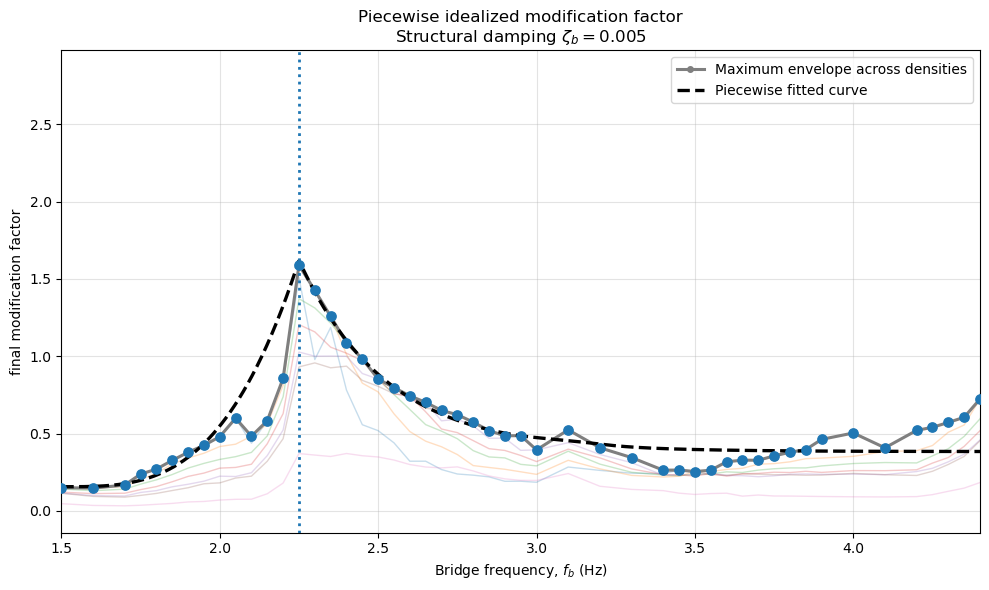


FINAL PIECEWISE EQUATION FOR damping = 0.005

For f_b <= f_p:
chi_L(f_b) = 0.155701 + (1.620929 - 0.155701) * ((f_b - 1.500000) / (2.250000 - 1.500000))^3.244548

For f_b > f_p:
chi_R(f_b) = 0.383079 + (1.620929 - 0.383079) * exp(-3.624733 * (f_b - 2.250000))

Right-side bump term:
+ 0.014268 * max(exp(-0.5*((f_b - 3.100000)/0.100000)^2) - exp(-0.5*((2.250000 - 3.100000)/0.100000)^2), 0)

Safe design curve:
chi_safe(f_b) = chi_piecewise(f_b) + 0.34642153

Stored parameter dictionary:
{'damping': 0.005, 'f_min': 1.5, 'f_max': 4.4, 'f_p': 2.25, 'chi_peak': np.float64(1.6209285527728388), 'chi_low': np.float64(0.15570131549797078), 'n_left': np.float64(3.2445484886502216), 'chi_inf': np.float64(0.38307927386078794), 'c_right': np.float64(3.624732732270302), 'use_right_bump': True, 'bump_center': 3.1, 'bump_width': 0.1, 'bump_amp': np.float64(0.014267975199832375), 'safety_shift': np.float64(0.34642152601523146)}

FITTING DAMPING RATIO = 0.010
Number of fitting points: 50
Fitting frequenc

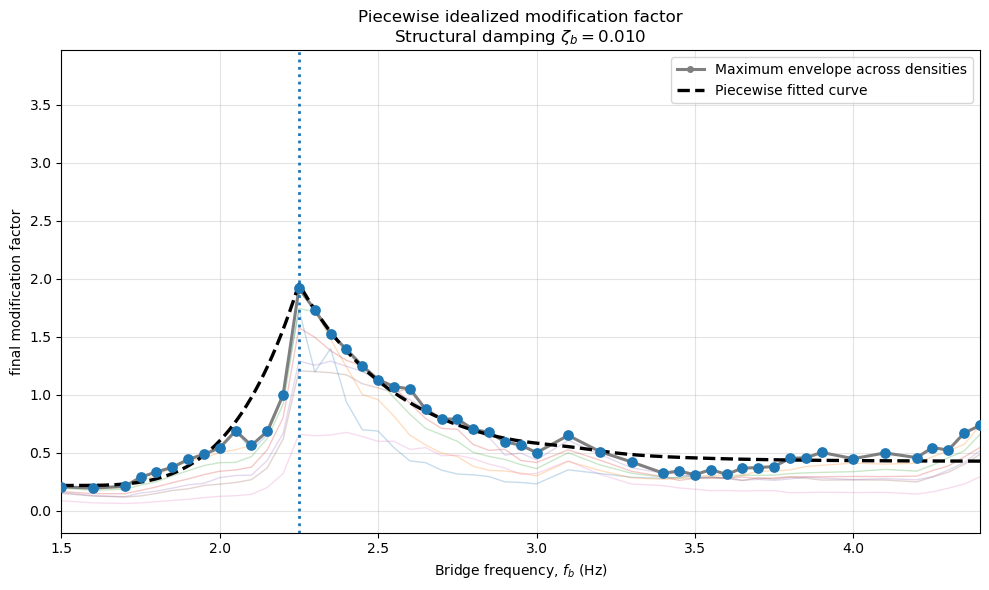


FINAL PIECEWISE EQUATION FOR damping = 0.010

For f_b <= f_p:
chi_L(f_b) = 0.218050 + (1.956929 - 0.218050) * ((f_b - 1.500000) / (2.250000 - 1.500000))^3.711304

For f_b > f_p:
chi_R(f_b) = 0.426537 + (1.956929 - 0.426537) * exp(-3.164025 * (f_b - 2.250000))

Right-side bump term:
+ 0.022885 * max(exp(-0.5*((f_b - 3.100000)/0.100000)^2) - exp(-0.5*((2.250000 - 3.100000)/0.100000)^2), 0)

Safe design curve:
chi_safe(f_b) = chi_piecewise(f_b) + 0.31405237

Stored parameter dictionary:
{'damping': 0.01, 'f_min': 1.5, 'f_max': 4.4, 'f_p': 2.25, 'chi_peak': np.float64(1.9569294836867823), 'chi_low': np.float64(0.2180495165180701), 'n_left': np.float64(3.711304326663416), 'chi_inf': np.float64(0.4265366358407501), 'c_right': np.float64(3.1640245075146765), 'use_right_bump': True, 'bump_center': 3.1, 'bump_width': 0.1, 'bump_amp': np.float64(0.02288549445091444), 'safety_shift': np.float64(0.3140523698097291)}

FITTING DAMPING RATIO = 0.015
Number of fitting points: 50
Fitting frequency ran

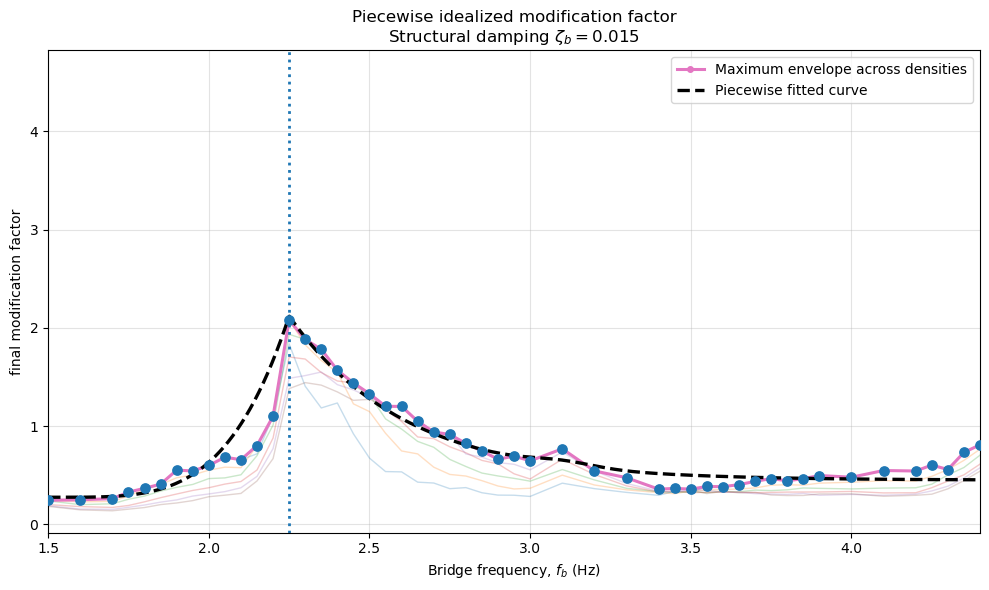


FINAL PIECEWISE EQUATION FOR damping = 0.015

For f_b <= f_p:
chi_L(f_b) = 0.277027 + (2.121765 - 0.277027) * ((f_b - 1.500000) / (2.250000 - 1.500000))^4.059483

For f_b > f_p:
chi_R(f_b) = 0.450686 + (2.121765 - 0.450686) * exp(-2.801117 * (f_b - 2.250000))

Right-side bump term:
+ 0.049948 * max(exp(-0.5*((f_b - 3.100000)/0.100000)^2) - exp(-0.5*((2.250000 - 3.100000)/0.100000)^2), 0)

Safe design curve:
chi_safe(f_b) = chi_piecewise(f_b) + 0.36334561

Stored parameter dictionary:
{'damping': 0.015, 'f_min': 1.5, 'f_max': 4.4, 'f_p': 2.25, 'chi_peak': np.float64(2.1217645677462222), 'chi_low': np.float64(0.2770269757050251), 'n_left': np.float64(4.059482707730109), 'chi_inf': np.float64(0.45068644985229406), 'c_right': np.float64(2.801117047082909), 'use_right_bump': True, 'bump_center': 3.1, 'bump_width': 0.1, 'bump_amp': np.float64(0.049948208281234106), 'safety_shift': np.float64(0.36334560843721936)}

FITTING DAMPING RATIO = 0.020
Number of fitting points: 50
Fitting frequency 

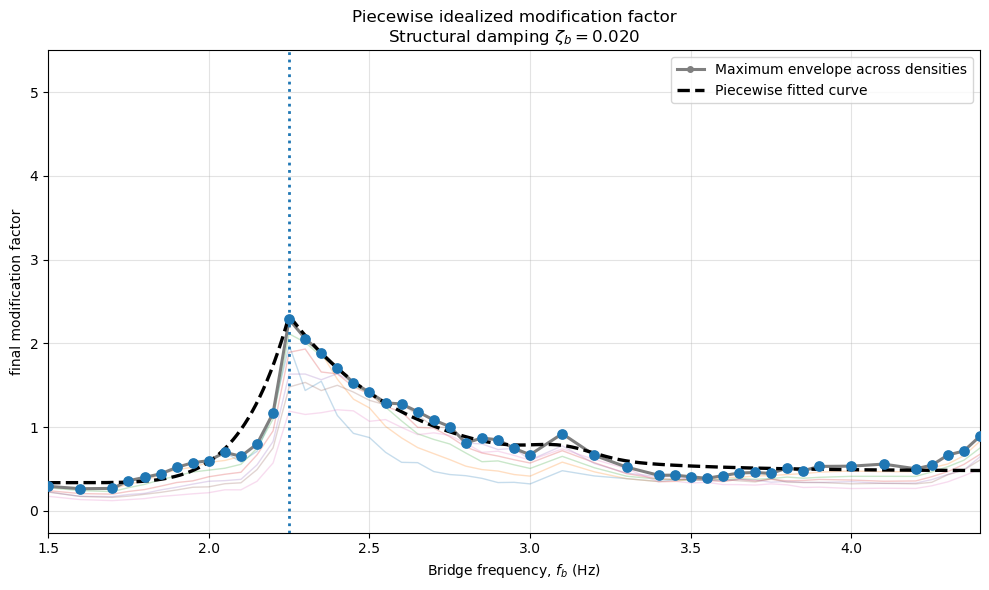


FINAL PIECEWISE EQUATION FOR damping = 0.020

For f_b <= f_p:
chi_L(f_b) = 0.335696 + (2.332966 - 0.335696) * ((f_b - 1.500000) / (2.250000 - 1.500000))^5.129331

For f_b > f_p:
chi_R(f_b) = 0.476216 + (2.332966 - 0.476216) * exp(-2.760603 * (f_b - 2.250000))

Right-side bump term:
+ 0.127649 * max(exp(-0.5*((f_b - 3.100000)/0.100000)^2) - exp(-0.5*((2.250000 - 3.100000)/0.100000)^2), 0)

Safe design curve:
chi_safe(f_b) = chi_piecewise(f_b) + 0.41872279

Stored parameter dictionary:
{'damping': 0.02, 'f_min': 1.5, 'f_max': 4.4, 'f_p': 2.25, 'chi_peak': np.float64(2.332965589497377), 'chi_low': np.float64(0.33569610855590404), 'n_left': np.float64(5.129331367079844), 'chi_inf': np.float64(0.4762163342390491), 'c_right': np.float64(2.7606025718016998), 'use_right_bump': True, 'bump_center': 3.1, 'bump_width': 0.1, 'bump_amp': np.float64(0.1276485389726062), 'safety_shift': np.float64(0.4187227868101302)}

FITTING DAMPING RATIO = 0.025
Number of fitting points: 50
Fitting frequency rang

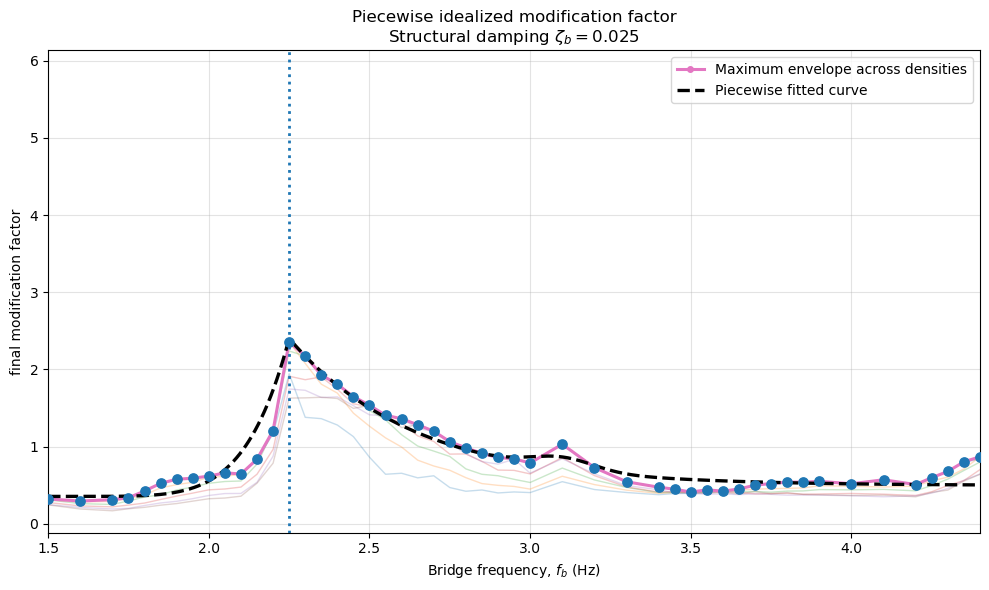


FINAL PIECEWISE EQUATION FOR damping = 0.025

For f_b <= f_p:
chi_L(f_b) = 0.353659 + (2.401692 - 0.353659) * ((f_b - 1.500000) / (2.250000 - 1.500000))^5.723935

For f_b > f_p:
chi_R(f_b) = 0.495163 + (2.401692 - 0.495163) * exp(-2.562248 * (f_b - 2.250000))

Right-side bump term:
+ 0.154167 * max(exp(-0.5*((f_b - 3.100000)/0.100000)^2) - exp(-0.5*((2.250000 - 3.100000)/0.100000)^2), 0)

Safe design curve:
chi_safe(f_b) = chi_piecewise(f_b) + 0.37155164

Stored parameter dictionary:
{'damping': 0.025, 'f_min': 1.5, 'f_max': 4.4, 'f_p': 2.25, 'chi_peak': np.float64(2.401692389520667), 'chi_low': np.float64(0.3536585909440828), 'n_left': np.float64(5.723934689944531), 'chi_inf': np.float64(0.4951629365198095), 'c_right': np.float64(2.562248396797689), 'use_right_bump': True, 'bump_center': 3.1, 'bump_width': 0.1, 'bump_amp': np.float64(0.15416726690057359), 'safety_shift': np.float64(0.3715516432700563)}

FITTING DAMPING RATIO = 0.030
Number of fitting points: 50
Fitting frequency rang

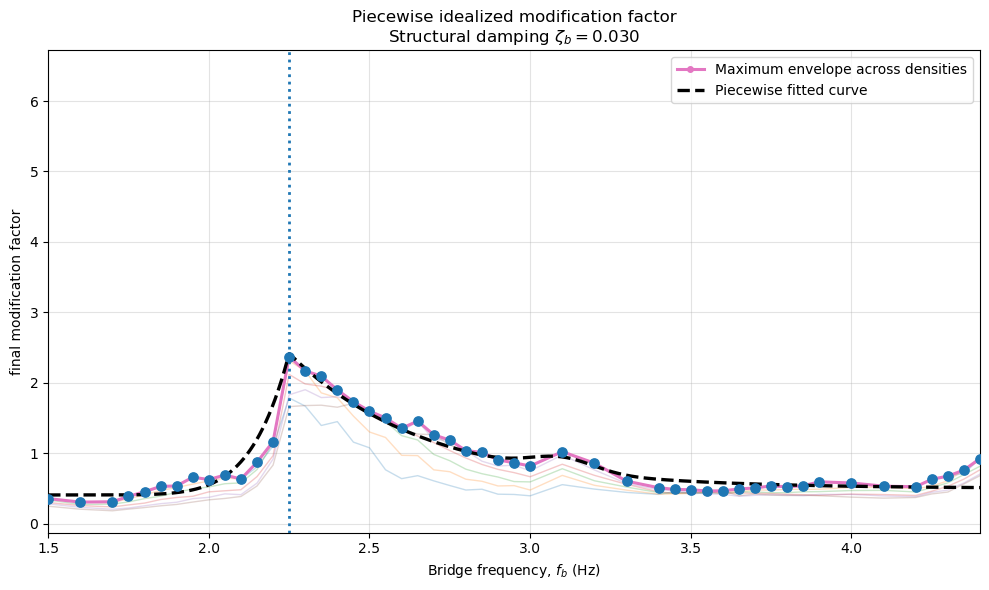


FINAL PIECEWISE EQUATION FOR damping = 0.030

For f_b <= f_p:
chi_L(f_b) = 0.407262 + (2.416971 - 0.407262) * ((f_b - 1.500000) / (2.250000 - 1.500000))^6.497743

For f_b > f_p:
chi_R(f_b) = 0.500152 + (2.416971 - 0.500152) * exp(-2.356180 * (f_b - 2.250000))

Right-side bump term:
+ 0.188542 * max(exp(-0.5*((f_b - 3.100000)/0.100000)^2) - exp(-0.5*((2.250000 - 3.100000)/0.100000)^2), 0)

Safe design curve:
chi_safe(f_b) = chi_piecewise(f_b) + 0.42059003

Stored parameter dictionary:
{'damping': 0.03, 'f_min': 1.5, 'f_max': 4.4, 'f_p': 2.25, 'chi_peak': np.float64(2.4169712081109984), 'chi_low': np.float64(0.4072623518523746), 'n_left': np.float64(6.497742513125332), 'chi_inf': np.float64(0.500152365565227), 'c_right': np.float64(2.356180027722306), 'use_right_bump': True, 'bump_center': 3.1, 'bump_width': 0.1, 'bump_amp': np.float64(0.18854200183328973), 'safety_shift': np.float64(0.42059002567628806)}


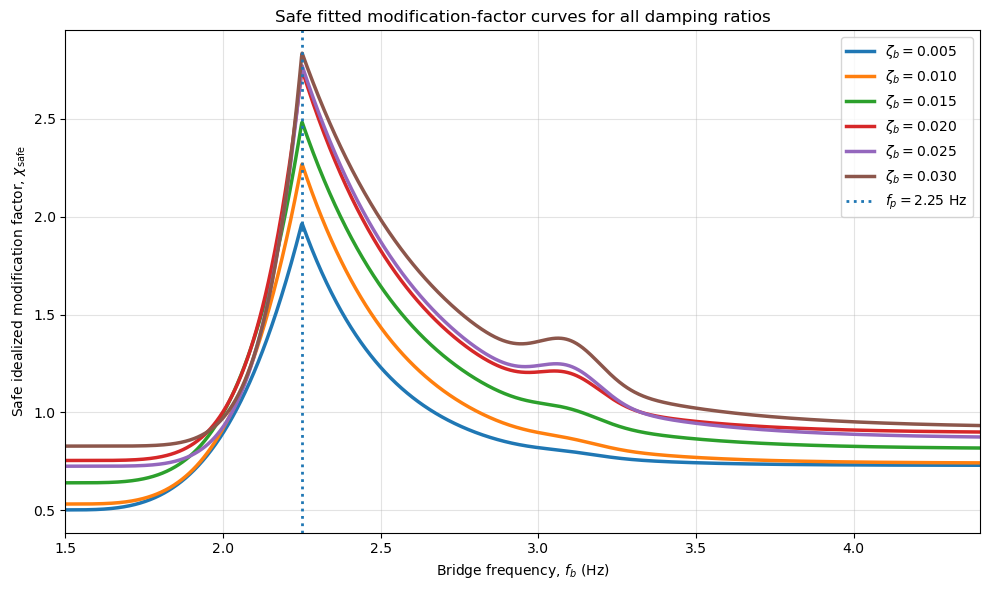


Final fitted parameter table:
   damping  f_min  f_max   f_p  chi_peak   chi_low    n_left   chi_inf  \
0    0.005    1.5    4.4  2.25  1.620929  0.155701  3.244548  0.383079   
1    0.010    1.5    4.4  2.25  1.956929  0.218050  3.711304  0.426537   
2    0.015    1.5    4.4  2.25  2.121765  0.277027  4.059483  0.450686   
3    0.020    1.5    4.4  2.25  2.332966  0.335696  5.129331  0.476216   
4    0.025    1.5    4.4  2.25  2.401692  0.353659  5.723935  0.495163   
5    0.030    1.5    4.4  2.25  2.416971  0.407262  6.497743  0.500152   

    c_right  use_right_bump  bump_center  bump_width  bump_amp  safety_shift  
0  3.624733            True          3.1         0.1  0.014268      0.346422  
1  3.164025            True          3.1         0.1  0.022885      0.314052  
2  2.801117            True          3.1         0.1  0.049948      0.363346  
3  2.760603            True          3.1         0.1  0.127649      0.418723  
4  2.562248            True          3.1         0.1  0

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

# ==================================================
# SETTINGS
# ==================================================

DAMPING_VALUES_TO_FIT = [0.005, 0.010, 0.015, 0.020, 0.025, 0.030]


Y_COL = "final_modification_factor"

FIT_FMIN = 1.50
FIT_FMAX = 4.40

F_TARGET_PEAK = 2.25

MEASURE_TO_USE = None
# MEASURE_TO_USE = "Peak 1-sec RMS"

SAFETY_MARGIN = 1.02

# Keep empty if you want to use all densities in the envelope fit
EXCLUDE_DENSITIES_FOR_FIT = []
# EXCLUDE_DENSITIES_FOR_FIT = [0.0333, 1.0000]

USE_RIGHT_BUMP = True
BUMP_CENTER = 3.10
BUMP_WIDTH = 0.10

eps = 1e-12


# ==================================================
# FIT FUNCTION FOR ONE DAMPING RATIO
# ==================================================

def fit_piecewise_for_one_damping(corrected_df, damping_to_fit):

    # ==================================================
    # PREPARE DATA
    # ==================================================

    df = corrected_df.copy()

    df["bridge_frequency"] = pd.to_numeric(df["bridge_frequency"], errors="coerce")
    df["target_beamdamp"] = pd.to_numeric(df["target_beamdamp"], errors="coerce")
    df["target_density"] = pd.to_numeric(df["target_density"], errors="coerce")
    df[Y_COL] = pd.to_numeric(df[Y_COL], errors="coerce")

    df = df.dropna(
        subset=["bridge_frequency", "target_beamdamp", "target_density", Y_COL]
    ).copy()

    df = df[np.isclose(df["target_beamdamp"], damping_to_fit)].copy()

    if MEASURE_TO_USE is not None:
        df = df[df["measure"].astype(str) == MEASURE_TO_USE].copy()

    for d_exclude in EXCLUDE_DENSITIES_FOR_FIT:
        df = df[~np.isclose(df["target_density"], d_exclude)].copy()

    if df.empty:
        raise ValueError(f"No data found for damping = {damping_to_fit}")

    df["freq_key"] = df["bridge_frequency"].round(6)
    df["density_key"] = df["target_density"].round(4)

    # Remove repeated rows from multiple measures
    df_unique = df.drop_duplicates(
        subset=["freq_key", "density_key"],
        keep="first"
    ).copy()

    # ==================================================
    # MAXIMUM ENVELOPE ACROSS DENSITIES
    # ==================================================

    env_df = (
        df_unique
        .groupby("freq_key", as_index=False)
        .agg(
            bridge_frequency=("bridge_frequency", "mean"),
            y_env=(Y_COL, "max")
        )
        .sort_values("bridge_frequency")
    )

    fit_df = env_df[
        (env_df["bridge_frequency"] >= FIT_FMIN) &
        (env_df["bridge_frequency"] <= FIT_FMAX)
    ].copy()

    x_fit = fit_df["bridge_frequency"].to_numpy()
    y_fit = fit_df["y_env"].to_numpy()

    if len(x_fit) < 8:
        raise ValueError(f"Too few fitting points for damping = {damping_to_fit}")

    print("\n" + "="*90)
    print(f"FITTING DAMPING RATIO = {damping_to_fit:.3f}")
    print("="*90)
    print("Number of fitting points:", len(x_fit))
    print("Fitting frequency range:", x_fit.min(), "to", x_fit.max())

    # ==================================================
    # FIX PEAK VALUE FROM ENVELOPE NEAR f_p
    # ==================================================

    peak_window = fit_df[
        np.abs(fit_df["bridge_frequency"] - F_TARGET_PEAK) <= 0.05
    ].copy()

    if not peak_window.empty:
        chi_peak_data = peak_window["y_env"].max()
        f_peak_data = peak_window.loc[
            peak_window["y_env"].idxmax(), "bridge_frequency"
        ]
    else:
        peak_idx = np.argmin(np.abs(x_fit - F_TARGET_PEAK))
        chi_peak_data = y_fit[peak_idx]
        f_peak_data = x_fit[peak_idx]

    CHI_PEAK = SAFETY_MARGIN * chi_peak_data

    print("\nPeak value used for piecewise fit")
    print("---------------------------------")
    print(f"f_peak_data       = {f_peak_data:.6f} Hz")
    print(f"chi_peak_data     = {chi_peak_data:.6f}")
    print(f"CHI_PEAK used     = {CHI_PEAK:.6f}")

    # ==================================================
    # PIECEWISE MODEL
    # ==================================================

    def chi_left_model(f_bridge, chi_low, n_left):
        f_bridge = np.asarray(f_bridge, dtype=float)

        t = (f_bridge - FIT_FMIN) / (F_TARGET_PEAK - FIT_FMIN)
        t = np.clip(t, 0.0, 1.0)

        return chi_low + (CHI_PEAK - chi_low) * t**n_left


    def chi_right_model(f_bridge, chi_inf, c_right, bump_amp=0.0):
        f_bridge = np.asarray(f_bridge, dtype=float)

        d = np.maximum(f_bridge - F_TARGET_PEAK, 0.0)

        base = chi_inf + (CHI_PEAK - chi_inf) * np.exp(-c_right * d)

        if USE_RIGHT_BUMP:
            g = np.exp(-0.5 * ((f_bridge - BUMP_CENTER) / BUMP_WIDTH)**2)
            g0 = np.exp(
                -0.5 * ((F_TARGET_PEAK - BUMP_CENTER) / BUMP_WIDTH)**2
            )

            bump_shape = np.maximum(g - g0, 0.0)

            return base + bump_amp * bump_shape

        return base


    def chi_piecewise_model(f_bridge, left_params, right_params):
        f_bridge = np.asarray(f_bridge, dtype=float)

        y = np.zeros_like(f_bridge, dtype=float)

        left_mask = f_bridge <= F_TARGET_PEAK
        right_mask = f_bridge > F_TARGET_PEAK

        y[left_mask] = chi_left_model(
            f_bridge[left_mask],
            chi_low=left_params["chi_low"],
            n_left=left_params["n_left"]
        )

        y[right_mask] = chi_right_model(
            f_bridge[right_mask],
            chi_inf=right_params["chi_inf"],
            c_right=right_params["c_right"],
            bump_amp=right_params["bump_amp"]
        )

        return y

    # ==================================================
    # SPLIT LEFT AND RIGHT DATA
    # ==================================================

    left_df = fit_df[fit_df["bridge_frequency"] <= F_TARGET_PEAK].copy()
    right_df = fit_df[fit_df["bridge_frequency"] >= F_TARGET_PEAK].copy()

    x_left = left_df["bridge_frequency"].to_numpy()
    y_left = left_df["y_env"].to_numpy()

    x_right = right_df["bridge_frequency"].to_numpy()
    y_right = right_df["y_env"].to_numpy()

    if len(x_left) < 3:
        raise ValueError(f"Too few left-side points for damping = {damping_to_fit}")

    if len(x_right) < 4:
        raise ValueError(f"Too few right-side points for damping = {damping_to_fit}")

    # ==================================================
    # LEFT-SIDE FIT
    # ==================================================

    def residuals_left(p):
        chi_low, n_left = p

        y_model = chi_left_model(
            x_left,
            chi_low=chi_low,
            n_left=n_left
        )

        if np.any(y_model <= 0):
            return 1e6 * np.ones_like(y_left)

        return np.log(y_model + eps) - np.log(y_left + eps)


    chi_low0 = max(np.nanmin(y_left), 1e-6)
    chi_low0 = min(chi_low0, 0.95 * CHI_PEAK)
    n_left0 = 3.0

    p0_left = np.array([chi_low0, n_left0])

    lower_left = np.array([
        0.0,
        0.80
    ])

    upper_left = np.array([
        0.999 * CHI_PEAK,
        12.0
    ])

    p0_left = np.maximum(p0_left, lower_left + 1e-10)
    p0_left = np.minimum(p0_left, upper_left - 1e-10)

    result_left = least_squares(
        residuals_left,
        p0_left,
        bounds=(lower_left, upper_left),
        loss="soft_l1",
        f_scale=0.1,
        max_nfev=50000
    )

    chi_low_fit, n_left_fit = result_left.x

    left_params = {
        "chi_low": chi_low_fit,
        "n_left": n_left_fit
    }

    print("\nLeft-side fitted parameters")
    print("---------------------------")
    print(f"chi_low = {chi_low_fit:.8f}")
    print(f"n_left  = {n_left_fit:.8f}")
    print("success =", result_left.success)

    # ==================================================
    # RIGHT-SIDE FIT
    # ==================================================

    def residuals_right(p):
        if USE_RIGHT_BUMP:
            chi_inf, c_right, bump_amp = p
        else:
            chi_inf, c_right = p
            bump_amp = 0.0

        y_model = chi_right_model(
            x_right,
            chi_inf=chi_inf,
            c_right=c_right,
            bump_amp=bump_amp
        )

        if np.any(y_model <= 0):
            return 1e6 * np.ones_like(y_right)

        res = np.log(y_model + eps) - np.log(y_right + eps)

        weight_peak_shoulder = np.where(
            (x_right >= 2.25) & (x_right <= 3.10),
            1.50,
            1.00
        )

        return weight_peak_shoulder * res


    tail_df = right_df[right_df["bridge_frequency"] >= 3.60].copy()

    if not tail_df.empty:
        chi_inf0 = np.nanmedian(tail_df["y_env"])
    else:
        chi_inf0 = np.nanmedian(y_right[-5:])

    chi_inf0 = max(chi_inf0, 1e-6)
    chi_inf0 = min(chi_inf0, 0.95 * CHI_PEAK)

    c_right0 = 1.2
    bump_amp0 = 0.10 * CHI_PEAK

    if USE_RIGHT_BUMP:
        p0_right = np.array([chi_inf0, c_right0, bump_amp0])

        lower_right = np.array([
            0.0,
            0.01,
            0.0
        ])

        upper_right = np.array([
            1.50 * CHI_PEAK,
            8.0,
            1.50 * CHI_PEAK
        ])

    else:
        p0_right = np.array([chi_inf0, c_right0])

        lower_right = np.array([
            0.0,
            0.01
        ])

        upper_right = np.array([
            1.50 * CHI_PEAK,
            8.0
        ])

    p0_right = np.maximum(p0_right, lower_right + 1e-10)
    p0_right = np.minimum(p0_right, upper_right - 1e-10)

    result_right = least_squares(
        residuals_right,
        p0_right,
        bounds=(lower_right, upper_right),
        loss="soft_l1",
        f_scale=0.1,
        max_nfev=50000
    )

    if USE_RIGHT_BUMP:
        chi_inf_fit, c_right_fit, bump_amp_fit = result_right.x
    else:
        chi_inf_fit, c_right_fit = result_right.x
        bump_amp_fit = 0.0

    right_params = {
        "chi_inf": chi_inf_fit,
        "c_right": c_right_fit,
        "bump_amp": bump_amp_fit
    }

    print("\nRight-side fitted parameters")
    print("----------------------------")
    print(f"chi_inf  = {chi_inf_fit:.8f}")
    print(f"c_right  = {c_right_fit:.8f}")
    print(f"bump_amp = {bump_amp_fit:.8f}")
    print("success =", result_right.success)

    # ==================================================
    # SAFETY CHECK AND UPPER SHIFT
    # ==================================================

    y_fit_piece = chi_piecewise_model(
        x_fit,
        left_params=left_params,
        right_params=right_params
    )

    required_shift = np.nanmax(y_fit - y_fit_piece)
    required_shift = max(0.0, required_shift)

    safety_shift = SAFETY_MARGIN * required_shift

    print("\nSafety adjustment")
    print("-----------------")
    print(f"required_shift = {required_shift:.8f}")
    print(f"safety_shift   = {safety_shift:.8f}")

    def chi_piecewise_safe(f_bridge):
        return chi_piecewise_model(
            f_bridge,
            left_params=left_params,
            right_params=right_params
        ) + safety_shift

    # ==================================================
    # SMOOTH CURVE
    # ==================================================

    x_smooth = np.linspace(FIT_FMIN, FIT_FMAX, 1500)

    y_smooth_piece = chi_piecewise_model(
        x_smooth,
        left_params=left_params,
        right_params=right_params
    )

    y_smooth_safe = chi_piecewise_safe(x_smooth)

    # ==================================================
    # PLOT FOR THIS DAMPING RATIO
    # ==================================================

    plt.figure(figsize=(10, 6))

    for density in sorted(df_unique["density_key"].unique()):
        sub = df_unique[
            np.isclose(df_unique["density_key"], density)
        ].sort_values("bridge_frequency")

        plt.plot(
            sub["bridge_frequency"],
            sub[Y_COL],
            linewidth=1.0,
            alpha=0.25
        )

    plt.plot(
        env_df["bridge_frequency"],
        env_df["y_env"],
        "o-",
        linewidth=2.2,
        markersize=4,
        label="Maximum envelope across densities"
    )

    plt.scatter(
        x_fit,
        y_fit,
        s=45,
        zorder=5,
        
    )

    plt.plot(
        x_smooth,
        y_smooth_piece,
        "k--",
        linewidth=2.4,
        label="Piecewise fitted curve"
    )

    plt.axvline(
        F_TARGET_PEAK,
        linestyle=":",
        linewidth=2.0,
        
    )

    plt.xlabel(r"Bridge frequency, $f_b$ (Hz)")
    plt.xlim(FIT_FMIN, FIT_FMAX)
    plt.ylabel(Y_COL.replace("_", " "))
    plt.title(
        "Piecewise idealized modification factor\n"
        rf"Structural damping $\zeta_b={damping_to_fit:.3f}$"
    )

    plt.grid(True, alpha=0.35)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ==================================================
    # PRINT EQUATION
    # ==================================================

    print("\n" + "="*80)
    print(f"FINAL PIECEWISE EQUATION FOR damping = {damping_to_fit:.3f}")
    print("="*80)

    print("\nFor f_b <= f_p:")
    print(
        f"chi_L(f_b) = {chi_low_fit:.6f} "
        f"+ ({CHI_PEAK:.6f} - {chi_low_fit:.6f}) "
        f"* ((f_b - {FIT_FMIN:.6f}) / ({F_TARGET_PEAK:.6f} - {FIT_FMIN:.6f}))^{n_left_fit:.6f}"
    )

    print("\nFor f_b > f_p:")
    print(
        f"chi_R(f_b) = {chi_inf_fit:.6f} "
        f"+ ({CHI_PEAK:.6f} - {chi_inf_fit:.6f}) "
        f"* exp(-{c_right_fit:.6f} * (f_b - {F_TARGET_PEAK:.6f}))"
    )

    if USE_RIGHT_BUMP:
        print("\nRight-side bump term:")
        print(
            f"+ {bump_amp_fit:.6f} * max("
            f"exp(-0.5*((f_b - {BUMP_CENTER:.6f})/{BUMP_WIDTH:.6f})^2)"
            f" - exp(-0.5*(({F_TARGET_PEAK:.6f} - {BUMP_CENTER:.6f})/{BUMP_WIDTH:.6f})^2), 0)"
        )

    print("\nSafe design curve:")
    print(f"chi_safe(f_b) = chi_piecewise(f_b) + {safety_shift:.8f}")

    params = {
        "damping": damping_to_fit,
        "f_min": FIT_FMIN,
        "f_max": FIT_FMAX,
        "f_p": F_TARGET_PEAK,
        "chi_peak": CHI_PEAK,
        "chi_low": chi_low_fit,
        "n_left": n_left_fit,
        "chi_inf": chi_inf_fit,
        "c_right": c_right_fit,
        "use_right_bump": USE_RIGHT_BUMP,
        "bump_center": BUMP_CENTER,
        "bump_width": BUMP_WIDTH,
        "bump_amp": bump_amp_fit,
        "safety_shift": safety_shift,
    }

    print("\nStored parameter dictionary:")
    print(params)
    print("="*80)

    return {
        "damping": damping_to_fit,
        "params": params,
        "env_df": env_df,
        "fit_df": fit_df,
        "x_smooth": x_smooth,
        "y_smooth_piece": y_smooth_piece,
        "y_smooth_safe": y_smooth_safe,
    }


# ==================================================
# RUN FIT FOR ALL DAMPING RATIOS
# ==================================================

all_piecewise_results = {}

for damping in DAMPING_VALUES_TO_FIT:
    result = fit_piecewise_for_one_damping(
        corrected_df=corrected_df,
        damping_to_fit=damping
    )

    all_piecewise_results[damping] = result


# ==================================================
# COMBINED PLOT OF SAFE CURVES
# ==================================================

plt.figure(figsize=(10, 6))

for damping, result in all_piecewise_results.items():
    plt.plot(
        result["x_smooth"],
        result["y_smooth_safe"],
        linewidth=2.5,
        label=rf"$\zeta_b={damping:.3f}$"
    )

plt.axvline(
    F_TARGET_PEAK,
    linestyle=":",
    linewidth=2.0,
    label=rf"$f_p={F_TARGET_PEAK:.2f}$ Hz"
)

plt.xlabel(r"Bridge frequency, $f_b$ (Hz)")
plt.ylabel(r"Safe idealized modification factor, $\chi_{\mathrm{safe}}$")
plt.title("Safe fitted modification-factor curves for all damping ratios")
plt.xlim(FIT_FMIN, FIT_FMAX)
plt.grid(True, alpha=0.35)
plt.legend()
plt.tight_layout()
plt.show()


# ==================================================
# FINAL COMPACT PARAMETER TABLE
# ==================================================

param_rows = []

for damping, result in all_piecewise_results.items():
    p = result["params"].copy()
    param_rows.append(p)

piecewise_param_df = pd.DataFrame(param_rows)

print("\nFinal fitted parameter table:")
print(piecewise_param_df)



print("\nSaved:")
print("piecewise_modification_factor_parameters_all_damping.csv")

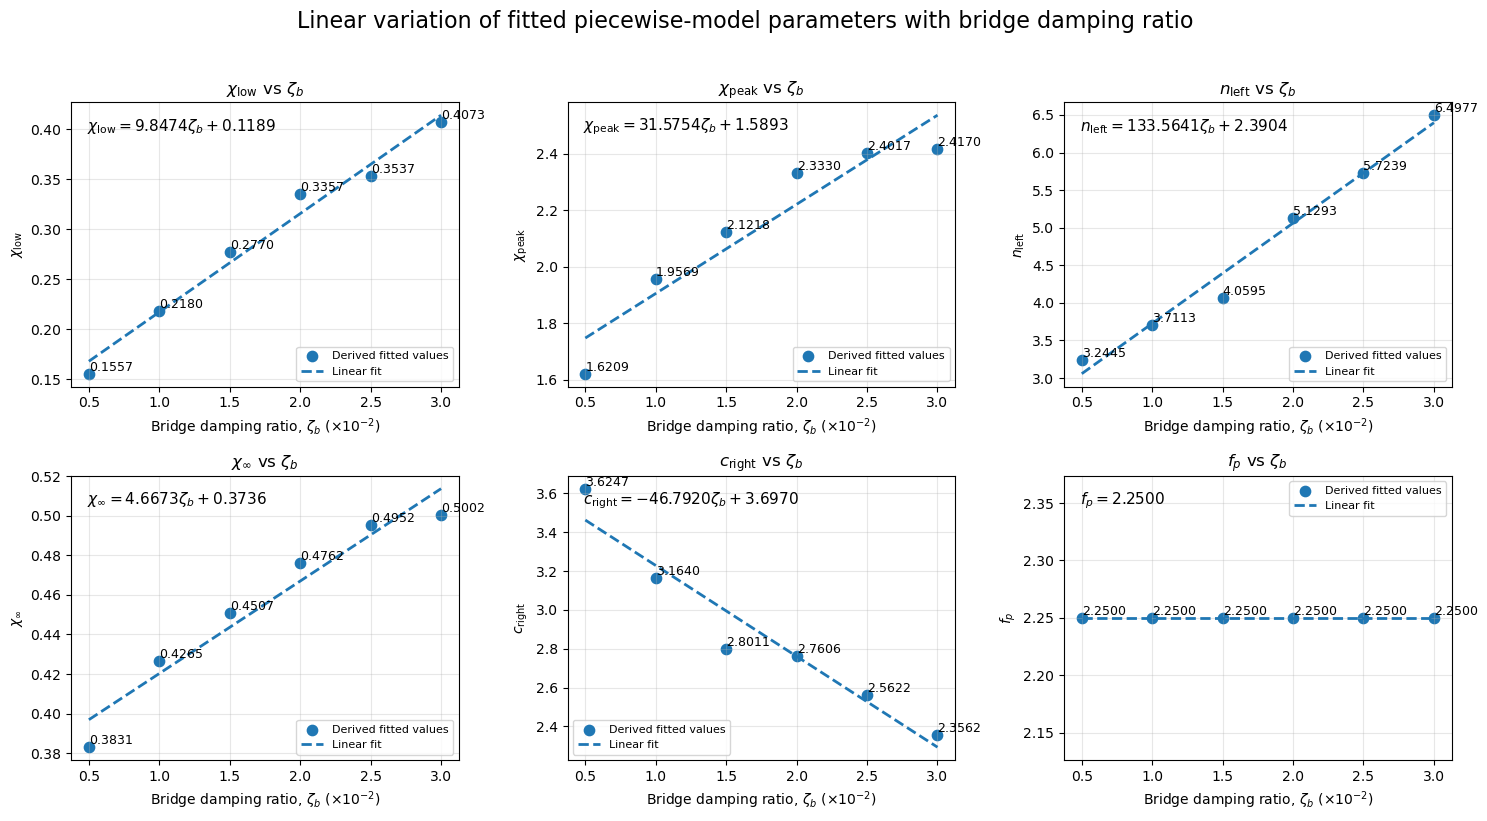


Linear parameter relationships from new fitted values
chi_low(zeta_b) = 0.11890232 + (9.84743736) * zeta_b
chi_peak(zeta_b) = 1.58930500 + (31.57544581) * zeta_b
n_left(zeta_b) = 2.39035303 + (133.56405641) * zeta_b
chi_inf(zeta_b) = 0.37362824 + (4.66728140) * zeta_b
c_right(zeta_b) = 3.69701151 + (-46.79203617) * zeta_b
f_p(zeta_b) = 2.25000000 + (-0.00000000) * zeta_b


In [7]:
# ==================================================
# PARAMETER PLOTS FROM NEW DERIVED FITTED VALUES
# ==================================================

param_df = piecewise_param_df.copy()

# Make sure damping column exists
if "damping" not in param_df.columns:
    raise KeyError("piecewise_param_df must contain a 'damping' column.")

param_df["zeta_b"] = pd.to_numeric(param_df["damping"], errors="coerce")
param_df = param_df.dropna(subset=["zeta_b"]).copy()

# x-axis shown as 0.5, 1.0, 2.0, etc.
param_df["zeta_plot"] = param_df["zeta_b"] * 100.0

# ==================================================
# PARAMETERS TO PLOT
# Same style as your previous parameter plot
# ==================================================

plot_specs = [
    ("chi_low",  r"$\chi_{\mathrm{low}}$"),
    ("chi_peak", r"$\chi_{\mathrm{peak}}$"),
    ("n_left",   r"$n_{\mathrm{left}}$"),
    ("chi_inf",  r"$\chi_{\infty}$"),
    ("c_right",  r"$c_{\mathrm{right}}$"),
    ("f_p",      r"$f_p$"),
]

# Check columns exist
missing_cols = [col for col, label in plot_specs if col not in param_df.columns]

if missing_cols:
    raise KeyError(f"Missing fitted parameter columns: {missing_cols}")

# ==================================================
# CREATE PARAMETER SUBPLOTS
# ==================================================

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

zeta = param_df["zeta_b"].to_numpy()
zeta_plot = param_df["zeta_plot"].to_numpy()

zeta_smooth = np.linspace(zeta.min(), zeta.max(), 300)
zeta_smooth_plot = zeta_smooth * 100.0

linear_fits = {}

for ax, (col, label) in zip(axes, plot_specs):

    y = pd.to_numeric(param_df[col], errors="coerce").to_numpy()

    valid = np.isfinite(zeta) & np.isfinite(y)

    zeta_valid = zeta[valid]
    zeta_plot_valid = zeta_plot[valid]
    y_valid = y[valid]

    if len(y_valid) < 2:
        ax.set_title(rf"{label} vs $\zeta_b$")
        ax.text(
            0.5,
            0.5,
            "Not enough points",
            transform=ax.transAxes,
            ha="center",
            va="center",
            fontsize=11
        )
        ax.grid(True, alpha=0.3)
        continue

    # Linear fit: parameter = a1*zeta_b + a0
    a1, a0 = np.polyfit(zeta_valid, y_valid, 1)

    linear_fits[col] = {
        "a0": a0,
        "a1": a1,
    }

    y_fit = a0 + a1 * zeta_smooth

    # Data points
    ax.scatter(
        zeta_plot_valid,
        y_valid,
        s=55,
        label="Derived fitted values"
    )

    # Linear fit line
    ax.plot(
        zeta_smooth_plot,
        y_fit,
        "--",
        linewidth=2.0,
        label="Linear fit"
    )

    # Value labels
    for xp, yp in zip(zeta_plot_valid, y_valid):
        ax.text(
            xp,
            yp,
            f"{yp:.4f}",
            fontsize=9,
            ha="left",
            va="bottom"
        )

    # Equation annotation
    label_math = label.replace("$", "")

    if abs(a1) < 1e-10:
        eq_text = rf"${label_math} = {a0:.4f}$"
    else:
        sign = "+" if a0 >= 0 else "-"
        eq_text = rf"${label_math} = {a1:.4f}\zeta_b {sign} {abs(a0):.4f}$"

    ax.text(
        0.04,
        0.90,
        eq_text,
        transform=ax.transAxes,
        fontsize=11
    )

    ax.set_title(rf"{label} vs $\zeta_b$")
    ax.set_xlabel(r"Bridge damping ratio, $\zeta_b$ $(\times 10^{-2})$")
    ax.set_ylabel(label)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)


fig.suptitle(
    "Linear variation of fitted piecewise-model parameters with bridge damping ratio",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()


# ==================================================
# PRINT LINEAR EQUATIONS
# ==================================================

print("\nLinear parameter relationships from new fitted values")
print("=" * 70)

for col, label in plot_specs:

    if col not in linear_fits:
        print(f"{col}: not enough data to fit")
        continue

    a0 = linear_fits[col]["a0"]
    a1 = linear_fits[col]["a1"]

    print(f"{col}(zeta_b) = {a0:.8f} + ({a1:.8f}) * zeta_b")

Using TMD linear_equations from notebook memory.

TMD linear parameter equations used for bias calculation
y0(xi_b) = 0.17558094 + (-3.88615871) * xi_b
B(xi_b) = 0.10921371 + (8.31610193) * xi_b
mu(xi_b) = 0.19152251 + (-1.82692650) * xi_b
alpha(xi_b) = 0.49041628 + (6.51309317) * xi_b
zeta_a(xi_b) = 0.37788228 + (-4.18017883) * xi_b
beta_p(xi_b) = 1.00790354 + (0.97082847) * xi_b
f_p(xi_b) = 2.25000000 + (-0.00000000) * xi_b

Piecewise linear parameter equations used for bias calculation
chi_low(zeta_b) = 0.11890232 + (9.84743736) * zeta_b
chi_peak(zeta_b) = 1.58930500 + (31.57544581) * zeta_b
n_left(zeta_b) = 2.39035303 + (133.56405641) * zeta_b
chi_inf(zeta_b) = 0.37362824 + (4.66728140) * zeta_b
c_right(zeta_b) = 3.69701151 + (-46.79203617) * zeta_b
f_p(zeta_b) = 2.25000000 + (-0.00000000) * zeta_b
bump_amp(zeta_b) = -0.04138166 + (7.67380446) * zeta_b
safety_shift(zeta_b) = 0.31257558 + (3.42124284) * zeta_b

Bias comparison calculated
Density: 0.8333
Mass ratio: 0.25
Damping rati

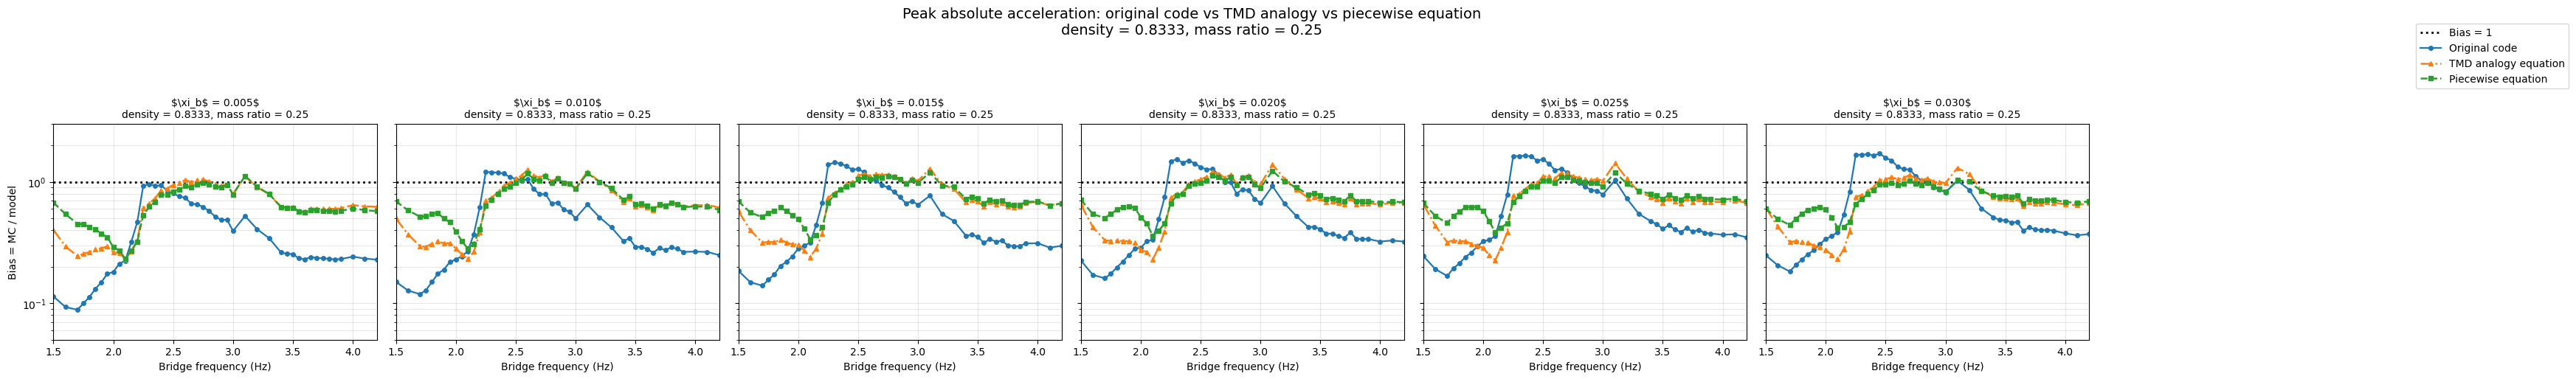


Summary of bias comparison


,measure,damping,density,mass_ratio,method,mean_bias,median_bias,min_bias,max_bias,p05_bias,p95_bias,underprediction_rate_percent,mean_abs_log_bias
0,Peak absolute acceleration,0.005,0.8333,0.25,Original code,0.397113,0.254445,0.088261,0.956731,0.102766,0.929375,100.000000,1.144015
1,Peak absolute acceleration,0.005,0.8333,0.25,TMD analogy equation,0.638619,0.614664,0.228941,1.112826,0.256359,1.034870,89.130435,0.568258
2,Peak absolute acceleration,0.005,0.8333,0.25,Piecewise equation,0.640469,0.596277,0.231949,1.117957,0.275975,0.957807,97.826087,0.518114
3,Peak absolute acceleration,0.010,0.8333,0.25,Original code,0.499530,0.308203,0.118648,1.206383,0.133313,1.185990,82.608696,0.966498
4,Peak absolute acceleration,0.010,0.8333,0.25,TMD analogy equation,0.698398,0.652863,0.231744,1.260829,0.269524,1.143190,80.434783,0.513518
5,Peak absolute acceleration,0.010,0.8333,0.25,Piecewise equation,0.726221,0.657621,0.281714,1.179207,0.341353,1.095235,84.782609,0.403910
6,Peak absolute acceleration,0.015,0.8333,0.25,Original code,0.577457,0.355363,0.139449,1.443460,0.160149,1.373906,80.434783,0.871873
7,Peak absolute acceleration,0.015,0.8333,0.25,TMD analogy equation,0.720902,0.681293,0.239976,1.286079,0.288176,1.152955,73.913043,0.489197
8,Peak absolute acceleration,0.015,0.8333,0.25,Piecewise equation,0.761968,0.698255,0.336077,1.194543,0.413127,1.091543,78.260870,0.353885
9,Peak absolute acceleration,0.020,0.8333,0.25,Original code,0.637566,0.415167,0.160224,1.533782,0.180537,1.468214,78.260870,0.795383


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


# ==================================================
# BIAS COMPARISON:
# ORIGINAL CODE vs TMD EQUATION vs PIECEWISE EQUATION
#
# This cell assumes:
#   1. corrected_df already exists
#   2. piecewise_param_df already exists
#   3. TMD linear equations are available from either:
#        - linear_equations dictionary in memory, OR
#        - linear_equations_from_regularized_fit.csv, OR
#        - fit_summary_df / regularized_peak_locked_fit_parameters_all_dampings.csv
# ==================================================

TARGET_DAMPINGS = [0.005, 0.010, 0.015, 0.020, 0.025, 0.030]

TARGET_DENSITY = 0.8333
TARGET_MASS_RATIO = 0.25

Y_COL_FACTOR = "final_modification_factor"

PLOT_FMIN = 1.50
PLOT_FMAX = 4.20

MEASURES_TO_PLOT = [
    "Peak absolute acceleration",
    # "95% absolute acceleration",
    # "Peak 1-sec RMS",
]

SAVE_PLOTS = False

YMIN = 0.05
YMAX = 3.00

EPS = 1e-12

# Same values used in the piecewise fit
FIT_FMIN = 1.50
F_TARGET_PEAK = 2.25

# For piecewise equation
USE_SAFE_SHIFT = False

# For TMD / MMD analogy
BETA_MIN = 0.20
BETA_MAX = 3.00
N_BETA_PEAK = 6000


# ==================================================
# PART 1
# BUILD TMD PARAMETER EQUATIONS
# ==================================================

TMD_PARAMS_TO_USE = [
    "y0",
    "B",
    "mu",
    "alpha",
    "zeta_a",
    "beta_p",
    "f_p",
]

tmd_linear_coeffs = {}

# --------------------------------------------------
# Option A: use linear_equations already in memory
# --------------------------------------------------

if "linear_equations" in globals():

    print("Using TMD linear_equations from notebook memory.")

    for param in TMD_PARAMS_TO_USE:
        if param not in linear_equations:
            raise KeyError(f"Missing {param} in linear_equations.")

        tmd_linear_coeffs[param] = {
            "a0": linear_equations[param]["intercept"],
            "a1": linear_equations[param]["slope"],
        }

# --------------------------------------------------
# Option B: load from CSV saved by your TMD linear-fit code
# --------------------------------------------------

elif Path("linear_equations_from_regularized_fit.csv").exists():

    print("Loading TMD linear equations from linear_equations_from_regularized_fit.csv")

    eq_df = pd.read_csv("linear_equations_from_regularized_fit.csv")

    required_cols = ["parameter", "slope_m", "intercept_c"]
    missing_cols = [c for c in required_cols if c not in eq_df.columns]

    if missing_cols:
        raise KeyError(
            "linear_equations_from_regularized_fit.csv is missing columns: "
            f"{missing_cols}"
        )

    for param in TMD_PARAMS_TO_USE:

        sub = eq_df[eq_df["parameter"].astype(str) == param]

        if sub.empty:
            raise KeyError(f"Could not find parameter {param} in TMD equation CSV.")

        tmd_linear_coeffs[param] = {
            "a0": float(sub["intercept_c"].iloc[0]),
            "a1": float(sub["slope_m"].iloc[0]),
        }

# --------------------------------------------------
# Option C: rebuild equations from fitted parameter table
# --------------------------------------------------

else:

    csv_file = Path("regularized_peak_locked_fit_parameters_all_dampings.csv")

    if "fit_summary_df" in globals():
        print("Rebuilding TMD equations from fit_summary_df in memory.")
        tmd_param_df = fit_summary_df.copy()

    elif csv_file.exists():
        print(f"Rebuilding TMD equations from {csv_file}")
        tmd_param_df = pd.read_csv(csv_file)

    else:
        raise FileNotFoundError(
            "Could not find TMD linear equations. Need one of these:\n"
            "1. linear_equations in notebook memory, or\n"
            "2. linear_equations_from_regularized_fit.csv, or\n"
            "3. fit_summary_df / regularized_peak_locked_fit_parameters_all_dampings.csv"
        )

    if "zeta_b" in tmd_param_df.columns:
        tmd_param_df = tmd_param_df.rename(columns={"zeta_b": "xi_b"})

    if "xi_b" not in tmd_param_df.columns:
        raise KeyError("TMD parameter table must contain xi_b or zeta_b.")

    for param in TMD_PARAMS_TO_USE:

        if param not in tmd_param_df.columns:
            raise KeyError(f"Missing TMD parameter column: {param}")

        x = pd.to_numeric(tmd_param_df["xi_b"], errors="coerce").to_numpy()
        y = pd.to_numeric(tmd_param_df[param], errors="coerce").to_numpy()

        valid = np.isfinite(x) & np.isfinite(y)

        if valid.sum() < 2:
            raise ValueError(f"Not enough valid points to fit TMD parameter {param}")

        a1, a0 = np.polyfit(x[valid], y[valid], 1)

        tmd_linear_coeffs[param] = {
            "a0": a0,
            "a1": a1,
        }


print("\nTMD linear parameter equations used for bias calculation")
print("=" * 70)

for param in TMD_PARAMS_TO_USE:
    a0 = tmd_linear_coeffs[param]["a0"]
    a1 = tmd_linear_coeffs[param]["a1"]
    print(f"{param}(xi_b) = {a0:.8f} + ({a1:.8f}) * xi_b")


# ==================================================
# TMD / MMD ANALOGY MODEL
# ==================================================

def tmd_parameters_from_equations(xi_b):

    p = {}

    for param in TMD_PARAMS_TO_USE:
        a0 = tmd_linear_coeffs[param]["a0"]
        a1 = tmd_linear_coeffs[param]["a1"]
        p[param] = a0 + a1 * xi_b

    # safety bounds
    p["y0"] = max(p["y0"], EPS)
    p["B"] = max(p["B"], EPS)
    p["mu"] = max(p["mu"], EPS)
    p["alpha"] = max(p["alpha"], EPS)
    p["zeta_a"] = max(p["zeta_a"], EPS)
    p["beta_p"] = max(p["beta_p"], EPS)
    p["f_p"] = max(p["f_p"], EPS)

    return p


def Q_mmd(beta, mu, alpha, zeta_b, zeta_a):

    beta = np.asarray(beta, dtype=float)

    N_R = alpha**2 - beta**2
    N_I = 2.0 * zeta_a * alpha * beta

    D_R = (
        (1.0 - beta**2) * (alpha**2 - beta**2)
        - 4.0 * zeta_b * zeta_a * alpha * beta**2
        - mu * alpha**2 * beta**2
    )

    D_I = (
        2.0 * beta
        * (
            zeta_a * alpha * (1.0 - (1.0 + mu) * beta**2)
            + zeta_b * (alpha**2 - beta**2)
        )
    )

    numerator_abs = np.sqrt(N_R**2 + N_I**2)
    denominator_abs = np.sqrt(D_R**2 + D_I**2)

    return beta**2 * numerator_abs / (denominator_abs + EPS)


def chi_tmd_equation_model(f_bridge, xi_b):
    """
    TMD / MMD analogy equation-based modification factor.

    chi(f_b) = y0 + B * Q(beta_eff)

    beta_eff = beta_p * f_b / f_p

    All parameters are obtained from your linear parameter equations.
    """

    p = tmd_parameters_from_equations(xi_b)

    f_bridge = np.asarray(f_bridge, dtype=float)

    beta_eff = p["beta_p"] * f_bridge / p["f_p"]

    Q_eff = Q_mmd(
        beta=beta_eff,
        mu=p["mu"],
        alpha=p["alpha"],
        zeta_b=xi_b,
        zeta_a=p["zeta_a"],
    )

    chi = p["y0"] + p["B"] * Q_eff

    chi = np.clip(chi, EPS, None)

    return chi


# ==================================================
# PART 2
# BUILD PIECEWISE PARAMETER EQUATIONS
# ==================================================

param_df = piecewise_param_df.copy()

if "damping" not in param_df.columns:
    raise KeyError("piecewise_param_df must contain column: 'damping'")

param_df["zeta_b"] = pd.to_numeric(param_df["damping"], errors="coerce")
param_df = param_df.dropna(subset=["zeta_b"]).copy()

required_param_cols = [
    "chi_low",
    "chi_peak",
    "n_left",
    "chi_inf",
    "c_right",
    "f_p",
]

missing_param_cols = [c for c in required_param_cols if c not in param_df.columns]

if missing_param_cols:
    raise KeyError(f"Missing columns in piecewise_param_df: {missing_param_cols}")

if "bump_amp" not in param_df.columns:
    param_df["bump_amp"] = 0.0

if "safety_shift" not in param_df.columns:
    param_df["safety_shift"] = 0.0

PIECEWISE_PARAMS_TO_USE = [
    "chi_low",
    "chi_peak",
    "n_left",
    "chi_inf",
    "c_right",
    "f_p",
    "bump_amp",
    "safety_shift",
]

piecewise_linear_coeffs = {}

zeta_data = param_df["zeta_b"].to_numpy(dtype=float)

for col in PIECEWISE_PARAMS_TO_USE:

    y_data = pd.to_numeric(param_df[col], errors="coerce").to_numpy(dtype=float)

    valid = np.isfinite(zeta_data) & np.isfinite(y_data)

    if valid.sum() < 2:
        raise ValueError(f"Not enough valid points to fit piecewise parameter {col}")

    # parameter = a0 + a1 * zeta_b
    a1, a0 = np.polyfit(zeta_data[valid], y_data[valid], 1)

    piecewise_linear_coeffs[col] = {
        "a0": a0,
        "a1": a1,
    }


print("\nPiecewise linear parameter equations used for bias calculation")
print("=" * 70)

for col in PIECEWISE_PARAMS_TO_USE:
    a0 = piecewise_linear_coeffs[col]["a0"]
    a1 = piecewise_linear_coeffs[col]["a1"]
    print(f"{col}(zeta_b) = {a0:.8f} + ({a1:.8f}) * zeta_b")


# ==================================================
# PIECEWISE MODEL
# ==================================================

def parameters_from_piecewise_equations(xi_b):

    p = {}

    for col in PIECEWISE_PARAMS_TO_USE:
        a0 = piecewise_linear_coeffs[col]["a0"]
        a1 = piecewise_linear_coeffs[col]["a1"]
        p[col] = a0 + a1 * xi_b

    # safety bounds
    p["chi_low"] = max(p["chi_low"], EPS)
    p["chi_peak"] = max(p["chi_peak"], EPS)
    p["n_left"] = max(p["n_left"], 0.10)
    p["chi_inf"] = max(p["chi_inf"], EPS)
    p["c_right"] = max(p["c_right"], EPS)
    p["f_p"] = max(p["f_p"], EPS)
    p["bump_amp"] = max(p["bump_amp"], 0.0)
    p["safety_shift"] = max(p["safety_shift"], 0.0)

    return p


def chi_piecewise_equation_model(f_bridge, xi_b):
    """
    Piecewise equation-based modification factor.

    For f_b <= f_p:
        chi_L = chi_low + (chi_peak - chi_low) * t^n_left

    For f_b > f_p:
        chi_R = chi_inf + (chi_peak - chi_inf) * exp(-c_right * (f_b - f_p))
    """

    p = parameters_from_piecewise_equations(xi_b)

    f_bridge = np.asarray(f_bridge, dtype=float)

    chi = np.zeros_like(f_bridge, dtype=float)

    f_p = p["f_p"]

    left_mask = f_bridge <= f_p
    right_mask = f_bridge > f_p

    # ------------------------------
    # Left side
    # ------------------------------
    t = (f_bridge[left_mask] - FIT_FMIN) / (f_p - FIT_FMIN)
    t = np.clip(t, 0.0, 1.0)

    chi[left_mask] = (
        p["chi_low"]
        + (p["chi_peak"] - p["chi_low"]) * t ** p["n_left"]
    )

    # ------------------------------
    # Right side
    # ------------------------------
    d = np.maximum(f_bridge[right_mask] - f_p, 0.0)

    chi[right_mask] = (
        p["chi_inf"]
        + (p["chi_peak"] - p["chi_inf"]) * np.exp(-p["c_right"] * d)
    )

    # ------------------------------
    # Optional bump
    # ------------------------------
    if p["bump_amp"] > 0.0:

        BUMP_CENTER = 3.10
        BUMP_WIDTH = 0.10

        g = np.exp(-0.5 * ((f_bridge - BUMP_CENTER) / BUMP_WIDTH) ** 2)
        g0 = np.exp(-0.5 * ((f_p - BUMP_CENTER) / BUMP_WIDTH) ** 2)

        bump_shape = np.maximum(g - g0, 0.0)

        chi = chi + p["bump_amp"] * bump_shape

    # ------------------------------
    # Optional safe shift
    # ------------------------------
    if USE_SAFE_SHIFT:
        chi = chi + p["safety_shift"]

    chi = np.clip(chi, EPS, None)

    return chi


# ==================================================
# PART 3
# PREPARE corrected_df
# ==================================================

df = corrected_df.copy()

required_columns = [
    "bridge_frequency",
    "target_beamdamp",
    "target_density",
    "measure",
    Y_COL_FACTOR,
    "code_bias_mean",
    "code_bias_p5",
    "code_bias_p95",
    "corrected_bias_mean",
    "corrected_bias_p5",
    "corrected_bias_p95",
]

missing_columns = [c for c in required_columns if c not in df.columns]

if missing_columns:
    raise KeyError(f"Missing columns in corrected_df: {missing_columns}")

df["measure"] = df["measure"].astype(str).str.strip()

df["bridge_frequency"] = pd.to_numeric(df["bridge_frequency"], errors="coerce")
df["target_beamdamp"] = pd.to_numeric(df["target_beamdamp"], errors="coerce")
df["target_density"] = pd.to_numeric(df["target_density"], errors="coerce")
df[Y_COL_FACTOR] = pd.to_numeric(df[Y_COL_FACTOR], errors="coerce")

for col in [
    "code_bias_mean",
    "code_bias_p5",
    "code_bias_p95",
    "corrected_bias_mean",
    "corrected_bias_p5",
    "corrected_bias_p95",
]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(
    subset=[
        "bridge_frequency",
        "target_beamdamp",
        "target_density",
        "measure",
        Y_COL_FACTOR,
        "code_bias_mean",
        "code_bias_p5",
        "code_bias_p95",
        "corrected_bias_mean",
        "corrected_bias_p5",
        "corrected_bias_p95",
    ]
).copy()

if "density_key" not in df.columns:
    df["density_key"] = df["target_density"].round(4)

if "damping_key" not in df.columns:
    df["damping_key"] = df["target_beamdamp"].round(3)


# ==================================================
# FILTER TARGET DAMPINGS, DENSITY, AND FREQUENCY RANGE
# ==================================================

damping_mask = np.zeros(len(df), dtype=bool)

for damp in TARGET_DAMPINGS:
    damping_mask |= np.isclose(df["target_beamdamp"], damp)

plot_all_df = df[damping_mask].copy()

plot_all_df = plot_all_df[
    np.isclose(plot_all_df["density_key"], TARGET_DENSITY)
].copy()

plot_all_df = plot_all_df[
    (plot_all_df["bridge_frequency"] >= PLOT_FMIN)
    & (plot_all_df["bridge_frequency"] <= PLOT_FMAX)
].copy()

if plot_all_df.empty:
    raise ValueError(
        "No rows found after filtering. Check TARGET_DAMPINGS, TARGET_DENSITY, "
        "and frequency range."
    )

plot_all_df["chi_final"] = plot_all_df[Y_COL_FACTOR].clip(lower=EPS)


# ==================================================
# PART 4
# CALCULATE TMD AND PIECEWISE EQUATION FACTORS
# ==================================================

plot_all_df["chi_tmd_equation"] = np.nan
plot_all_df["chi_piecewise_equation"] = np.nan

for damp in TARGET_DAMPINGS:

    mask = np.isclose(plot_all_df["target_beamdamp"], damp)

    if mask.any():

        f_values = plot_all_df.loc[mask, "bridge_frequency"].to_numpy()

        plot_all_df.loc[mask, "chi_tmd_equation"] = chi_tmd_equation_model(
            f_bridge=f_values,
            xi_b=damp,
        )

        plot_all_df.loc[mask, "chi_piecewise_equation"] = chi_piecewise_equation_model(
            f_bridge=f_values,
            xi_b=damp,
        )

plot_all_df["chi_tmd_equation"] = plot_all_df["chi_tmd_equation"].clip(lower=EPS)
plot_all_df["chi_piecewise_equation"] = plot_all_df["chi_piecewise_equation"].clip(lower=EPS)


# ==================================================
# PART 5
# CALCULATE BIAS AFTER EACH EQUATION
# ==================================================
# Your existing relationship:
#
# corrected_bias = MC / model_with_pointwise_final_factor
#
# model_with_pointwise_final_factor = base_model * chi_final
# model_with_equation_factor        = base_model * chi_equation
#
# Therefore:
#
# equation_bias = corrected_bias * chi_final / chi_equation
# ==================================================

plot_all_df["scale_final_to_tmd"] = (
    plot_all_df["chi_final"] / plot_all_df["chi_tmd_equation"]
)

plot_all_df["scale_final_to_piecewise"] = (
    plot_all_df["chi_final"] / plot_all_df["chi_piecewise_equation"]
)

for stat in ["mean", "p5", "p95"]:

    plot_all_df[f"tmd_bias_{stat}"] = (
        plot_all_df[f"corrected_bias_{stat}"]
        * plot_all_df["scale_final_to_tmd"]
    )

    plot_all_df[f"piecewise_bias_{stat}"] = (
        plot_all_df[f"corrected_bias_{stat}"]
        * plot_all_df["scale_final_to_piecewise"]
    )

    plot_all_df[f"tmd_bias_{stat}"] = (
        plot_all_df[f"tmd_bias_{stat}"]
        .replace([np.inf, -np.inf], np.nan)
    )

    plot_all_df[f"piecewise_bias_{stat}"] = (
        plot_all_df[f"piecewise_bias_{stat}"]
        .replace([np.inf, -np.inf], np.nan)
    )


print("\nBias comparison calculated")
print("=" * 70)
print("Density:", TARGET_DENSITY)
print("Mass ratio:", TARGET_MASS_RATIO)
print("Damping ratios:", TARGET_DAMPINGS)
print("Use piecewise safe shift:", USE_SAFE_SHIFT)

print("\nAvailable measures after filtering:")
print(plot_all_df["measure"].value_counts().to_string())

print("\nCheck first rows:")
print(
    plot_all_df[
        [
            "target_beamdamp",
            "density_key",
            "bridge_frequency",
            "measure",
            "chi_final",
            "chi_tmd_equation",
            "chi_piecewise_equation",
            "code_bias_mean",
            "corrected_bias_mean",
            "tmd_bias_mean",
            "piecewise_bias_mean",
        ]
    ]
    .sort_values(["measure", "target_beamdamp", "bridge_frequency"])
    .head(40)
    .to_string(index=False)
)


# ==================================================
# PART 6
# PLOT FUNCTION
# Three lines:
#   1. Original code bias
#   2. TMD equation bias
#   3. Piecewise equation bias
# ==================================================

def plot_measure_all_dampings(measure_name):

    measure_df = plot_all_df[
        plot_all_df["measure"].astype(str).str.strip() == measure_name
    ].copy()

    if measure_df.empty:
        print(f"Skipping measure because no rows found: {measure_name}")
        return

    n = len(TARGET_DAMPINGS)

    fig, axes = plt.subplots(
        nrows=1,
        ncols=n,
        figsize=(5.4 * n, 5.2),
        sharex=True,
        sharey=True,
    )

    if n == 1:
        axes = [axes]

    for ax, damp in zip(axes, TARGET_DAMPINGS):

        sub = measure_df[
            np.isclose(measure_df["target_beamdamp"], damp)
        ].copy()

        if sub.empty:
            ax.set_title(rf"$\xi_b$ = {damp:.3f}" + "\nNo data")
            ax.axis("off")
            continue

        sub = sub.sort_values("bridge_frequency")

        ax.axhline(
            1.0,
            linestyle=":",
            linewidth=2.0,
            color="black",
            label="Bias = 1",
        )

        # ------------------------------
        # 1. Original code bias
        # ------------------------------
        ax.plot(
            sub["bridge_frequency"],
            sub["code_bias_mean"],
            marker="o",
            markersize=4,
            linewidth=1.6,
            label="Original code",
        )

        # ------------------------------
        # 2. TMD analogy equation bias
        # ------------------------------
        ax.plot(
            sub["bridge_frequency"],
            sub["tmd_bias_mean"],
            marker="^",
            markersize=4,
            linewidth=1.8,
            linestyle="-.",
            label="TMD analogy equation",
        )

        # ------------------------------
        # 3. Piecewise equation bias
        # ------------------------------
        ax.plot(
            sub["bridge_frequency"],
            sub["piecewise_bias_mean"],
            marker="s",
            markersize=4,
            linewidth=1.8,
            linestyle="--",
            label="Piecewise equation",
        )

        ax.set_title(
            rf"$\xi_b$ = {damp:.3f}$" + "\n"
            f"density = {TARGET_DENSITY:.4f}, mass ratio = {TARGET_MASS_RATIO:.2f}",
            fontsize=10,
        )

        ax.set_xlabel("Bridge frequency (Hz)")
        ax.set_xlim(PLOT_FMIN, PLOT_FMAX)

        ax.set_yscale("log")
        ax.set_ylim(YMIN, YMAX)

        ax.grid(True, which="both", alpha=0.30)

    axes[0].set_ylabel("Bias = MC / model")

    handles, labels = axes[0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        bbox_to_anchor=(1.01, 0.95),
        loc="upper left",
    )

    fig.suptitle(
        f"{measure_name}: original code vs TMD analogy vs piecewise equation\n"
        f"density = {TARGET_DENSITY:.4f}, mass ratio = {TARGET_MASS_RATIO:.2f}",
        fontsize=14,
    )

    fig.tight_layout(rect=[0, 0, 0.88, 0.88])

    if SAVE_PLOTS:
        safe_measure = (
            measure_name
            .replace(" ", "_")
            .replace("%", "pct")
            .replace("/", "_")
        )

        fig_name = (
            f"bias_density{TARGET_DENSITY:.4f}_massratio{TARGET_MASS_RATIO:.2f}_"
            f"{safe_measure}_original_vs_tmd_vs_piecewise.png"
        )

        fig.savefig(fig_name, dpi=300, bbox_inches="tight")
        print("Saved:", fig_name)

    plt.show()


# ==================================================
# PART 7
# MAKE FIGURES
# ==================================================

for measure_name in MEASURES_TO_PLOT:
    plot_measure_all_dampings(measure_name)


# ==================================================
# PART 8
# OPTIONAL SUMMARY TABLE
# ==================================================

summary_rows = []

for measure_name in MEASURES_TO_PLOT:

    measure_df = plot_all_df[
        plot_all_df["measure"].astype(str).str.strip() == measure_name
    ].copy()

    for damp in TARGET_DAMPINGS:

        sub = measure_df[
            np.isclose(measure_df["target_beamdamp"], damp)
        ].copy()

        if sub.empty:
            continue

        for method_label, col in [
            ("Original code", "code_bias_mean"),
            ("TMD analogy equation", "tmd_bias_mean"),
            ("Piecewise equation", "piecewise_bias_mean"),
        ]:

            vals = sub[col].replace([np.inf, -np.inf], np.nan).dropna()

            if vals.empty:
                continue

            summary_rows.append({
                "measure": measure_name,
                "damping": damp,
                "density": TARGET_DENSITY,
                "mass_ratio": TARGET_MASS_RATIO,
                "method": method_label,
                "mean_bias": vals.mean(),
                "median_bias": vals.median(),
                "min_bias": vals.min(),
                "max_bias": vals.max(),
                "p05_bias": np.percentile(vals, 5),
                "p95_bias": np.percentile(vals, 95),
                "underprediction_rate_percent": 100.0 * np.mean(vals < 1.0),
                "mean_abs_log_bias": np.mean(np.abs(np.log(vals))),
            })

summary_df = pd.DataFrame(summary_rows)

print("\nSummary of bias comparison")
print("=" * 70)

if summary_df.empty:
    print("No summary rows generated.")
else:
    display(summary_df)

    if SAVE_PLOTS:
        summary_df.to_csv(
            f"bias_summary_density{TARGET_DENSITY:.4f}_massratio{TARGET_MASS_RATIO:.2f}.csv",
            index=False
        )

Loading: density0.0333_damping0.005_0S125_bias_summary.pkl
Loading: density0.0333_damping0.005_0S456_bias_summary.pkl
Loading: density0.0333_damping0.005_0S_bias_summary.pkl
Loading: density0.0333_damping0.010_0S125_bias_summary.pkl
Loading: density0.0333_damping0.010_0S456_bias_summary.pkl
Loading: density0.0333_damping0.010_0S_bias_summary.pkl
Loading: density0.0333_damping0.015_0S_bias_summary.pkl
Loading: density0.0333_damping0.020_0S125_bias_summary.pkl
Loading: density0.0333_damping0.020_0S456_bias_summary.pkl
Loading: density0.0333_damping0.020_0S_bias_summary.pkl
Loading: density0.0333_damping0.025_0S_bias_summary.pkl
Loading: density0.0333_damping0.030_0S_bias_summary.pkl
Loading: density0.1667_damping0.005_0S125_bias_summary.pkl
Loading: density0.1667_damping0.005_0S456_bias_summary.pkl
Loading: density0.1667_damping0.005_0S_bias_summary.pkl
Loading: density0.1667_damping0.010_0S125_bias_summary.pkl
Loading: density0.1667_damping0.010_0S456_bias_summary.pkl
Loading: density0.

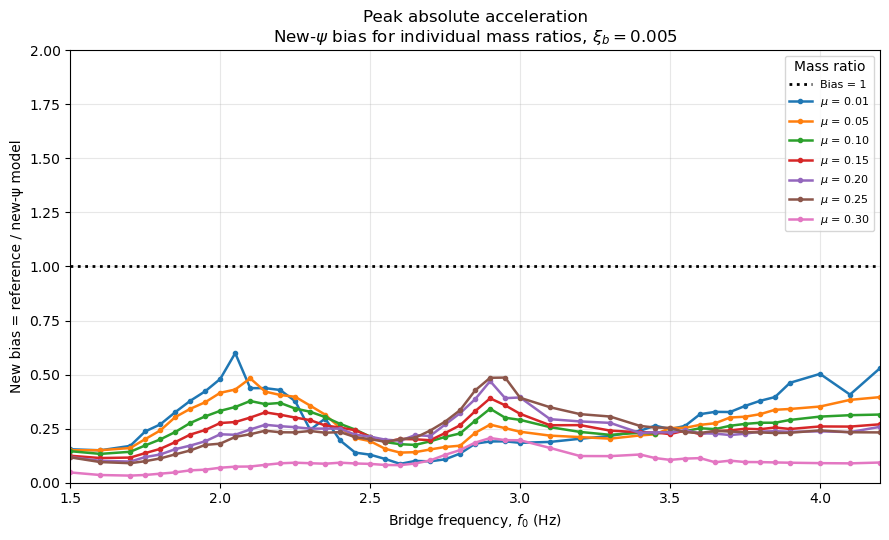

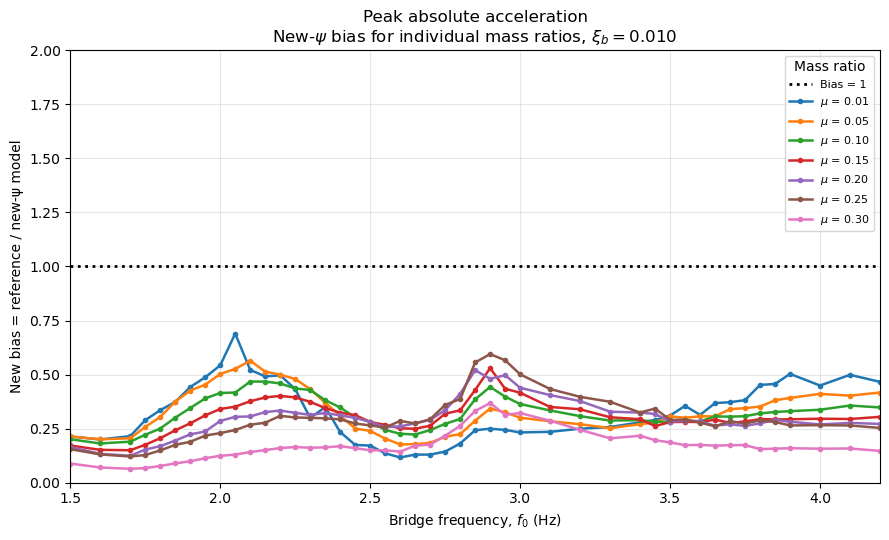

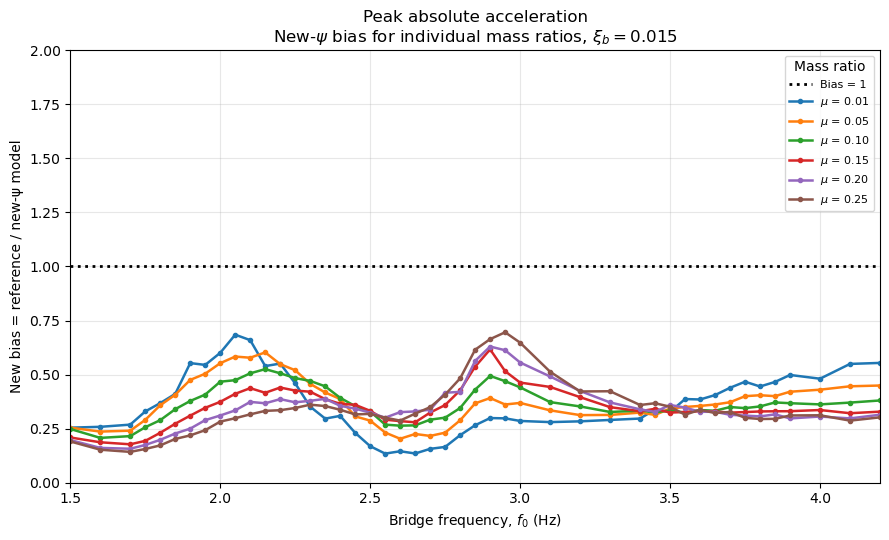

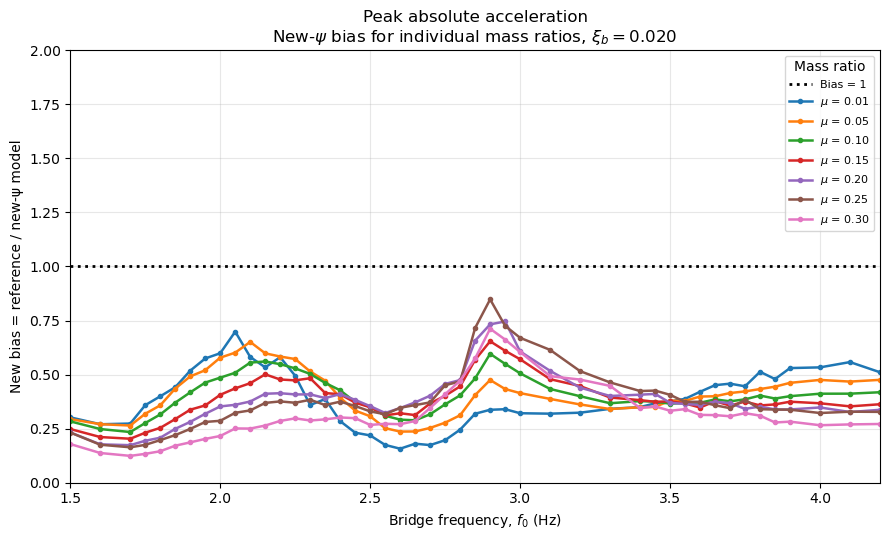

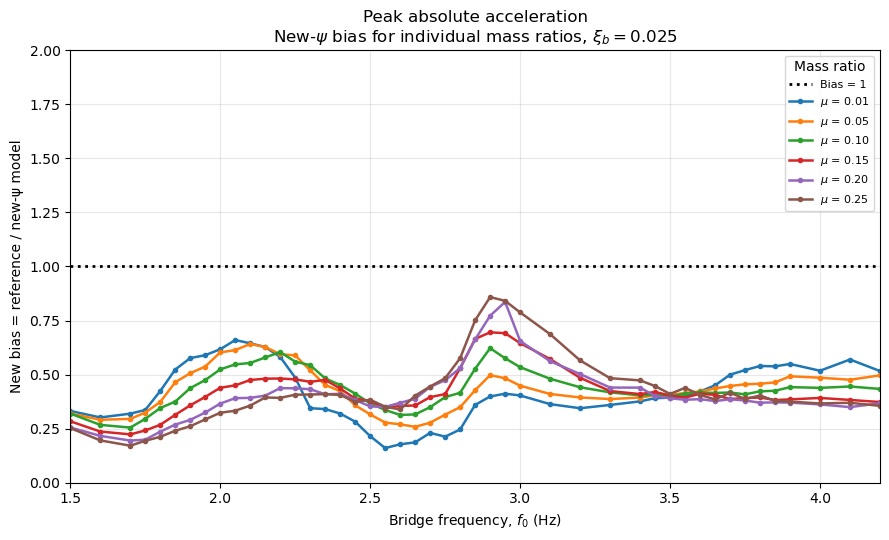

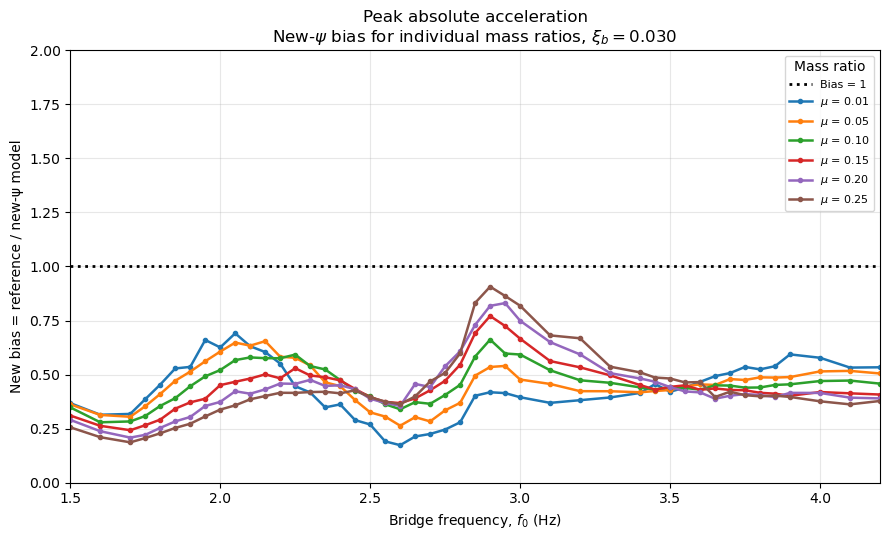

In [14]:
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path

# ==================================================
# SETTINGS
# ==================================================

folder = Path(".")

TARGET_DAMPINGS = [0.005, 0.010, 0.015, 0.020, 0.025, 0.030]

PLOT_FMIN = 1.50
PLOT_FMAX = 4.20

MEASURES_TO_PLOT = [
    "Peak absolute acceleration",
    # "95% absolute acceleration",
    # "Peak 1-sec RMS",
]

SAVE_PLOTS = False

YMIN = 0.05
YMAX = 10.0

EPS = 1e-12
PSI_MIN = 0.02

SHOW_ORIGINAL_CODE_CURVES = True
SHOW_NEWPSI_CURVES = True

density_to_mass_ratio = {
    0.0333: 0.01,
    0.1667: 0.05,
    0.3333: 0.10,
    0.5000: 0.15,
    0.6667: 0.20,
    0.8333: 0.25,
    1.0000: 0.30,
}

# ==================================================
# OLD EN1991 / SETRA psi FUNCTION
# ==================================================

def psi_w_h1_old(x):
    x = np.asarray(x, dtype=float)
    psi = np.zeros_like(x)

    # 1.25–1.70 : 0 -> 1
    m = (x >= 1.25) & (x < 1.70)
    psi[m] = (x[m] - 1.25) / (1.70 - 1.25)

    # 1.70–2.10 : 1
    m = (x >= 1.70) & (x <= 2.10)
    psi[m] = 1.0

    # 2.10–2.30 : 1 -> 0
    m = (x > 2.10) & (x < 2.30)
    psi[m] = 1.0 - (x[m] - 2.10) / (2.30 - 2.10)

    # 2.50–3.40 : 0 -> 0.25
    m = (x > 2.50) & (x < 3.40)
    psi[m] = 0.25 * (x[m] - 2.50) / (3.40 - 2.50)

    # 3.40–4.20 : 0.25
    m = (x >= 3.40) & (x <= 4.20)
    psi[m] = 0.25

    # 4.20–4.60 : 0.25 -> 0
    m = (x > 4.20) & (x <= 4.60)
    psi[m] = 0.25 * (1.0 - (x[m] - 4.20) / (4.60 - 4.20))

    # Minimum rule between 2.25 and 3.0 Hz
    m = (x >= 2.25) & (x <= 3.0)
    psi[m] = np.maximum(psi[m], 0.25)

    return psi

# ==================================================
# NEW UPPER-ENVELOPE SHIFTED psi FUNCTION
# ==================================================

def psi_env_new(x):
    """
    Upper envelope of shifted psi.
    Piecewise equation from the shifted coupled-psi envelope.
    """

    x = np.asarray(x, dtype=float)
    psi = np.zeros_like(x)

    # 1.258 <= f0 <= 1.709
    m = (x >= 1.258) & (x <= 1.709)
    psi[m] = 2.2039 * x[m] - 2.7686

    # 1.709 <= f0 <= 1.711
    m = (x > 1.709) & (x <= 1.711)
    psi[m] = 0.9382 * x[m] - 0.6056

    # 1.711 <= f0 <= 2.566
    m = (x > 1.711) & (x <= 2.566)
    psi[m] = 1.0

    # 2.566 <= f0 <= 2.568
    m = (x > 2.566) & (x <= 2.568)
    psi[m] = -0.6319 * x[m] + 2.6213

    # 2.568 <= f0 <= 2.872
    m = (x > 2.568) & (x <= 2.872)
    psi[m] = -2.4653 * x[m] + 7.3299

    # 2.872 <= f0 <= 2.874
    m = (x > 2.872) & (x <= 2.874)
    psi[m] = -0.0991 * x[m] + 0.5347

    # 2.874 <= f0 <= 4.191
    m = (x > 2.874) & (x <= 4.191)
    psi[m] = 0.25

    # 4.191 <= f0 <= 4.193
    m = (x > 4.191) & (x <= 4.193)
    psi[m] = -0.0880 * x[m] + 0.6190

    # 4.193 <= f0 <= 4.593
    m = (x > 4.193) & (x <= 4.593)
    psi[m] = -0.6250 * x[m] + 2.8706

    psi = np.clip(psi, 0.0, 1.0)

    return psi

# ==================================================
# LOAD ALL 0S, 0S125, 0S456 SUMMARY FILES
# ==================================================

pattern = re.compile(
    r"density(?P<density>\d+\.\d+)_"
    r"damping(?P<damping>\d+\.\d+)_"
    r"(?P<region>0S(?:125|456)?)_bias_summary\.pkl$"
)

pkl_files = sorted(folder.glob("density*_damping*_0S*_bias_summary.pkl"))

all_dfs = []

for file in pkl_files:
    match = pattern.match(file.name)

    if match is None:
        print(f"Skipping file because name does not match expected format: {file.name}")
        continue

    file_density = float(match.group("density"))
    file_damping = float(match.group("damping"))
    file_region = match.group("region")

    print("Loading:", file.name)

    with open(file, "rb") as f:
        df = pickle.load(f)

    if not isinstance(df, pd.DataFrame):
        df = pd.DataFrame(df)

    df = df.copy()

    df["source_file"] = file.name
    df["file_density"] = file_density
    df["file_damping"] = file_damping
    df["file_region"] = file_region

    if "target_density" not in df.columns:
        df["target_density"] = file_density

    if "target_beamdamp" not in df.columns:
        df["target_beamdamp"] = file_damping

    all_dfs.append(df)

if len(all_dfs) == 0:
    raise FileNotFoundError("No matching summary files were found.")

corrected_df = pd.concat(all_dfs, ignore_index=True)

print("\nLoaded combined dataframe shape:", corrected_df.shape)

# ==================================================
# CLEAN DATA
# ==================================================

required_columns = [
    "bridge_frequency",
    "target_density",
    "target_beamdamp",
    "measure",
    "code_bias_mean",
    "code_bias_p5",
    "code_bias_p95",
]

missing_columns = [c for c in required_columns if c not in corrected_df.columns]

if missing_columns:
    raise KeyError(f"Missing columns in corrected_df: {missing_columns}")

for col in [
    "bridge_frequency",
    "target_density",
    "target_beamdamp",
    "code_bias_mean",
    "code_bias_p5",
    "code_bias_p95",
]:
    corrected_df[col] = pd.to_numeric(corrected_df[col], errors="coerce")

corrected_df["measure"] = corrected_df["measure"].astype(str).str.strip()

corrected_df = corrected_df.dropna(subset=required_columns).copy()

corrected_df["density_key"] = corrected_df["target_density"].round(4)
corrected_df["damping_key"] = corrected_df["target_beamdamp"].round(3)

# ==================================================
# KEEP FREQUENCY REGIONS BASED ON FILE CONTENT
# ==================================================

# ==================================================
# KEEP FREQUENCY REGIONS INTELLIGENTLY
# ==================================================
# Older damping cases may have:
#   0S125 = low range
#   0S    = middle range
#   0S456 = high range
#
# Newer damping cases, e.g. 0.015, 0.025, 0.030,
# may have full frequency range stored as 0S.
#
# So:
#   - if only 0S exists for a density/damping pair, keep all 0S rows
#   - if regional files exist, stitch 0S125, 0S, and 0S456

stitched_parts = []

for (damp_key, density_key), g in corrected_df.groupby(["damping_key", "density_key"]):

    available_regions = set(g["file_region"].dropna().unique())

    # Case A: only 0S exists, keep full frequency range
    if available_regions == {"0S"}:
        stitched_parts.append(g.copy())
        continue

    # Case B: regional files exist, stitch them
    g_keep = g[
        (
            (g["file_region"] == "0S125") &
            (g["bridge_frequency"] < 1.40)
        )
        |
        (
            (g["file_region"] == "0S") &
            (g["bridge_frequency"] >= 1.40) &
            (g["bridge_frequency"] <= 3.40)
        )
        |
        (
            (g["file_region"] == "0S456") &
            (g["bridge_frequency"] > 3.40)
        )
    ].copy()

    if g_keep.empty:
        print(
            f"Warning: no stitched rows for damping={damp_key}, "
            f"density={density_key}. Keeping all rows."
        )
        g_keep = g.copy()

    stitched_parts.append(g_keep)

corrected_df = pd.concat(stitched_parts, ignore_index=True)

# Remove duplicate rows if same frequency appears multiple times
corrected_df = corrected_df.sort_values(
    ["damping_key", "density_key", "measure", "bridge_frequency"]
)

corrected_df = corrected_df.drop_duplicates(
    subset=["damping_key", "density_key", "measure", "bridge_frequency"],
    keep="first"
).copy()

# ==================================================
# FILTER TARGET DAMPINGS AND FREQUENCY RANGE
# ==================================================

df = corrected_df.copy()

damping_mask = np.zeros(len(df), dtype=bool)

for damp in TARGET_DAMPINGS:
    damping_mask |= np.isclose(df["target_beamdamp"], damp)

plot_all_df = df[damping_mask].copy()

plot_all_df = plot_all_df[
    (plot_all_df["bridge_frequency"] >= PLOT_FMIN)
    & (plot_all_df["bridge_frequency"] <= PLOT_FMAX)
].copy()

if plot_all_df.empty:
    raise ValueError(
        "No rows found after filtering. Check TARGET_DAMPINGS and frequency range."
    )

# ==================================================
# CALCULATE OLD psi, NEW psi, AND NEW-psi BIAS
# ==================================================
# code_bias = reference / old_code_model
#
# old_code_model uses psi_old
# new_code_model uses psi_env
#
# new_code_model = old_code_model * psi_env / psi_old
#
# therefore:
#
# newpsi_bias = code_bias * psi_old / psi_env
# ==================================================

plot_all_df["psi_old"] = psi_w_h1_old(
    plot_all_df["bridge_frequency"].to_numpy()
)

plot_all_df["psi_env"] = psi_env_new(
    plot_all_df["bridge_frequency"].to_numpy()
)

valid_psi = (
    np.isfinite(plot_all_df["psi_old"])
    & np.isfinite(plot_all_df["psi_env"])
    & (plot_all_df["psi_old"] > PSI_MIN)
    & (plot_all_df["psi_env"] > PSI_MIN)
)

plot_all_df["psi_ratio_old_to_env"] = np.nan
plot_all_df.loc[valid_psi, "psi_ratio_old_to_env"] = (
    plot_all_df.loc[valid_psi, "psi_old"]
    / plot_all_df.loc[valid_psi, "psi_env"]
)

for stat in ["mean", "p5", "p95"]:

    old_col = f"code_bias_{stat}"
    new_col = f"newpsi_bias_{stat}"
    hsi_col = f"hsi_factor_{stat}"

    plot_all_df[new_col] = (
        plot_all_df[old_col]
        * plot_all_df["psi_ratio_old_to_env"]
    )

    plot_all_df[new_col] = (
        plot_all_df[new_col]
        .replace([np.inf, -np.inf], np.nan)
    )

    # HSI factor needed after using the new psi model
    plot_all_df[hsi_col] = plot_all_df[new_col]

# ==================================================
# ADD MASS RATIO COLUMN
# ==================================================

plot_all_df["mass_ratio"] = plot_all_df["density_key"].map(
    lambda d: density_to_mass_ratio.get(round(float(d), 4), np.nan)
)

# ==================================================
# PRINT CHECK
# ==================================================

print("\nAvailable data after filtering:")
print(
    plot_all_df
    .groupby(["damping_key", "density_key", "measure"])["bridge_frequency"]
    .agg(["min", "max", "count"])
    .reset_index()
    .to_string(index=False)
)

# ==================================================
# PLOT FUNCTION: ONE FIGURE PER DAMPING RATIO
# ONLY NEW-psi BIAS
# ==================================================

def plot_newpsi_bias_one_damping(measure_name, damp):

    measure_df = plot_all_df[
        plot_all_df["measure"].astype(str).str.strip() == measure_name
    ].copy()

    sub_damp = measure_df[
        np.isclose(measure_df["target_beamdamp"], damp)
    ].copy()

    if sub_damp.empty:
        print(f"No data for measure={measure_name}, damping={damp:.3f}")
        return

    plt.figure(figsize=(9, 5.5))

    plt.axhline(
        1.0,
        linestyle=":",
        linewidth=2.0,
        color="black",
        label="Bias = 1",
    )

    # --------------------------------------------------
    # Plot only new-psi bias for each mass ratio
    # --------------------------------------------------

    for density in sorted(sub_damp["density_key"].dropna().unique()):

        sub = sub_damp[
            np.isclose(sub_damp["density_key"], density)
        ].copy()

        sub = sub.sort_values("bridge_frequency")

        mr = density_to_mass_ratio.get(round(float(density), 4), None)

        if mr is not None:
            label = rf"$\mu$ = {mr:.2f}"
        else:
            label = f"density = {density:.4f}"

        plt.plot(
            sub["bridge_frequency"],
            sub["newpsi_bias_mean"],
            marker="o",
            markersize=3,
            linewidth=1.8,
            label=label,
        )

    # --------------------------------------------------
    # Formatting
    # --------------------------------------------------

    plt.xlabel(r"Bridge frequency, $f_0$ (Hz)")
    plt.ylabel("New bias = reference / new-ψ model")

    plt.title(
        f"{measure_name}\n"
        rf"New-$\psi$ bias for individual mass ratios, $\xi_b = {damp:.3f}$"
    )

    plt.xlim(1.5, 4.2)
    plt.yscale("linear")
    plt.ylim(0, 2)

    plt.grid(True, which="both", alpha=0.30)

    plt.legend(
        loc="best",
        fontsize=8,
        title="Mass ratio",
    )

    plt.tight_layout()

    if SAVE_PLOTS:
        safe_measure = (
            measure_name
            .replace(" ", "_")
            .replace("%", "pct")
            .replace("/", "_")
        )

        fig_name = (
            f"newpsi_bias_{safe_measure}_"
            f"damping{damp:.3f}.png"
        )

        plt.savefig(fig_name, dpi=300, bbox_inches="tight")
        print("Saved:", fig_name)

    plt.show()
# ==================================================
# MAKE ONE SEPARATE FIGURE PER DAMPING RATIO
# ==================================================

# ==================================================
# MAKE ONE SEPARATE FIGURE PER DAMPING RATIO
# ==================================================

for measure_name in MEASURES_TO_PLOT:
    for damp in TARGET_DAMPINGS:
        plot_newpsi_bias_one_damping(measure_name, damp)

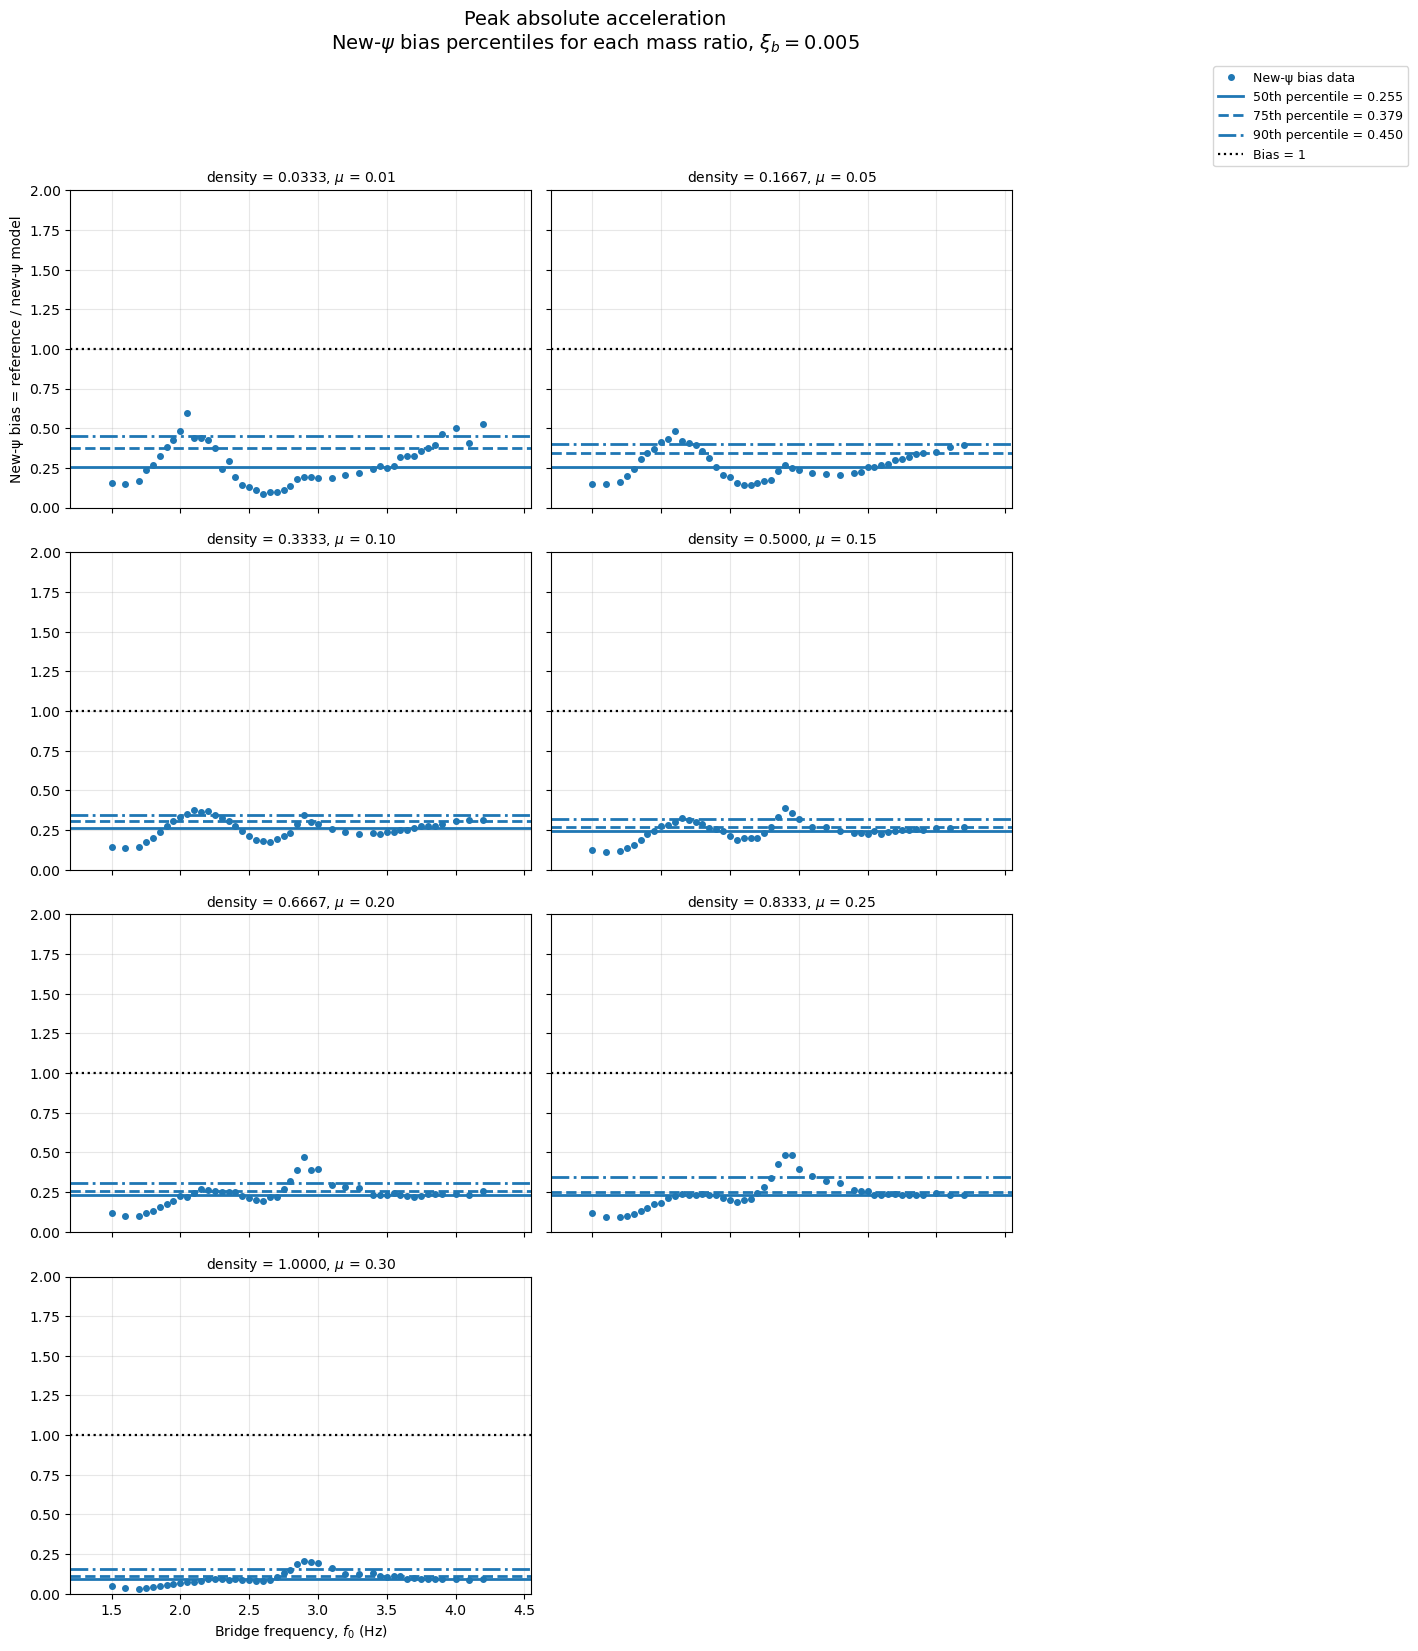


Bias percentile table:
 damping  density  mass_ratio      p50      p75      p90  n_points
   0.005   0.0333        0.01 0.255183 0.378624 0.449658        46
   0.005   0.1667        0.05 0.253381 0.341473 0.401480        46
   0.005   0.3333        0.10 0.260056 0.305138 0.342572        46
   0.005   0.5000        0.15 0.245646 0.269135 0.316446        46
   0.005   0.6667        0.20 0.233770 0.258014 0.307651        46
   0.005   0.8333        0.25 0.232971 0.250846 0.342352        46
   0.005   1.0000        0.30 0.092504 0.113200 0.155800        46


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

# ==================================================
# SETTINGS
# ==================================================

DAMPINGS_TO_PLOT = [0.005]

FIT_MEASURE = "Peak absolute acceleration"
FIT_Y_COL = "newpsi_bias_mean"

FIT_FMIN = 1.20
FIT_FMAX = 4.55

YMIN = 0.0
YMAX = 2.0

SAVE_PERCENTILE_PLOTS = False

PERCENTILES_TO_PLOT = [50, 75, 90]

# ==================================================
# LOOP THROUGH DAMPING RATIOS AND MASS RATIOS
# ==================================================

percentile_rows = []

for damping_to_plot in DAMPINGS_TO_PLOT:

    df_plot = plot_all_df[
        np.isclose(plot_all_df["target_beamdamp"], damping_to_plot)
        & (plot_all_df["measure"].astype(str).str.strip() == FIT_MEASURE)
        & (plot_all_df["bridge_frequency"] >= FIT_FMIN)
        & (plot_all_df["bridge_frequency"] <= FIT_FMAX)
    ].copy()

    if df_plot.empty:
        print(f"No data for damping = {damping_to_plot:.3f}")
        continue

    densities = sorted(df_plot["density_key"].dropna().unique())

    ncols = 2
    nrows = math.ceil(len(densities) / ncols)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(12, 4.2 * nrows),
        sharex=True,
        sharey=True,
    )

    axes = np.asarray(axes).ravel()

    for ax, density in zip(axes, densities):

        sub = df_plot[np.isclose(df_plot["density_key"], density)].copy()
        sub = sub.sort_values("bridge_frequency")

        x_data = sub["bridge_frequency"].to_numpy(dtype=float)
        y_data = sub[FIT_Y_COL].to_numpy(dtype=float)

        valid = (
            np.isfinite(x_data)
            & np.isfinite(y_data)
            & (x_data >= FIT_FMIN)
            & (x_data <= FIT_FMAX)
        )

        x_data = x_data[valid]
        y_data = y_data[valid]

        if len(y_data) == 0:
            ax.set_title(f"density = {density:.4f}\nNo valid data")
            ax.axis("off")
            continue

        mr = density_to_mass_ratio.get(round(float(density), 4), np.nan)

        # ==================================================
        # CALCULATE PERCENTILES
        # ==================================================

        p50 = np.percentile(y_data, 50)
        p75 = np.percentile(y_data, 75)
        p90 = np.percentile(y_data, 90)

        percentile_rows.append({
            "damping": damping_to_plot,
            "density": density,
            "mass_ratio": mr,
            "p50": p50,
            "p75": p75,
            "p90": p90,
            "n_points": len(y_data),
        })

        # ==================================================
        # PLOT DATA
        # ==================================================

        ax.plot(
            x_data,
            y_data,
            "o",
            markersize=4,
            label="New-ψ bias data",
        )

        # ==================================================
        # PLOT STRAIGHT PERCENTILE LINES
        # ==================================================

        ax.axhline(
            p50,
            linestyle="-",
            linewidth=2.0,
            label=f"50th percentile = {p50:.3f}",
        )

        ax.axhline(
            p75,
            linestyle="--",
            linewidth=2.0,
            label=f"75th percentile = {p75:.3f}",
        )

        ax.axhline(
            p90,
            linestyle="-.",
            linewidth=2.0,
            label=f"90th percentile = {p90:.3f}",
        )

        ax.axhline(
            1.0,
            color="black",
            linestyle=":",
            linewidth=1.6,
            label="Bias = 1",
        )

        ax.set_title(
            rf"density = {density:.4f}, $\mu$ = {mr:.2f}",
            fontsize=10,
        )

        ax.set_xlim(FIT_FMIN, FIT_FMAX)
        ax.set_ylim(YMIN, YMAX)
        ax.grid(True, alpha=0.30)

    # hide unused axes
    for ax in axes[len(densities):]:
        ax.axis("off")

    for ax in axes[-ncols:]:
        ax.set_xlabel(r"Bridge frequency, $f_0$ (Hz)")

    axes[0].set_ylabel("New-ψ bias = reference / new-ψ model")

    handles, labels = axes[0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        bbox_to_anchor=(1.01, 0.95),
        loc="upper left",
        fontsize=9,
    )

    fig.suptitle(
        f"{FIT_MEASURE}\n"
        rf"New-$\psi$ bias percentiles for each mass ratio, $\xi_b={damping_to_plot:.3f}$",
        fontsize=14,
    )

    fig.tight_layout(rect=[0, 0, 0.86, 0.93])

    if SAVE_PERCENTILE_PLOTS:
        safe_measure = (
            FIT_MEASURE
            .replace(" ", "_")
            .replace("%", "pct")
            .replace("/", "_")
        )

        fname = (
            f"newpsi_bias_percentiles_each_mass_ratio_"
            f"damping{damping_to_plot:.3f}_{safe_measure}.png"
        )

        fig.savefig(fname, dpi=300, bbox_inches="tight")
        print("Saved:", fname)

    plt.show()


# ==================================================
# PERCENTILE TABLE
# ==================================================

percentile_df = pd.DataFrame(percentile_rows)

print("\nBias percentile table:")
print(percentile_df.to_string(index=False))


Percentile correction factor table:
 damping  density  mass_ratio  n_points  p50_factor  p75_factor  p90_factor  p95_factor
   0.005   0.0333        0.01        50    0.266657    0.418969    0.531695    0.592852
   0.005   0.1667        0.05        50    0.268084    0.368261    0.430909    0.503371
   0.005   0.3333        0.10        50    0.271903    0.314437    0.364022    0.396191
   0.005   0.5000        0.15        50    0.248970    0.287133    0.332875    0.375758
   0.005   0.6667        0.20        50    0.236040    0.268920    0.377763    0.392723
   0.005   0.8333        0.25        50    0.233505    0.262140    0.364870    0.450427
   0.005   1.0000        0.30        50    0.093018    0.120722    0.163189    0.193201
   0.010   0.0333        0.01        50    0.324569    0.463872    0.536563    0.629494
   0.010   0.1667        0.05        50    0.317795    0.423843    0.514905    0.548667
   0.010   0.3333        0.10        50    0.323713    0.396032    0.459929    0.46

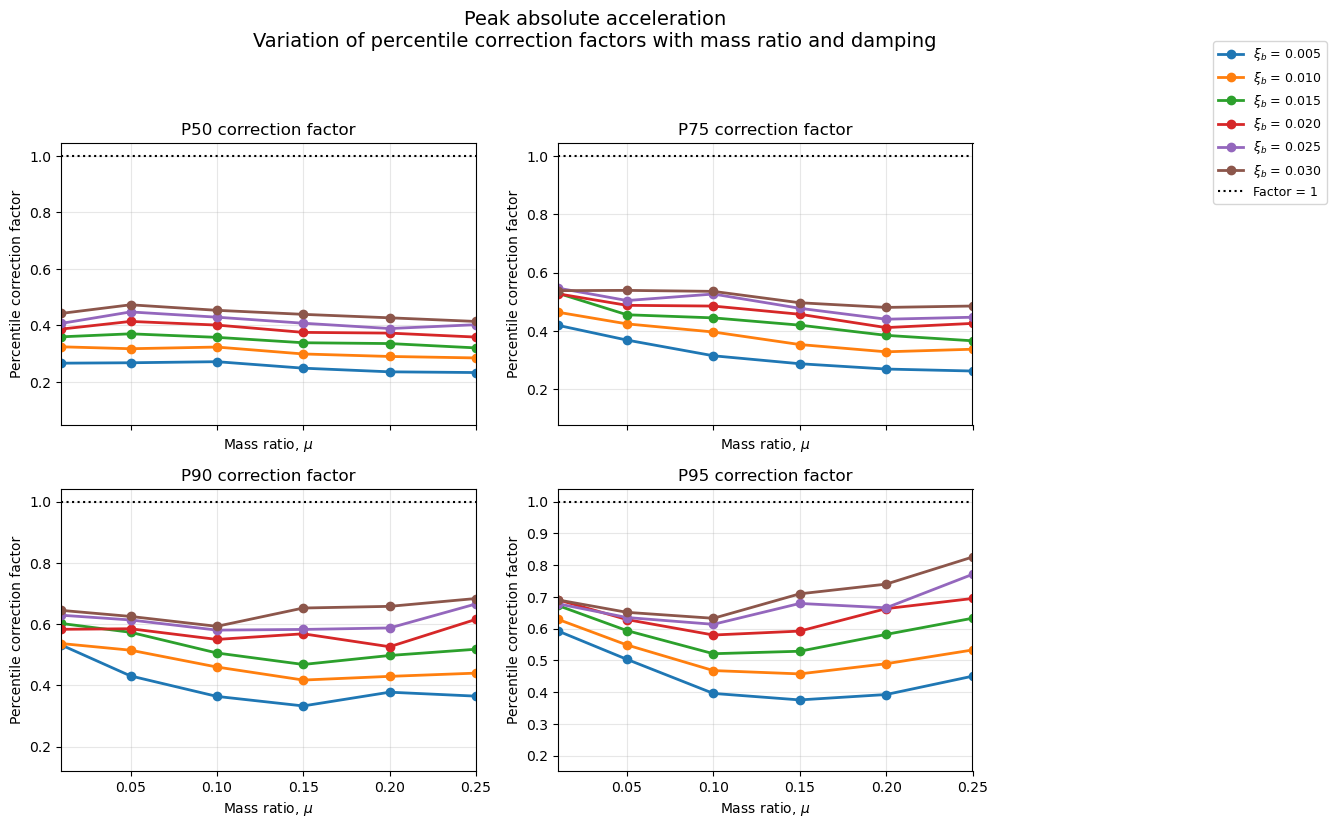

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

# ==================================================
# SETTINGS
# ==================================================

DAMPINGS_TO_PROCESS = [0.005, 0.010, 0.015, 0.020, 0.025, 0.030]
# If you want all damping ratios available in corrected_df, use:
# DAMPINGS_TO_PROCESS = None

MEASURE_TO_USE = "Peak absolute acceleration"

PLOT_FMIN = 1.50
PLOT_FMAX = 4.40

EPS = 1e-12
PSI_MIN = 0.02

PERCENTILES_TO_CALCULATE = [50, 75, 90, 95]

EXCLUDE_DENSITY_1_FROM_PLOT = False
# Set True if you do not want density = 1.0000 in the variation plot

SAVE_PLOT = False

density_to_mass_ratio = {
    0.0333: 0.01,
    0.1667: 0.05,
    0.3333: 0.10,
    0.5000: 0.15,
    0.6667: 0.20,
    0.8333: 0.25,
    1.0000: 0.30,
}

# ==================================================
# OLD EN1991 / SETRA psi FUNCTION
# ==================================================

def psi_w_h1_old(x):
    x = np.asarray(x, dtype=float)
    psi = np.zeros_like(x)

    m = (x >= 1.25) & (x < 1.70)
    psi[m] = (x[m] - 1.25) / (1.70 - 1.25)

    m = (x >= 1.70) & (x <= 2.10)
    psi[m] = 1.0

    m = (x > 2.10) & (x < 2.30)
    psi[m] = 1.0 - (x[m] - 2.10) / (2.30 - 2.10)

    m = (x > 2.50) & (x < 3.40)
    psi[m] = 0.25 * (x[m] - 2.50) / (3.40 - 2.50)

    m = (x >= 3.40) & (x <= 4.20)
    psi[m] = 0.25

    m = (x > 4.20) & (x <= 4.60)
    psi[m] = 0.25 * (1.0 - (x[m] - 4.20) / (4.60 - 4.20))

    # Your additional plateau
    m = (x >= 2.25) & (x <= 3.0)
    psi[m] = np.maximum(psi[m], 0.25)

    return psi


# ==================================================
# NEW UPPER-ENVELOPE SHIFTED psi FUNCTION
# ==================================================

def psi_env_new(x):
    x = np.asarray(x, dtype=float)
    psi = np.zeros_like(x)

    m = (x >= 1.258) & (x <= 1.709)
    psi[m] = 2.2039 * x[m] - 2.7686

    m = (x > 1.709) & (x <= 1.711)
    psi[m] = 0.9382 * x[m] - 0.6056

    m = (x > 1.711) & (x <= 2.566)
    psi[m] = 1.0

    m = (x > 2.566) & (x <= 2.568)
    psi[m] = -0.6319 * x[m] + 2.6213

    m = (x > 2.568) & (x <= 2.872)
    psi[m] = -2.4653 * x[m] + 7.3299

    m = (x > 2.872) & (x <= 2.874)
    psi[m] = -0.0991 * x[m] + 0.5347

    m = (x > 2.874) & (x <= 4.191)
    psi[m] = 0.25

    m = (x > 4.191) & (x <= 4.193)
    psi[m] = -0.0880 * x[m] + 0.6190

    m = (x > 4.193) & (x <= 4.593)
    psi[m] = -0.6250 * x[m] + 2.8706

    return np.clip(psi, 0.0, 1.0)


# ==================================================
# PREPARE DATA
# ==================================================

df = corrected_df.copy()

required_cols = [
    "bridge_frequency",
    "target_beamdamp",
    "target_density",
    "measure",
    "code_bias_mean",
]

missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise KeyError(f"Missing columns in corrected_df: {missing_cols}")

for col in [
    "bridge_frequency",
    "target_beamdamp",
    "target_density",
    "code_bias_mean",
]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["measure"] = df["measure"].astype(str).str.strip()

df["density_key"] = df["target_density"].round(4)
df["damping_key"] = df["target_beamdamp"].round(3)

if DAMPINGS_TO_PROCESS is None:
    dampings_to_use = sorted(df["damping_key"].dropna().unique())
else:
    dampings_to_use = DAMPINGS_TO_PROCESS

work_df = df[
    df["damping_key"].isin([round(d, 3) for d in dampings_to_use])
    & (df["measure"] == MEASURE_TO_USE)
    & (df["bridge_frequency"] >= PLOT_FMIN)
    & (df["bridge_frequency"] <= PLOT_FMAX)
].copy()

if work_df.empty:
    raise ValueError(
        "No data found. Check damping ratios, measure name, and frequency range."
    )

work_df = work_df.sort_values(
    ["damping_key", "density_key", "bridge_frequency"]
).copy()

work_df = work_df.drop_duplicates(
    subset=[
        "damping_key",
        "density_key",
        "bridge_frequency",
        "measure",
    ],
    keep="first"
).copy()


# ==================================================
# CALCULATE NEW-psi BIAS
# ==================================================

work_df["psi_old"] = psi_w_h1_old(
    work_df["bridge_frequency"].to_numpy()
)

work_df["psi_env"] = psi_env_new(
    work_df["bridge_frequency"].to_numpy()
)

valid_psi = (
    np.isfinite(work_df["psi_old"])
    & np.isfinite(work_df["psi_env"])
    & (work_df["psi_old"] > PSI_MIN)
    & (work_df["psi_env"] > PSI_MIN)
)

work_df["psi_ratio_old_to_env"] = np.nan

work_df.loc[valid_psi, "psi_ratio_old_to_env"] = (
    work_df.loc[valid_psi, "psi_old"]
    / work_df.loc[valid_psi, "psi_env"]
)

work_df["newpsi_code_bias_mean"] = (
    work_df["code_bias_mean"]
    * work_df["psi_ratio_old_to_env"]
)

work_df["newpsi_code_bias_mean"] = (
    work_df["newpsi_code_bias_mean"]
    .replace([np.inf, -np.inf], np.nan)
)


# ==================================================
# CALCULATE PERCENTILE FACTORS
# For each damping ratio and mass ratio
# ==================================================

percentile_rows = []

for (damping, density), sub in work_df.groupby(["damping_key", "density_key"]):

    y = sub["newpsi_code_bias_mean"].to_numpy(dtype=float)

    valid = np.isfinite(y) & (y > EPS)
    y = y[valid]

    if len(y) == 0:
        print(
            f"Skipping damping={damping:.3f}, density={density:.4f}: "
            "no valid new-psi bias values."
        )
        continue

    mr = density_to_mass_ratio.get(round(float(density), 4), np.nan)

    row = {
        "damping": damping,
        "density": density,
        "mass_ratio": mr,
        "n_points": len(y),
    }

    for p in PERCENTILES_TO_CALCULATE:
        row[f"p{p}_factor"] = np.percentile(y, p)

    percentile_rows.append(row)

percentile_factor_df = pd.DataFrame(percentile_rows)

if percentile_factor_df.empty:
    raise ValueError("No percentile factors were calculated.")

percentile_factor_df = percentile_factor_df.sort_values(
    ["damping", "mass_ratio"]
).copy()


# ==================================================
# MERGE FACTORS BACK AND CALCULATE CORRECTED BIASES
# ==================================================

work_df = work_df.merge(
    percentile_factor_df,
    left_on=["damping_key", "density_key"],
    right_on=["damping", "density"],
    how="left",
)

for p in PERCENTILES_TO_CALCULATE:
    factor_col = f"p{p}_factor"
    bias_col = f"newpsi_p{p}_bias_mean"

    work_df[bias_col] = (
        work_df["newpsi_code_bias_mean"] / work_df[factor_col]
    )

    work_df[bias_col] = (
        work_df[bias_col]
        .replace([np.inf, -np.inf], np.nan)
    )

# ==================================================
# PRINT PERCENTILE FACTOR TABLE
# ==================================================

print("\nPercentile correction factor table:")
print(percentile_factor_df.to_string(index=False))

for p in PERCENTILES_TO_CALCULATE:
    print(f"\nP{p} factor pivot table:")
    pivot = percentile_factor_df.pivot(
        index="mass_ratio",
        columns="damping",
        values=f"p{p}_factor",
    )
    print(pivot.to_string())


# ==================================================
# PLOT VARIATION OF PERCENTILE FACTORS
# WITH MASS RATIO AND DAMPING
# ==================================================

plot_factor_df = percentile_factor_df.copy()

if EXCLUDE_DENSITY_1_FROM_PLOT:
    plot_factor_df = plot_factor_df[
        ~np.isclose(plot_factor_df["density"], 1.0000)
    ].copy()

n_percentiles = len(PERCENTILES_TO_CALCULATE)

ncols = 2
nrows = math.ceil(n_percentiles / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(12, 4.2 * nrows),
    sharex=True,
)

axes = np.asarray(axes).ravel()

for ax, p in zip(axes, PERCENTILES_TO_CALCULATE):

    factor_col = f"p{p}_factor"

    for damping in sorted(plot_factor_df["damping"].dropna().unique()):

        sub = plot_factor_df[
            np.isclose(plot_factor_df["damping"], damping)
        ].copy()

        sub = sub.sort_values("mass_ratio")

        ax.plot(
            sub["mass_ratio"],
            sub[factor_col],
            marker="o",
            linewidth=2.0,
            label=rf"$\xi_b$ = {damping:.3f}",
        )

    ax.axhline(
        1.0,
        color="black",
        linestyle=":",
        linewidth=1.5,
        label="Factor = 1" if p == PERCENTILES_TO_CALCULATE[0] else None,
    )

    ax.set_title(f"P{p} correction factor")
    ax.set_xlabel(r"Mass ratio, $\mu$")
    ax.set_xlim(0.01, 0.25)
    ax.set_ylabel("Percentile correction factor")
    ax.grid(True, alpha=0.30)

# Hide unused axes
for ax in axes[n_percentiles:]:
    ax.axis("off")

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    bbox_to_anchor=(1.01, 0.95),
    loc="upper left",
    fontsize=9,
)

fig.suptitle(
    f"{MEASURE_TO_USE}\n"
    "Variation of percentile correction factors with mass ratio and damping",
    fontsize=14,
)

fig.tight_layout(rect=[0, 0, 0.84, 0.93])

if SAVE_PLOT:
    safe_measure = (
        MEASURE_TO_USE
        .replace(" ", "_")
        .replace("%", "pct")
        .replace("/", "_")
    )

    fname = f"percentile_factor_variation_{safe_measure}.png"
    fig.savefig(fname, dpi=300, bbox_inches="tight")
    print("Saved:", fname)

plt.show()

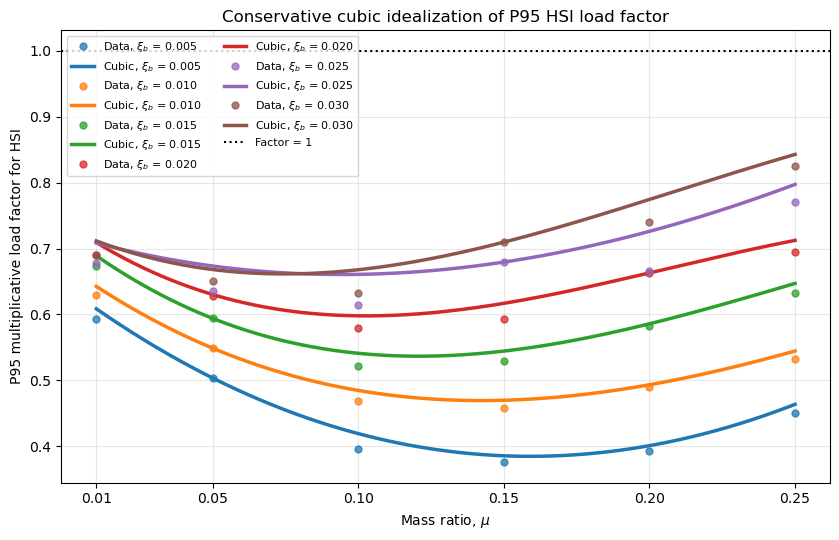


Idealized cubic P95 factors:
 damping  mass_ratio  p95_factor_raw  p95_factor_ideal_cubic
   0.005        0.01        0.592852                0.608527
   0.005        0.05        0.503371                0.503371
   0.005        0.10        0.396191                0.419025
   0.005        0.15        0.375758                0.385413
   0.005        0.20        0.392723                0.400825
   0.005        0.25        0.450427                0.463548
   0.010        0.01        0.629494                0.642526
   0.010        0.05        0.548667                0.548667
   0.010        0.10        0.468126                0.484603
   0.010        0.15        0.457704                0.469704
   0.010        0.20        0.489675                0.493239
   0.010        0.25        0.532978                0.544478
   0.015        0.01        0.673052                0.689017
   0.015        0.05        0.593887                0.593887
   0.015        0.10        0.521206                0.5

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==================================================
# IDEALIZE P95 FACTORS USING ONE CONSERVATIVE CUBIC
# PER DAMPING RATIO
# ==================================================

PERCENTILE_TO_IDEALIZE = 95
FACTOR_COL = f"p{PERCENTILE_TO_IDEALIZE}_factor"

SAFETY_MARGIN = 0.00
CAP_AT_ONE = True

# Use rho < 1 only, so exclude mu = 0.30 if present
EXCLUDE_MU_030 = True

color_map = {
    0.005: "tab:blue",
    0.010: "tab:orange",
    0.015: "tab:green",
    0.020: "tab:red",
    0.025: "tab:purple",
    0.030: "tab:brown",
}

fit_df = percentile_factor_df.copy()

fit_df["damping"] = pd.to_numeric(fit_df["damping"], errors="coerce")
fit_df["mass_ratio"] = pd.to_numeric(fit_df["mass_ratio"], errors="coerce")
fit_df[FACTOR_COL] = pd.to_numeric(fit_df[FACTOR_COL], errors="coerce")

fit_df = fit_df.dropna(subset=["damping", "mass_ratio", FACTOR_COL]).copy()

if EXCLUDE_MU_030:
    fit_df = fit_df[~np.isclose(fit_df["mass_ratio"], 0.30)].copy()

fit_df = fit_df.sort_values(["damping", "mass_ratio"]).copy()

equation_rows = []
idealized_rows = []

fig, ax = plt.subplots(figsize=(8.5, 5.5))

for damping in sorted(fit_df["damping"].unique()):

    sub = fit_df[np.isclose(fit_df["damping"], damping)].copy()
    sub = sub.sort_values("mass_ratio")

    x = sub["mass_ratio"].to_numpy(dtype=float)
    y = sub[FACTOR_COL].to_numpy(dtype=float)

    if len(x) < 4:
        print(f"Skipping xi_b = {damping:.3f}: cubic needs at least 4 points.")
        continue

    # Cubic fit:
    # C95(mu) = a*mu^3 + b*mu^2 + c*mu + d
    a, b, c, d = np.polyfit(x, y, 3)

    # Shift upward so the cubic is conservative at all calculated P95 points
    y_fit_at_data = a*x**3 + b*x**2 + c*x + d
    upward_shift = np.max(y - y_fit_at_data)

    d_safe = d + upward_shift + SAFETY_MARGIN

    y_ideal_at_data = a*x**3 + b*x**2 + c*x + d_safe

    if CAP_AT_ONE:
        y_ideal_at_data = np.minimum(y_ideal_at_data, 1.0)

    for mu, raw_factor, ideal_factor in zip(x, y, y_ideal_at_data):
        idealized_rows.append({
            "damping": damping,
            "mass_ratio": mu,
            "p95_factor_raw": raw_factor,
            "p95_factor_ideal_cubic": ideal_factor,
        })

    equation_rows.append({
        "damping": damping,
        "a": a,
        "b": b,
        "c": c,
        "d_safe": d_safe,
        "equation": rf"$C_{{95}} = {a:.3f}\mu^3 + {b:.3f}\mu^2 + {c:.3f}\mu + {d_safe:.3f}$"
    })

    x_smooth = np.linspace(x.min(), x.max(), 300)
    y_smooth = a*x_smooth**3 + b*x_smooth**2 + c*x_smooth + d_safe

    if CAP_AT_ONE:
        y_smooth = np.minimum(y_smooth, 1.0)

    color = color_map.get(round(float(damping), 3), None)

    # Raw P95 points
    ax.plot(
        x,
        y,
        marker="o",
        linestyle="none",
        markersize=5,
        color=color,
        alpha=0.75,
        label=rf"Data, $\xi_b$ = {damping:.3f}"
    )

    # Idealized cubic curve
    ax.plot(
        x_smooth,
        y_smooth,
        linewidth=2.5,
        color=color,
        label=rf"Cubic, $\xi_b$ = {damping:.3f}"
    )

ax.axhline(
    1.0,
    color="black",
    linestyle=":",
    linewidth=1.5,
    label="Factor = 1"
)

ax.set_xlabel(r"Mass ratio, $\mu$")
ax.set_ylabel("P95 multiplicative load factor for HSI")
ax.set_title("Conservative cubic idealization of P95 HSI load factor")
ax.set_xticks(sorted(fit_df["mass_ratio"].unique()))
ax.grid(True, alpha=0.30)
ax.legend(ncol=2, fontsize=8)

plt.tight_layout()
plt.show()

p95_idealized_cubic_df = pd.DataFrame(idealized_rows)
p95_cubic_equation_df = pd.DataFrame(equation_rows)

print("\nIdealized cubic P95 factors:")
print(p95_idealized_cubic_df.to_string(index=False))

print("\nCubic equations:")
print(p95_cubic_equation_df.to_string(index=False))


Available mass ratios after filtering:
[np.float64(0.01), np.float64(0.05), np.float64(0.1), np.float64(0.15), np.float64(0.2), np.float64(0.25)]

Available damping ratios after filtering:
[np.float64(0.005), np.float64(0.01), np.float64(0.015), np.float64(0.02), np.float64(0.025), np.float64(0.03)]

Bias comparison calculated for all mass ratios

Available measures after filtering:
measure
95% absolute acceleration     1800
Peak 1-sec RMS                1800
Peak absolute acceleration    1800

Check first rows:
 mass_ratio  target_density  target_beamdamp  bridge_frequency                   measure  chi_final  chi_tmd_equation  chi_piecewise_equation  code_bias_mean  corrected_bias_mean  tmd_bias_mean  piecewise_bias_mean
       0.01          0.0333            0.005              1.50 95% absolute acceleration   0.149618          0.282806                0.202380        0.102117             0.682515       0.361084             0.504579
       0.01          0.0333            0.005       

C:\Users\slok0019\AppData\Local\Temp\ipykernel_34128\2301127960.py:641: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(YMIN, YMAX)


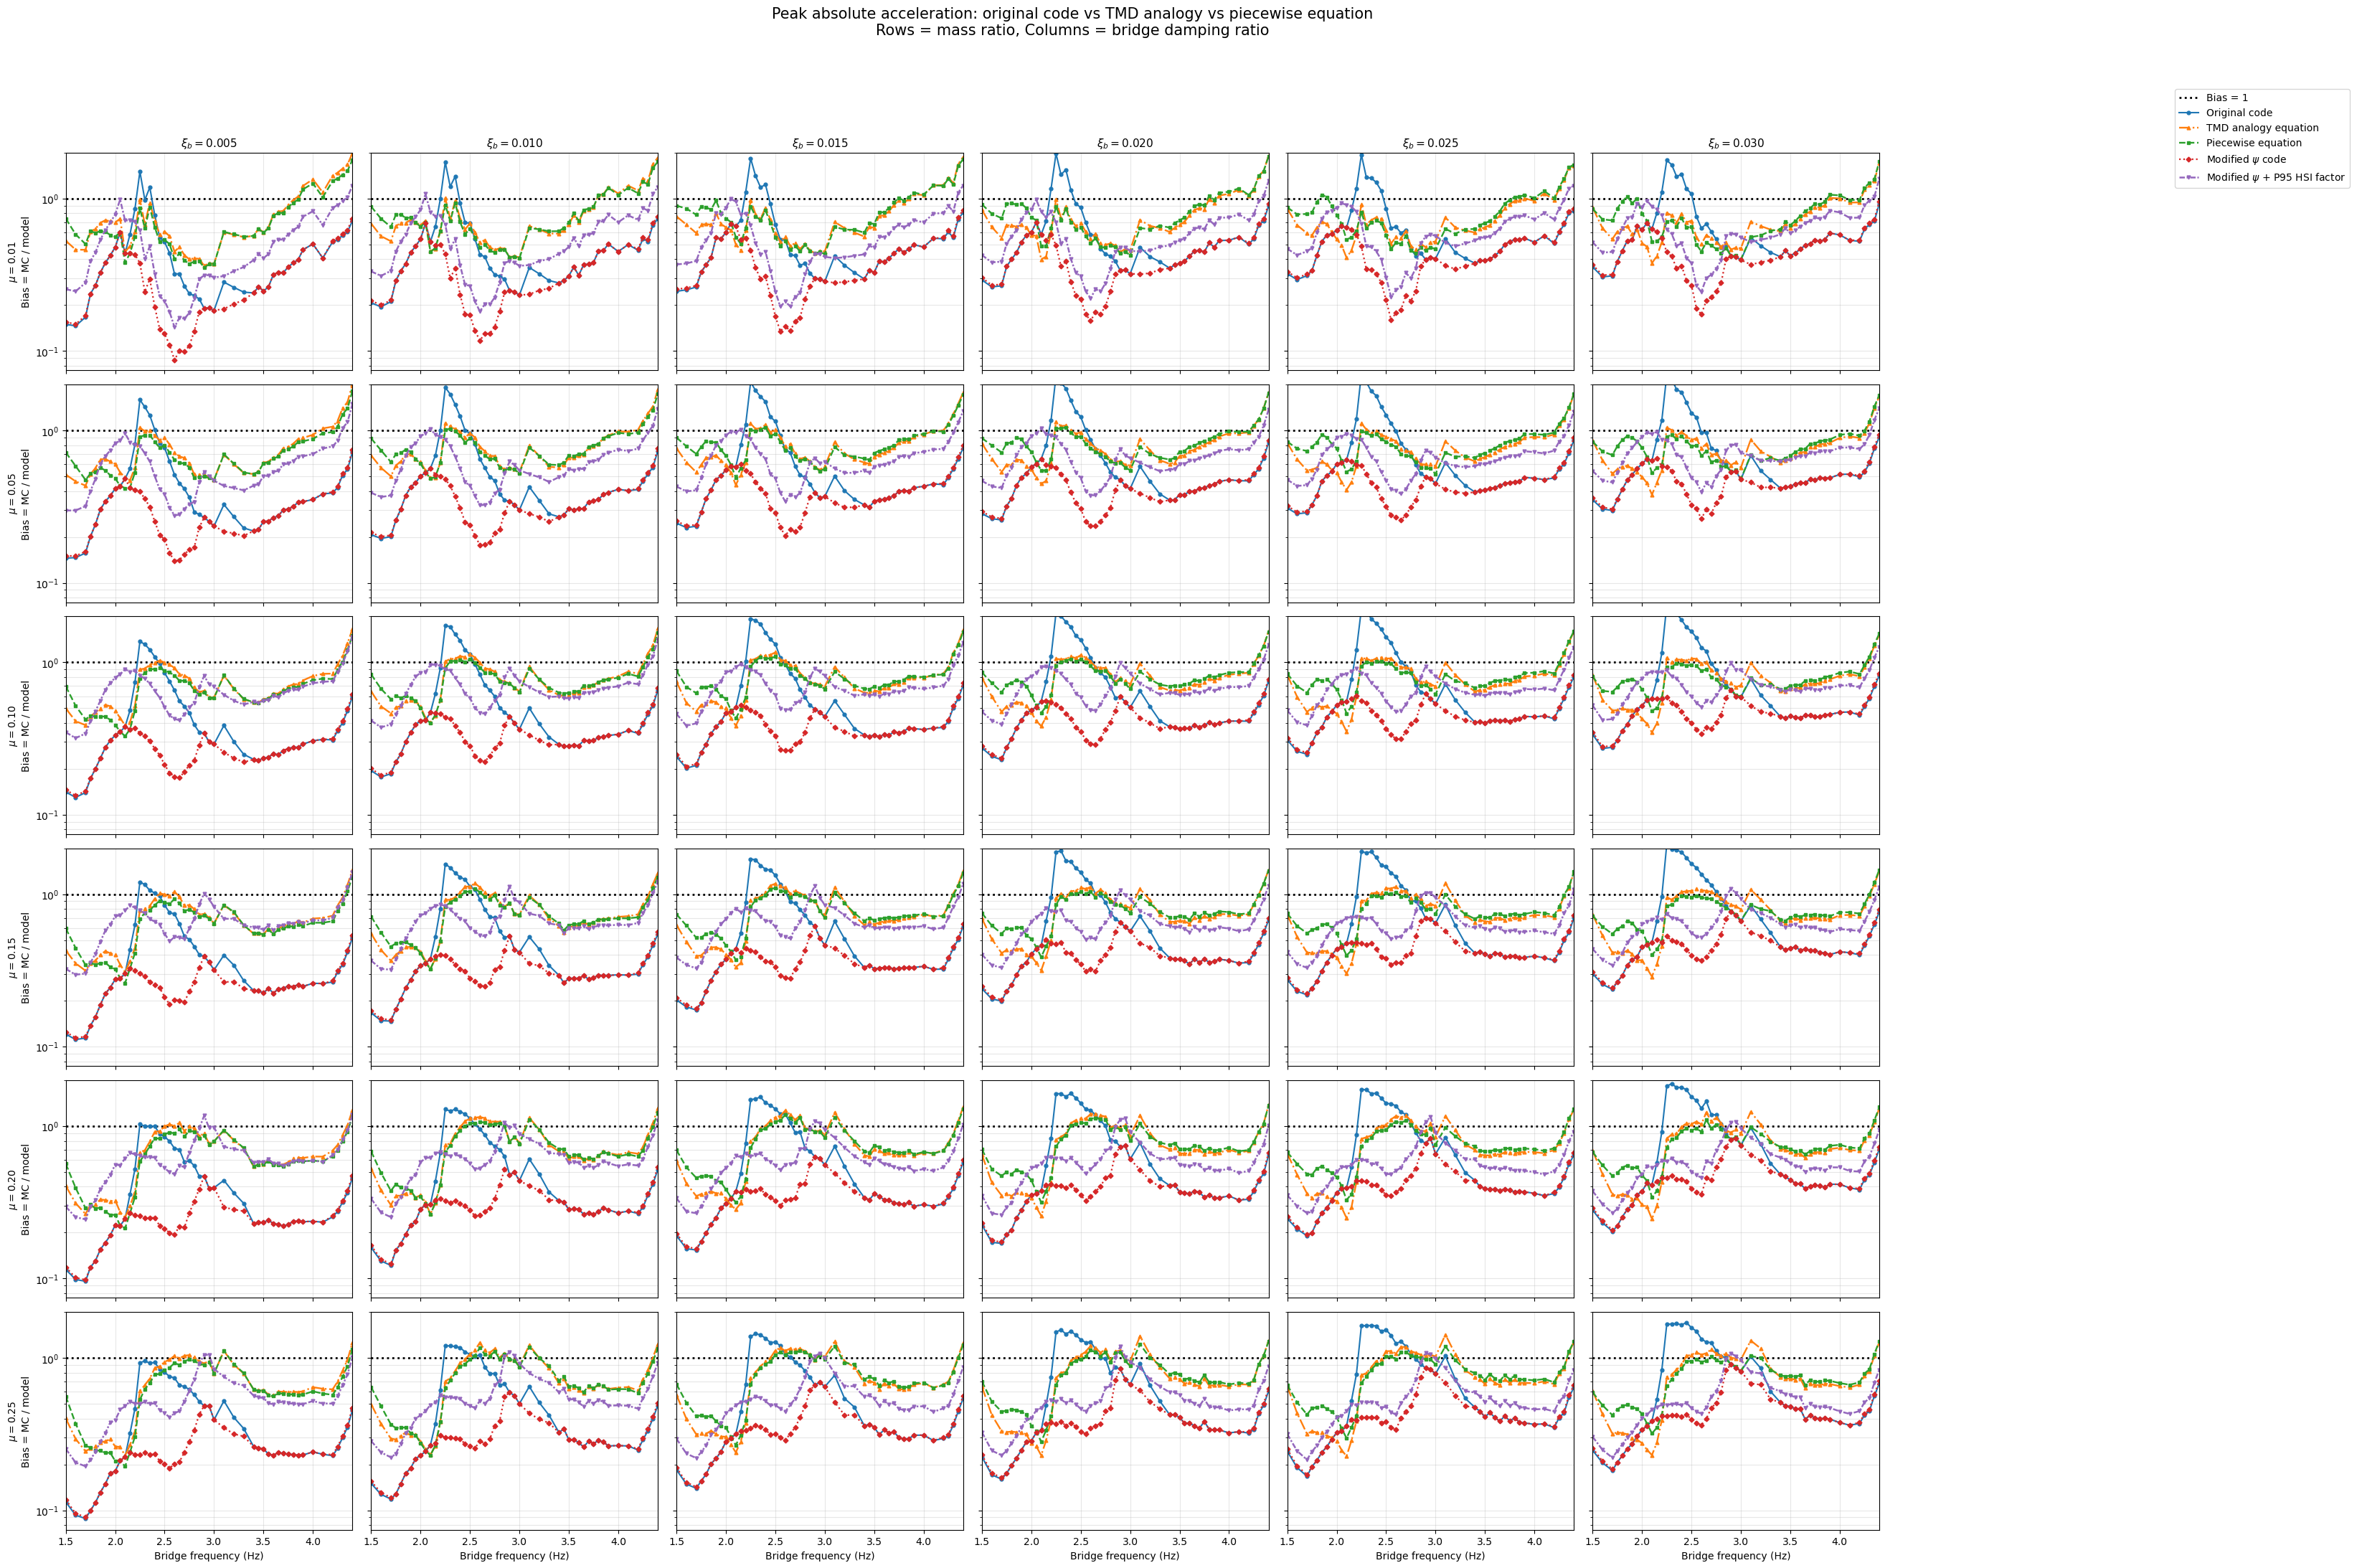


Summary of bias comparison for all mass ratios


,measure,mass_ratio,damping,method,mean_bias,median_bias,min_bias,max_bias,p05_bias,p95_bias,underprediction_rate_percent,mean_abs_log_bias
0,Peak absolute acceleration,0.01,0.005,Original code,0.428225,0.341287,0.145988,1.507806,0.174663,0.924056,96.0,1.017336
1,Peak absolute acceleration,0.01,0.005,TMD analogy equation,0.757422,0.632768,0.362561,1.985073,0.386553,1.531128,82.0,0.494119
2,Peak absolute acceleration,0.01,0.005,Piecewise equation,0.712850,0.603201,0.353794,1.795767,0.372297,1.399812,84.0,0.521634
3,Peak absolute acceleration,0.01,0.010,Original code,0.498194,0.422408,0.194748,1.732869,0.220504,1.105765,94.0,0.869479
4,Peak absolute acceleration,0.01,0.010,TMD analogy equation,0.768801,0.687149,0.411253,1.858636,0.432931,1.332680,78.0,0.428812
...,...,...,...,...,...,...,...,...,...,...,...,...
103,Peak absolute acceleration,0.25,0.025,TMD analogy equation,0.758201,0.730286,0.226440,1.423857,0.285842,1.181278,70.0,0.448906
104,Peak absolute acceleration,0.25,0.025,Piecewise equation,0.768608,0.765867,0.297765,1.284291,0.377186,1.100511,80.0,0.352313
105,Peak absolute acceleration,0.25,0.030,Original code,0.719155,0.484038,0.182589,1.709217,0.216385,1.669853,72.0,0.713051
106,Peak absolute acceleration,0.25,0.030,TMD analogy equation,0.740214,0.734107,0.230529,1.301648,0.276987,1.148149,72.0,0.454038


In [21]:
# ==================================================
# PART 3
# PREPARE corrected_df FOR ALL MASS RATIOS
# ==================================================

df = corrected_df.copy()

required_columns = [
    "bridge_frequency",
    "target_beamdamp",
    "target_density",
    "measure",
    Y_COL_FACTOR,
    "code_bias_mean",
    "code_bias_p5",
    "code_bias_p95",
    "corrected_bias_mean",
    "corrected_bias_p5",
    "corrected_bias_p95",
]

missing_columns = [c for c in required_columns if c not in df.columns]

if missing_columns:
    raise KeyError(f"Missing columns in corrected_df: {missing_columns}")

df["measure"] = df["measure"].astype(str).str.strip()

df["bridge_frequency"] = pd.to_numeric(df["bridge_frequency"], errors="coerce")
df["target_beamdamp"] = pd.to_numeric(df["target_beamdamp"], errors="coerce")
df["target_density"] = pd.to_numeric(df["target_density"], errors="coerce")
df[Y_COL_FACTOR] = pd.to_numeric(df[Y_COL_FACTOR], errors="coerce")

for col in [
    "code_bias_mean",
    "code_bias_p5",
    "code_bias_p95",
    "corrected_bias_mean",
    "corrected_bias_p5",
    "corrected_bias_p95",
]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(
    subset=[
        "bridge_frequency",
        "target_beamdamp",
        "target_density",
        "measure",
        Y_COL_FACTOR,
        "code_bias_mean",
        "code_bias_p5",
        "code_bias_p95",
        "corrected_bias_mean",
        "corrected_bias_p5",
        "corrected_bias_p95",
    ]
).copy()

if "density_key" not in df.columns:
    df["density_key"] = df["target_density"].round(4)

if "damping_key" not in df.columns:
    df["damping_key"] = df["target_beamdamp"].round(3)


# ==================================================
# MASS RATIO MAPPING
# ==================================================
# Edit this if your density-to-mass-ratio mapping changes.

density_to_mass_ratio = {
    0.0333: 0.01,
    0.1667: 0.05,
    0.3333: 0.10,
    0.5000: 0.15,
    0.6667: 0.20,
    0.8333: 0.25,
    
}

density_to_mass_ratio = {
    round(k, 4): v for k, v in density_to_mass_ratio.items()
}

df["mass_ratio"] = df["density_key"].map(density_to_mass_ratio)

df = df.dropna(subset=["mass_ratio"]).copy()


# ==================================================
# TARGET MASS RATIOS
# ==================================================

TARGET_MASS_RATIOS = [
    0.01,
    0.05,
    0.10,
    0.15,
    0.20,
    0.25,
   
]

# If you want to remove 0.25, use:
# TARGET_MASS_RATIOS = [0.01, 0.05, 0.10, 0.15, 0.20, 0.30]


# ==================================================
# FILTER TARGET DAMPINGS, MASS RATIOS, AND FREQUENCY RANGE
# ==================================================

damping_mask = np.zeros(len(df), dtype=bool)

for damp in TARGET_DAMPINGS:
    damping_mask |= np.isclose(df["target_beamdamp"], damp)

mass_mask = np.zeros(len(df), dtype=bool)

for mu in TARGET_MASS_RATIOS:
    mass_mask |= np.isclose(df["mass_ratio"], mu)

plot_all_df = df[damping_mask & mass_mask].copy()

plot_all_df = plot_all_df[
    (plot_all_df["bridge_frequency"] >= PLOT_FMIN)
    & (plot_all_df["bridge_frequency"] <= PLOT_FMAX)
].copy()

if plot_all_df.empty:
    raise ValueError(
        "No rows found after filtering. Check TARGET_DAMPINGS, "
        "TARGET_MASS_RATIOS, and frequency range."
    )

plot_all_df["chi_final"] = plot_all_df[Y_COL_FACTOR].clip(lower=EPS)


print("\nAvailable mass ratios after filtering:")
print(sorted(plot_all_df["mass_ratio"].unique()))

print("\nAvailable damping ratios after filtering:")
print(sorted(plot_all_df["target_beamdamp"].round(3).unique()))


# ==================================================
# PART 4
# CALCULATE TMD AND PIECEWISE EQUATION FACTORS
# ==================================================

plot_all_df["chi_tmd_equation"] = np.nan
plot_all_df["chi_piecewise_equation"] = np.nan

for damp in TARGET_DAMPINGS:

    mask = np.isclose(plot_all_df["target_beamdamp"], damp)

    if mask.any():

        f_values = plot_all_df.loc[mask, "bridge_frequency"].to_numpy()

        plot_all_df.loc[mask, "chi_tmd_equation"] = chi_tmd_equation_model(
            f_bridge=f_values,
            xi_b=damp,
        )

        plot_all_df.loc[mask, "chi_piecewise_equation"] = chi_piecewise_equation_model(
            f_bridge=f_values,
            xi_b=damp,
        )

plot_all_df["chi_tmd_equation"] = plot_all_df["chi_tmd_equation"].clip(lower=EPS)
plot_all_df["chi_piecewise_equation"] = plot_all_df["chi_piecewise_equation"].clip(lower=EPS)


# ==================================================
# PART 5
# CALCULATE BIAS AFTER EACH EQUATION
# ==================================================

plot_all_df["scale_final_to_tmd"] = (
    plot_all_df["chi_final"] / plot_all_df["chi_tmd_equation"]
)

plot_all_df["scale_final_to_piecewise"] = (
    plot_all_df["chi_final"] / plot_all_df["chi_piecewise_equation"]
)

for stat in ["mean", "p5", "p95"]:

    plot_all_df[f"tmd_bias_{stat}"] = (
        plot_all_df[f"corrected_bias_{stat}"]
        * plot_all_df["scale_final_to_tmd"]
    )

    plot_all_df[f"piecewise_bias_{stat}"] = (
        plot_all_df[f"corrected_bias_{stat}"]
        * plot_all_df["scale_final_to_piecewise"]
    )

    plot_all_df[f"tmd_bias_{stat}"] = (
        plot_all_df[f"tmd_bias_{stat}"]
        .replace([np.inf, -np.inf], np.nan)
    )

    plot_all_df[f"piecewise_bias_{stat}"] = (
        plot_all_df[f"piecewise_bias_{stat}"]
        .replace([np.inf, -np.inf], np.nan)
    )


print("\nBias comparison calculated for all mass ratios")
print("=" * 70)

print("\nAvailable measures after filtering:")
print(plot_all_df["measure"].value_counts().to_string())

print("\nCheck first rows:")
print(
    plot_all_df[
        [
            "mass_ratio",
            "target_density",
            "target_beamdamp",
            "bridge_frequency",
            "measure",
            "chi_final",
            "chi_tmd_equation",
            "chi_piecewise_equation",
            "code_bias_mean",
            "corrected_bias_mean",
            "tmd_bias_mean",
            "piecewise_bias_mean",
        ]
    ]
    .sort_values(["measure", "mass_ratio", "target_beamdamp", "bridge_frequency"])
    .head(50)
    .to_string(index=False)
)

# ==================================================
# PART 5B
# ADD MODIFIED-psi BIAS AND MODIFIED-psi + P95 IDEALIZED BIAS
# ==================================================

PSI_MIN = 0.02
CAP_P95_AT_ONE = True

# If your cubic P95 fit excluded mu = 0.30, keep this False.
# If you want to extrapolate the cubic to mu = 0.30, set True.
ALLOW_P95_EXTRAPOLATION = False


# ==================================================
# OLD EN1991 / SETRA psi FUNCTION
# ==================================================

def psi_w_h1_old(x):
    x = np.asarray(x, dtype=float)
    psi = np.zeros_like(x)

    m = (x >= 1.25) & (x < 1.70)
    psi[m] = (x[m] - 1.25) / (1.70 - 1.25)

    m = (x >= 1.70) & (x <= 2.10)
    psi[m] = 1.0

    m = (x > 2.10) & (x < 2.30)
    psi[m] = 1.0 - (x[m] - 2.10) / (2.30 - 2.10)

    m = (x > 2.50) & (x < 3.40)
    psi[m] = 0.25 * (x[m] - 2.50) / (3.40 - 2.50)

    m = (x >= 3.40) & (x <= 4.20)
    psi[m] = 0.25

    m = (x > 4.20) & (x <= 4.60)
    psi[m] = 0.25 * (1.0 - (x[m] - 4.20) / (4.60 - 4.20))

    # Your additional plateau
    m = (x >= 2.25) & (x <= 3.0)
    psi[m] = np.maximum(psi[m], 0.25)

    return psi


# ==================================================
# NEW UPPER-ENVELOPE SHIFTED psi FUNCTION
# ==================================================

def psi_env_new(x):
    x = np.asarray(x, dtype=float)
    psi = np.zeros_like(x)

    m = (x >= 1.258) & (x <= 1.709)
    psi[m] = 2.2039 * x[m] - 2.7686

    m = (x > 1.709) & (x <= 1.711)
    psi[m] = 0.9382 * x[m] - 0.6056

    m = (x > 1.711) & (x <= 2.566)
    psi[m] = 1.0

    m = (x > 2.566) & (x <= 2.568)
    psi[m] = -0.6319 * x[m] + 2.6213

    m = (x > 2.568) & (x <= 2.872)
    psi[m] = -2.4653 * x[m] + 7.3299

    m = (x > 2.872) & (x <= 2.874)
    psi[m] = -0.0991 * x[m] + 0.5347

    m = (x > 2.874) & (x <= 4.191)
    psi[m] = 0.25

    m = (x > 4.191) & (x <= 4.193)
    psi[m] = -0.0880 * x[m] + 0.6190

    m = (x > 4.193) & (x <= 4.593)
    psi[m] = -0.6250 * x[m] + 2.8706

    return np.clip(psi, 0.0, 1.0)


# ==================================================
# CALCULATE MODIFIED-psi BIAS
# ==================================================

plot_all_df["psi_old"] = psi_w_h1_old(
    plot_all_df["bridge_frequency"].to_numpy()
)

plot_all_df["psi_env"] = psi_env_new(
    plot_all_df["bridge_frequency"].to_numpy()
)

valid_psi = (
    np.isfinite(plot_all_df["psi_old"])
    & np.isfinite(plot_all_df["psi_env"])
    & (plot_all_df["psi_old"] > PSI_MIN)
    & (plot_all_df["psi_env"] > PSI_MIN)
)

plot_all_df["psi_ratio_old_to_env"] = np.nan

plot_all_df.loc[valid_psi, "psi_ratio_old_to_env"] = (
    plot_all_df.loc[valid_psi, "psi_old"]
    / plot_all_df.loc[valid_psi, "psi_env"]
)

plot_all_df["newpsi_bias_mean"] = (
    plot_all_df["code_bias_mean"]
    * plot_all_df["psi_ratio_old_to_env"]
)

plot_all_df["newpsi_bias_mean"] = (
    plot_all_df["newpsi_bias_mean"]
    .replace([np.inf, -np.inf], np.nan)
)


# ==================================================
# GET IDEALIZED P95 FACTOR
# ==================================================
# This uses p95_cubic_equation_df from your cubic idealization code.
#
# Required columns:
#   damping, a, b, c, d_safe
#
# Equation:
#   C95(mu) = a*mu^3 + b*mu^2 + c*mu + d_safe
# ==================================================

if "p95_cubic_equation_df" not in globals():
    raise NameError(
        "p95_cubic_equation_df not found. "
        "Run your P95 cubic idealization code first."
    )

p95_eq_df = p95_cubic_equation_df.copy()

required_p95_cols = ["damping", "a", "b", "c", "d_safe"]
missing_p95_cols = [c for c in required_p95_cols if c not in p95_eq_df.columns]

if missing_p95_cols:
    raise KeyError(
        f"p95_cubic_equation_df is missing columns: {missing_p95_cols}"
    )

for col in required_p95_cols:
    p95_eq_df[col] = pd.to_numeric(p95_eq_df[col], errors="coerce")

p95_eq_df = p95_eq_df.dropna(subset=required_p95_cols).copy()

# Estimate fitted mass-ratio range from p95_idealized_cubic_df if available.
# This helps avoid accidental extrapolation to mu = 0.30.
if "p95_idealized_cubic_df" in globals():
    p95_mu_min = float(p95_idealized_cubic_df["mass_ratio"].min())
    p95_mu_max = float(p95_idealized_cubic_df["mass_ratio"].max())
else:
    p95_mu_min = float(plot_all_df["mass_ratio"].min())
    p95_mu_max = 0.25


def p95_idealized_factor(mu, damping):

    if (not ALLOW_P95_EXTRAPOLATION) and (
        (mu < p95_mu_min - 1e-12) or (mu > p95_mu_max + 1e-12)
    ):
        return np.nan

    sub = p95_eq_df[
        np.isclose(p95_eq_df["damping"], damping)
    ].copy()

    if sub.empty:
        return np.nan

    a = float(sub["a"].iloc[0])
    b = float(sub["b"].iloc[0])
    c = float(sub["c"].iloc[0])
    d_safe = float(sub["d_safe"].iloc[0])

    factor = a * mu**3 + b * mu**2 + c * mu + d_safe

    if CAP_P95_AT_ONE:
        factor = min(factor, 1.0)

    factor = max(factor, EPS)

    return factor


plot_all_df["p95_ideal_factor"] = np.nan

for idx, row in plot_all_df.iterrows():

    mu = float(row["mass_ratio"])
    damping = float(row["target_beamdamp"])

    plot_all_df.loc[idx, "p95_ideal_factor"] = p95_idealized_factor(
        mu=mu,
        damping=damping,
    )


# ==================================================
# CALCULATE MODIFIED-psi + P95 IDEALIZED CORRECTED BIAS
# ==================================================

plot_all_df["newpsi_p95ideal_bias_mean"] = (
    plot_all_df["newpsi_bias_mean"]
    / plot_all_df["p95_ideal_factor"]
)

plot_all_df["newpsi_p95ideal_bias_mean"] = (
    plot_all_df["newpsi_p95ideal_bias_mean"]
    .replace([np.inf, -np.inf], np.nan)
)


print("\nAdded modified-psi and modified-psi + P95 idealized bias")
print("=" * 70)

print(
    plot_all_df[
        [
            "mass_ratio",
            "target_beamdamp",
            "bridge_frequency",
            "psi_old",
            "psi_env",
            "psi_ratio_old_to_env",
            "code_bias_mean",
            "newpsi_bias_mean",
            "p95_ideal_factor",
            "newpsi_p95ideal_bias_mean",
        ]
    ]
    .sort_values(["mass_ratio", "target_beamdamp", "bridge_frequency"])
    .head(50)
    .to_string(index=False)
)

# ==================================================
# PART 6
# PLOT FUNCTION
#
# Rows    = mass ratios
# Columns = damping ratios
# Lines   = original code, TMD analogy, piecewise equation
# ==================================================

def plot_measure_all_mass_ratios_and_dampings(measure_name):

    measure_df = plot_all_df[
        plot_all_df["measure"].astype(str).str.strip() == measure_name
    ].copy()

    if measure_df.empty:
        print(f"Skipping measure because no rows found: {measure_name}")
        return

    mass_ratios_available = [
        mu for mu in TARGET_MASS_RATIOS
        if np.any(np.isclose(measure_df["mass_ratio"], mu))
    ]

    dampings_available = [
        damp for damp in TARGET_DAMPINGS
        if np.any(np.isclose(measure_df["target_beamdamp"], damp))
    ]

    n_rows = len(mass_ratios_available)
    n_cols = len(dampings_available)

    fig, axes = plt.subplots(
        nrows=n_rows,
        ncols=n_cols,
        figsize=(5.0 * n_cols, 3.6 * n_rows),
        sharex=True,
        sharey=True,
    )

    if n_rows == 1 and n_cols == 1:
        axes = np.array([[axes]])
    elif n_rows == 1:
        axes = np.array([axes])
    elif n_cols == 1:
        axes = np.array([[ax] for ax in axes])

    for i, mu in enumerate(mass_ratios_available):

        for j, damp in enumerate(dampings_available):

            ax = axes[i, j]

            sub = measure_df[
                np.isclose(measure_df["mass_ratio"], mu)
                & np.isclose(measure_df["target_beamdamp"], damp)
            ].copy()

            if sub.empty:
                ax.set_title(
                    rf"$\mu={mu:.2f}$, $\xi_b={damp:.3f}$" + "\nNo data",
                    fontsize=9,
                )
                ax.axis("off")
                continue

            sub = sub.sort_values("bridge_frequency")

            ax.axhline(
                1.0,
                linestyle=":",
                linewidth=2.0,
                color="black",
                label="Bias = 1" if (i == 0 and j == 0) else None,
            )

            # ------------------------------
            # 1. Original code bias
            # ------------------------------
            ax.plot(
                sub["bridge_frequency"],
                sub["code_bias_mean"],
                marker="o",
                markersize=3.5,
                linewidth=1.5,
                label="Original code" if (i == 0 and j == 0) else None,
            )

            # ------------------------------
            # 2. TMD analogy equation bias
            # ------------------------------
            ax.plot(
                sub["bridge_frequency"],
                sub["tmd_bias_mean"],
                marker="^",
                markersize=3.5,
                linewidth=1.7,
                linestyle="-.",
                label="TMD analogy equation" if (i == 0 and j == 0) else None,
            )

            # ------------------------------
            # 3. Piecewise equation bias
            # ------------------------------
            ax.plot(
                sub["bridge_frequency"],
                sub["piecewise_bias_mean"],
                marker="s",
                markersize=3.5,
                linewidth=1.7,
                linestyle="--",
                label="Piecewise equation" if (i == 0 and j == 0) else None,
            )
            # ------------------------------
            # 4. Modified-psi code bias
            # ------------------------------
            ax.plot(
                sub["bridge_frequency"],
                sub["newpsi_bias_mean"],
                marker="D",
                markersize=3.5,
                linewidth=1.6,
                linestyle=":",
                label=r"Modified $\psi$ code" if (i == 0 and j == 0) else None,
            )

            # ------------------------------
            # 5. Modified-psi + P95 idealized HSI correction
            # ------------------------------
            ax.plot(
                sub["bridge_frequency"],
                sub["newpsi_p95ideal_bias_mean"],
                marker="v",
                markersize=3.5,
                linewidth=1.8,
                linestyle=(0, (3, 1, 1, 1)),
                label=r"Modified $\psi$ + P95 HSI factor" if (i == 0 and j == 0) else None,
            )
            # ------------------------------
            # Titles and labels
            # ------------------------------
            if i == 0:
                ax.set_title(rf"$\xi_b={damp:.3f}$", fontsize=11)

            if j == 0:
                ax.set_ylabel(
                    rf"$\mu={mu:.2f}$" + "\nBias = MC / model",
                    fontsize=10,
                )

            if i == n_rows - 1:
                ax.set_xlabel("Bridge frequency (Hz)")

            ax.set_xlim(PLOT_FMIN, PLOT_FMAX)

            ax.set_yscale("log")
            ax.set_ylim(YMIN, YMAX)

            ax.grid(True, which="both", alpha=0.30)

    handles, labels = axes[0, 0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        bbox_to_anchor=(1.01, 0.96),
        loc="upper left",
    )

    fig.suptitle(
        f"{measure_name}: original code vs TMD analogy vs piecewise equation\n"
        "Rows = mass ratio, Columns = bridge damping ratio",
        fontsize=15,
        y=1.01,
    )

    fig.tight_layout(rect=[0, 0, 0.88, 0.96])

    if SAVE_PLOTS:
        safe_measure = (
            measure_name
            .replace(" ", "_")
            .replace("%", "pct")
            .replace("/", "_")
        )

        fig_name = (
            f"bias_all_mass_ratios_all_dampings_"
            f"{safe_measure}_original_vs_tmd_vs_piecewise.png"
        )

        fig.savefig(fig_name, dpi=300, bbox_inches="tight")
        print("Saved:", fig_name)

    plt.show()


# ==================================================
# PART 7
# MAKE FIGURES
# ==================================================

for measure_name in MEASURES_TO_PLOT:
    plot_measure_all_mass_ratios_and_dampings(measure_name)


# ==================================================
# PART 8
# OPTIONAL SUMMARY TABLE FOR ALL MASS RATIOS
# ==================================================

summary_rows = []

for measure_name in MEASURES_TO_PLOT:

    measure_df = plot_all_df[
        plot_all_df["measure"].astype(str).str.strip() == measure_name
    ].copy()

    for mu in TARGET_MASS_RATIOS:

        for damp in TARGET_DAMPINGS:

            sub = measure_df[
                np.isclose(measure_df["mass_ratio"], mu)
                & np.isclose(measure_df["target_beamdamp"], damp)
            ].copy()

            if sub.empty:
                continue

            for method_label, col in [
                ("Original code", "code_bias_mean"),
                ("TMD analogy equation", "tmd_bias_mean"),
                ("Piecewise equation", "piecewise_bias_mean"),
            ]:

                vals = sub[col].replace([np.inf, -np.inf], np.nan).dropna()

                if vals.empty:
                    continue

                summary_rows.append({
                    "measure": measure_name,
                    "mass_ratio": mu,
                    "damping": damp,
                    "method": method_label,
                    "mean_bias": vals.mean(),
                    "median_bias": vals.median(),
                    "min_bias": vals.min(),
                    "max_bias": vals.max(),
                    "p05_bias": np.percentile(vals, 5),
                    "p95_bias": np.percentile(vals, 95),
                    "underprediction_rate_percent": 100.0 * np.mean(vals < 1.0),
                    "mean_abs_log_bias": np.mean(np.abs(np.log(vals))),
                })

summary_df = pd.DataFrame(summary_rows)

print("\nSummary of bias comparison for all mass ratios")
print("=" * 70)

if summary_df.empty:
    print("No summary rows generated.")
else:
    display(summary_df)

    if SAVE_PLOTS:
        summary_df.to_csv(
            "bias_summary_all_mass_ratios_original_vs_tmd_vs_piecewise.csv",
            index=False
        )


Damping ratios to fit:
[np.float64(0.005), np.float64(0.01), np.float64(0.015), np.float64(0.02), np.float64(0.025), np.float64(0.03)]

Fixed TMD design shift:
TMD_DESIGN_SHIFT = 0.2000

Available data coverage:
 damping_key  density_key  min  max  count
       0.005       0.0333 1.26 4.55    177
       0.005       0.1667 1.26 4.55    177
       0.005       0.3333 1.26 4.55    177
       0.005       0.5000 1.26 4.55    177
       0.005       0.6667 1.26 4.55    177
       0.005       0.8333 1.26 4.55    177
       0.005       1.0000 1.30 4.55    168
       0.010       0.0333 1.26 4.55    177
       0.010       0.1667 1.26 4.55    177
       0.010       0.3333 1.26 4.55    177
       0.010       0.5000 1.26 4.55    177
       0.010       0.6667 1.26 4.55    177
       0.010       0.8333 1.26 4.55    177
       0.010       1.0000 1.26 4.55    177
       0.015       0.0333 1.26 4.55    180
       0.015       0.1667 1.26 4.55    180
       0.015       0.3333 1.26 4.55    180
       0.015 

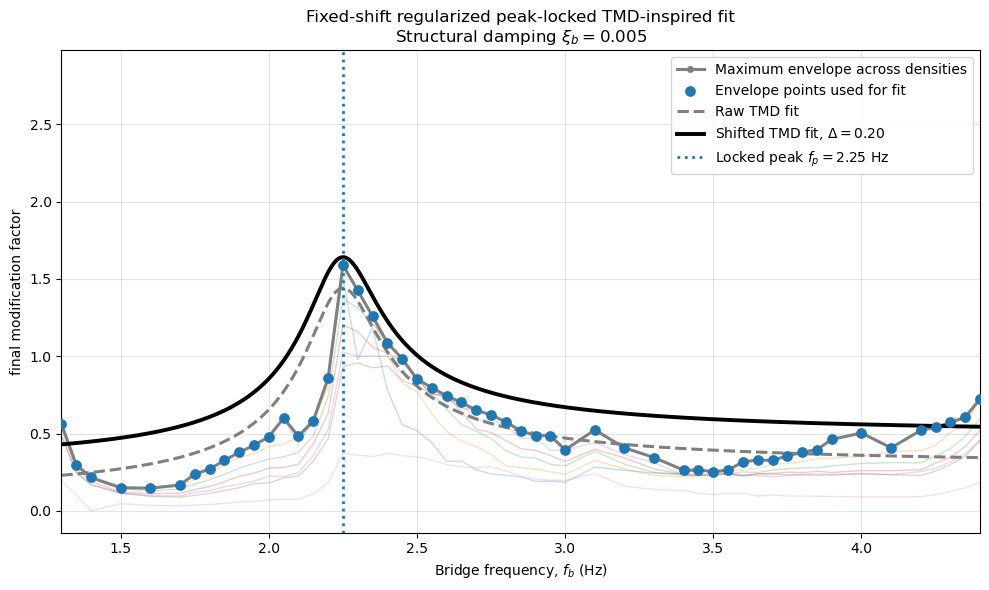


Fitting damping = 0.010
Number of fitting points: 53
Fitting frequency range: 1.3 to 4.4

Reference parameters
--------------------
y0_ref      = 0.14922300
B_ref       = 2.14828000e-01
mu_ref      = 0.16605900
alpha_ref   = 0.55733900
zeta_a_ref  = 0.37235100

Initial guesses
----------------
y0       = 0.18457658
B        = 1.66862507e-01
mu       = 0.16605900
alpha    = 0.55733900
zeta_a   = 0.37235100
beta_p0  = 1.01213536

Bounds used
------------
lower = [0.       0.       0.131059 0.5      0.312351]
upper = [9.59279159e+00 1.00000000e+06 2.01059000e-01 6.37339000e-01
 4.32351000e-01]

Fixed upward safety shift
-------------------------
TMD_DESIGN_SHIFT = 0.20000000
y0 raw           = 0.13934773
y0 shifted       = 0.33934773

Fitted parameters
-----------------
y0 raw              = 0.13934773
y0 shifted          = 0.33934773
B                   = 1.96405776e-01
mu                  = 0.17460887
alpha               = 0.55361355
zeta_b              = 0.01000000 fixed
zeta_a       

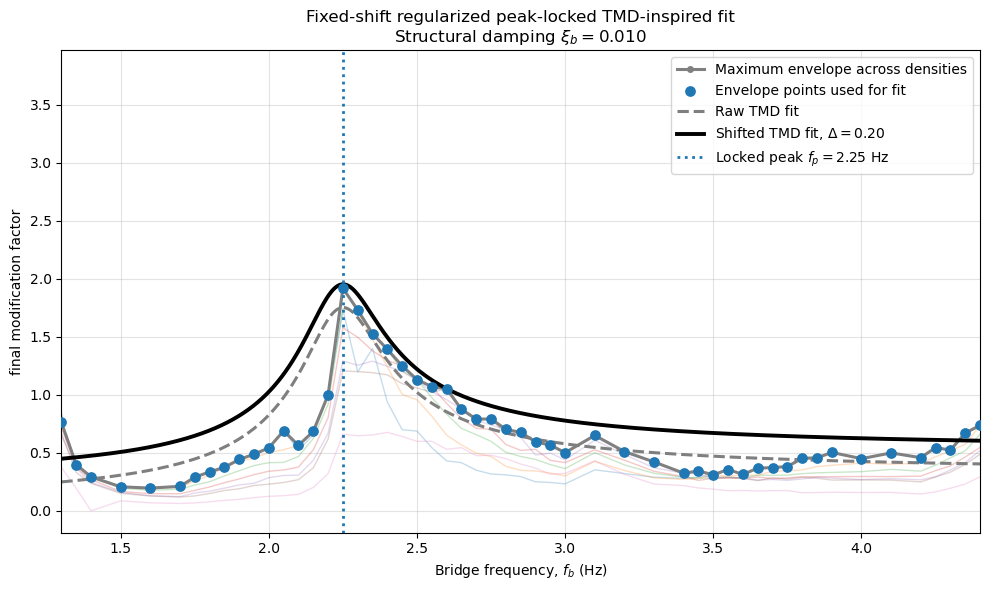


Fitting damping = 0.015
Number of fitting points: 54
Fitting frequency range: 1.3 to 4.4

Reference parameters
--------------------
y0_ref      = 0.17073450
B_ref       = 2.60642000e-01
mu_ref      = 0.15398850
alpha_ref   = 0.59245850
zeta_a_ref  = 0.35467650

Initial guesses
----------------
y0       = 0.19586185
B        = 1.99242646e-01
mu       = 0.15398850
alpha    = 0.59245850
zeta_a   = 0.35467650
beta_p0  = 1.01540257

Bounds used
------------
lower = [0.        0.        0.1189885 0.5124585 0.2946765]
upper = [1.04008067e+01 1.00000000e+06 1.88988500e-01 6.72458500e-01
 4.14676500e-01]

Fixed upward safety shift
-------------------------
TMD_DESIGN_SHIFT = 0.20000000
y0 raw           = 0.12019828
y0 shifted       = 0.32019828

Fitted parameters
-----------------
y0 raw              = 0.12019828
y0 shifted          = 0.32019828
B                   = 2.39667951e-01
mu                  = 0.16608910
alpha               = 0.59412479
zeta_b              = 0.01500000 fixed
zeta_a  

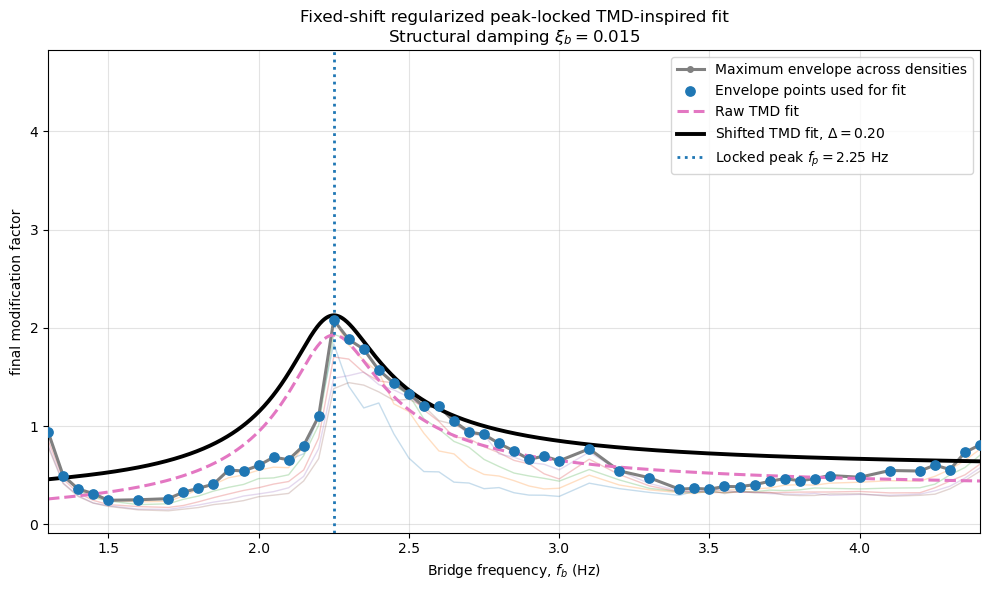


Fitting damping = 0.020
Number of fitting points: 53
Fitting frequency range: 1.3 to 4.4

Reference parameters
--------------------
y0_ref      = 0.19224600
B_ref       = 3.06456000e-01
mu_ref      = 0.14191800
alpha_ref   = 0.62757800
zeta_a_ref  = 0.33700200

Initial guesses
----------------
y0       = 0.19781183
B        = 2.25501066e-01
mu       = 0.14191800
alpha    = 0.62757800
zeta_a   = 0.33700200
beta_p0  = 1.01820303

Bounds used
------------
lower = [0.       0.       0.106918 0.547578 0.277002]
upper = [1.14361058e+01 1.00000000e+06 1.76918000e-01 7.07578000e-01
 3.97002000e-01]

Fixed upward safety shift
-------------------------
TMD_DESIGN_SHIFT = 0.20000000
y0 raw           = 0.10041851
y0 shifted       = 0.30041851

Fitted parameters
-----------------
y0 raw              = 0.10041851
y0 shifted          = 0.30041851
B                   = 2.78166016e-01
mu                  = 0.15456001
alpha               = 0.61679558
zeta_b              = 0.02000000 fixed
zeta_a       

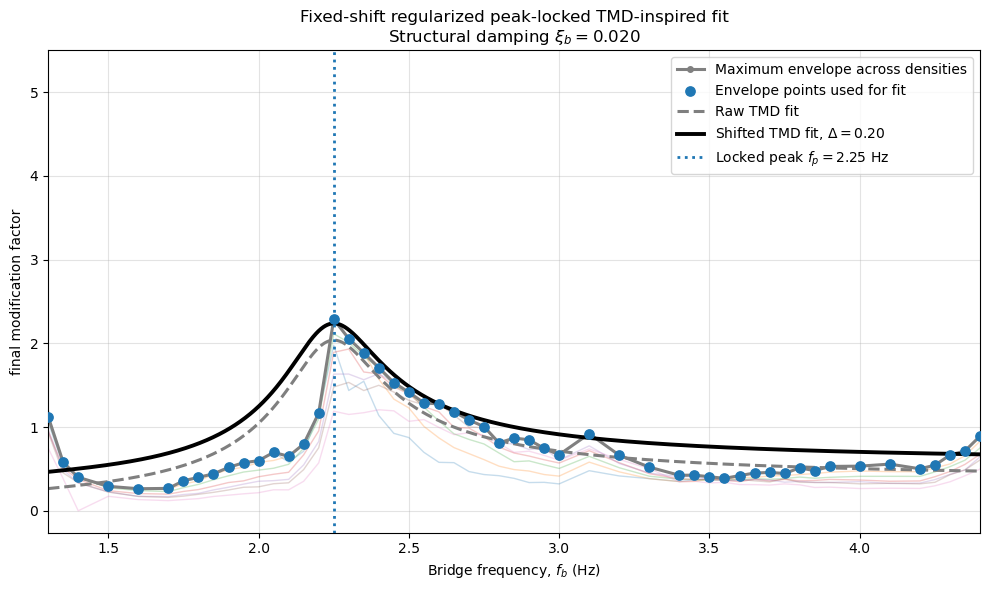


Fitting damping = 0.025
Number of fitting points: 54
Fitting frequency range: 1.3 to 4.4

Reference parameters
--------------------
y0_ref      = 0.21375750
B_ref       = 3.52270000e-01
mu_ref      = 0.12984750
alpha_ref   = 0.66269750
zeta_a_ref  = 0.31932750

Initial guesses
----------------
y0       = 0.20698616
B        = 2.46436668e-01
mu       = 0.12984750
alpha    = 0.66269750
zeta_a   = 0.31932750
beta_p0  = 1.02193699

Bounds used
------------
lower = [0.        0.        0.0948475 0.5826975 0.2593275]
upper = [1.17730019e+01 1.00000000e+06 1.64847500e-01 7.42697500e-01
 3.79327500e-01]

Fixed upward safety shift
-------------------------
TMD_DESIGN_SHIFT = 0.20000000
y0 raw           = 0.07181675
y0 shifted       = 0.27181675

Fitted parameters
-----------------
y0 raw              = 0.07181675
y0 shifted          = 0.27181675
B                   = 3.24310757e-01
mu                  = 0.14813201
alpha               = 0.66407763
zeta_b              = 0.02500000 fixed
zeta_a  

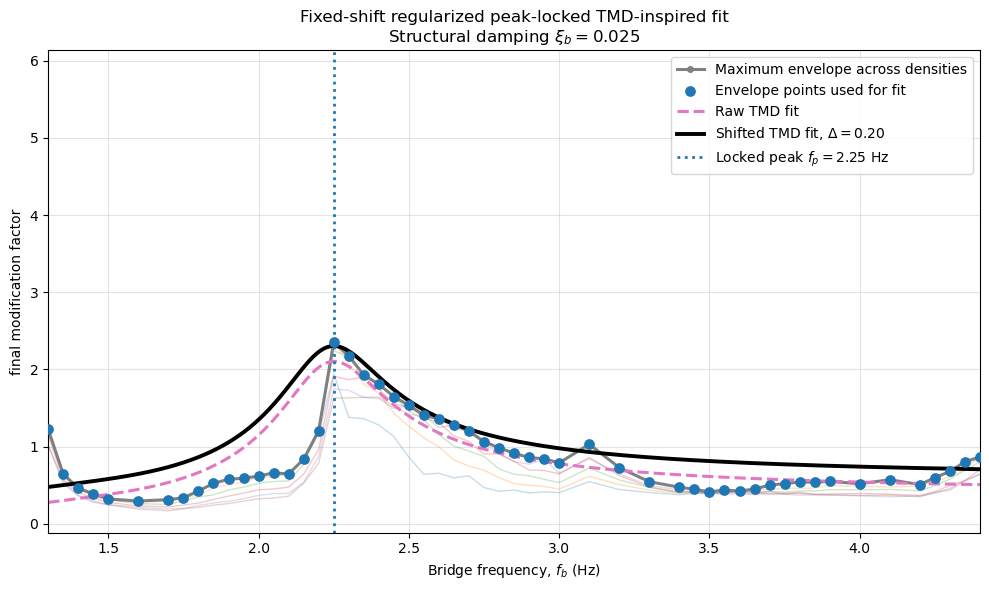


Fitting damping = 0.030
Number of fitting points: 54
Fitting frequency range: 1.3 to 4.4

Reference parameters
--------------------
y0_ref      = 0.23526900
B_ref       = 3.98084000e-01
mu_ref      = 0.11777700
alpha_ref   = 0.69781700
zeta_a_ref  = 0.30165300

Initial guesses
----------------
y0       = 0.21533152
B        = 2.63579511e-01
mu       = 0.11777700
alpha    = 0.69781700
zeta_a   = 0.30165300
beta_p0  = 1.02520420

Bounds used
------------
lower = [0.       0.       0.082777 0.617817 0.25    ]
upper = [1.18478981e+01 1.00000000e+06 1.52777000e-01 7.77817000e-01
 3.61653000e-01]

Fixed upward safety shift
-------------------------
TMD_DESIGN_SHIFT = 0.20000000
y0 raw           = 0.06105834
y0 shifted       = 0.26105834

Fitted parameters
-----------------
y0 raw              = 0.06105834
y0 shifted          = 0.26105834
B                   = 3.48271707e-01
mu                  = 0.13408367
alpha               = 0.67745328
zeta_b              = 0.03000000 fixed
zeta_a       

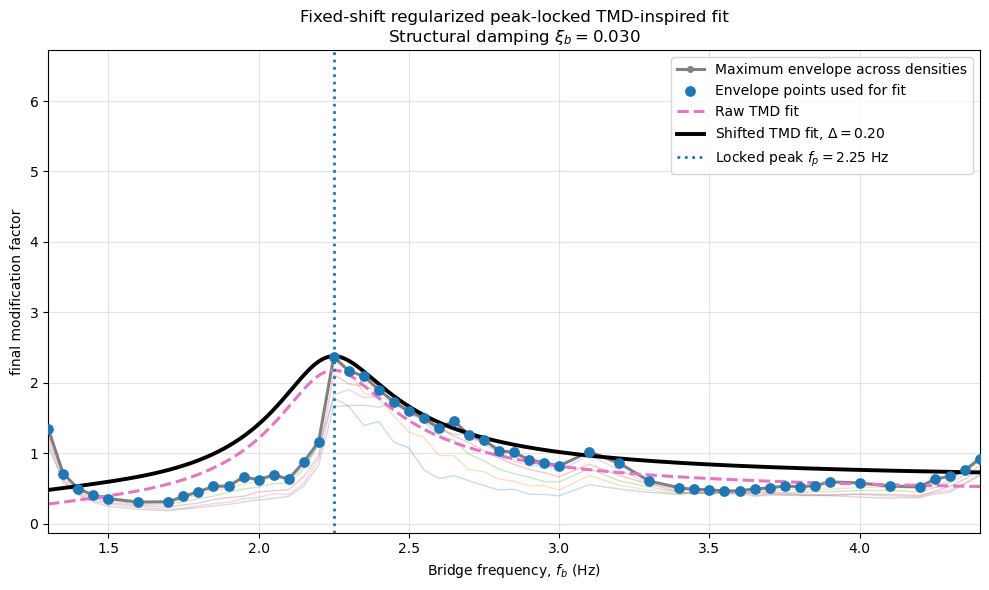


SUMMARY OF FIXED-SHIFT TMD FITTED PARAMETERS
 zeta_b   y0_ref    B_ref   mu_ref  alpha_ref  zeta_a_ref   y0_raw  tmd_design_shift       y0        B       mu    alpha   zeta_a   beta_p  Q_beta_p  A_equivalent  f_p  checked_peak_frequency  checked_peak_value  success     cost  n_fit_points  fit_fmin  fit_fmax  reg_strength
  0.005 0.127712 0.169014 0.178129   0.522219    0.390026 0.152599               0.2 0.352599 0.141651 0.179834 0.520308 0.369006 1.011669  9.094418      1.288231 2.25                2.251301            1.640817     True 1.283036            53       1.3       4.4          0.25
  0.010 0.149223 0.214828 0.166059   0.557339    0.372351 0.139348               0.2 0.339348 0.196406 0.174609 0.553614 0.335391 1.017270  8.215009      1.613475 2.25                2.251301            1.952809     True 1.228679            53       1.3       4.4          0.25
  0.015 0.170735 0.260642 0.153989   0.592458    0.354677 0.120198               0.2 0.320198 0.239668 0.166089 0.594125

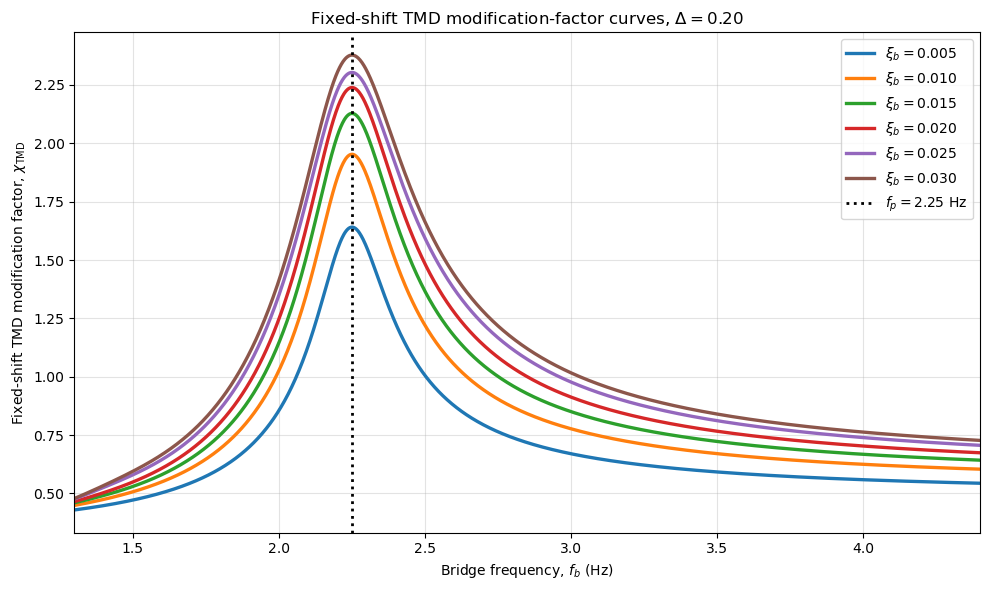

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

# ==================================================
# FIXED-SHIFT TMD ANALOGY FIT
# For all damping ratios
#
# Raw model:
#   chi(f_b) = y0 + B * Q(beta_eff)
#
# Shifted safe model:
#   chi_shifted(f_b) = chi(f_b) + TMD_DESIGN_SHIFT
#
# Equivalent to:
#   y0_shifted = y0 + TMD_DESIGN_SHIFT
# ==================================================


# ==================================================
# SETTINGS
# ==================================================

DAMPINGS_TO_FIT = None
# DAMPINGS_TO_FIT = [0.005, 0.010, 0.015, 0.020, 0.025, 0.030]

Y_COL = "final_modification_factor"

FIT_FMIN = 1.30
FIT_FMAX = 4.40

F_TARGET_PEAK = 2.25

MEASURE_TO_USE = None
# MEASURE_TO_USE = "Peak 1-sec RMS"

BETA_MIN = 0.20
BETA_MAX = 3.00
N_BETA_PEAK = 6000

SAVE_PLOTS = False
SAVE_PARAMS = True

REG_STRENGTH = 0.25

# ==================================================
# FIXED SAFETY SHIFT
# ==================================================
# Try:
#   0.00 = raw fitted TMD
#   0.02 = small shift
#   0.05 = moderate shift
#   0.10 = stronger shift

TMD_DESIGN_SHIFT = 0.2

PLOT_RAW_AND_SHIFTED = True


# ==================================================
# SMOOTH PARAMETER EQUATIONS
# ==================================================

def parameter_reference_from_equations(xi_b):
    """
    Smooth reference parameters from your fitted-line plots.
    """

    y0 = 4.3023 * xi_b + 0.1062
    B = 9.1628 * xi_b + 0.1232
    mu = -2.4141 * xi_b + 0.1902
    alpha = 7.0239 * xi_b + 0.4871
    zeta_a = -3.5349 * xi_b + 0.4077

    return {
        "y0": y0,
        "B": B,
        "mu": mu,
        "alpha": alpha,
        "zeta_a": zeta_a,
        "f_p": 2.25,
        "beta_p": 1.0,
    }


# ==================================================
# CLOSED-FORM MMD / TMD ACCELERATION SHAPE Q(beta)
# ==================================================

def Q_mmd(beta, mu, alpha, zeta_b, zeta_a):

    beta = np.asarray(beta, dtype=float)

    N_R = alpha**2 - beta**2
    N_I = 2.0 * zeta_a * alpha * beta

    D_R = (
        (1.0 - beta**2) * (alpha**2 - beta**2)
        - 4.0 * zeta_b * zeta_a * alpha * beta**2
        - mu * alpha**2 * beta**2
    )

    D_I = (
        2.0 * beta
        * (
            zeta_a * alpha * (1.0 - (1.0 + mu) * beta**2)
            + zeta_b * (alpha**2 - beta**2)
        )
    )

    numerator_abs = np.sqrt(N_R**2 + N_I**2)
    denominator_abs = np.sqrt(D_R**2 + D_I**2)

    return beta**2 * numerator_abs / (denominator_abs + 1e-14)


def beta_peak_for_parameters(mu, alpha, zeta_a, zeta_b):

    beta_grid = np.linspace(BETA_MIN, BETA_MAX, N_BETA_PEAK)

    Q_grid = Q_mmd(
        beta=beta_grid,
        mu=mu,
        alpha=alpha,
        zeta_b=zeta_b,
        zeta_a=zeta_a
    )

    return beta_grid[np.nanargmax(Q_grid)]


def chi_peak_locked_B_model(f_bridge, y0, B, mu, alpha, zeta_a, zeta_b):
    """
    Peak-locked TMD analogy model:

        chi(f_b) = y0 + B * Q(beta_eff)

    where:

        beta_eff = beta_p * f_b / F_TARGET_PEAK

    beta_p is calculated from the current shape parameters.
    """

    beta_p = beta_peak_for_parameters(
        mu=mu,
        alpha=alpha,
        zeta_a=zeta_a,
        zeta_b=zeta_b
    )

    beta_eff = beta_p * (f_bridge / F_TARGET_PEAK)

    Q_eff = Q_mmd(
        beta=beta_eff,
        mu=mu,
        alpha=alpha,
        zeta_b=zeta_b,
        zeta_a=zeta_a
    )

    return y0 + B * Q_eff


# ==================================================
# PREPARE ALL DATA
# ==================================================

df_all = corrected_df.copy()

required_cols = [
    "bridge_frequency",
    "target_beamdamp",
    "target_density",
    Y_COL,
]

missing_cols = [c for c in required_cols if c not in df_all.columns]

if missing_cols:
    raise KeyError(f"Missing required columns in corrected_df: {missing_cols}")

df_all["bridge_frequency"] = pd.to_numeric(df_all["bridge_frequency"], errors="coerce")
df_all["target_beamdamp"] = pd.to_numeric(df_all["target_beamdamp"], errors="coerce")
df_all["target_density"] = pd.to_numeric(df_all["target_density"], errors="coerce")
df_all[Y_COL] = pd.to_numeric(df_all[Y_COL], errors="coerce")

df_all = df_all.dropna(
    subset=[
        "bridge_frequency",
        "target_beamdamp",
        "target_density",
        Y_COL,
    ]
).copy()

df_all["damping_key"] = df_all["target_beamdamp"].round(3)
df_all["freq_key"] = df_all["bridge_frequency"].round(6)
df_all["density_key"] = df_all["target_density"].round(4)

if MEASURE_TO_USE is not None:

    if "measure" not in df_all.columns:
        raise KeyError("MEASURE_TO_USE is set, but corrected_df has no 'measure' column.")

    df_all = df_all[
        df_all["measure"].astype(str).str.strip() == MEASURE_TO_USE
    ].copy()

if DAMPINGS_TO_FIT is None:
    DAMPINGS_TO_FIT = sorted(df_all["damping_key"].dropna().unique())
else:
    DAMPINGS_TO_FIT = [round(float(x), 3) for x in DAMPINGS_TO_FIT]

print("\nDamping ratios to fit:")
print(DAMPINGS_TO_FIT)

print("\nFixed TMD design shift:")
print(f"TMD_DESIGN_SHIFT = {TMD_DESIGN_SHIFT:.4f}")

print("\nAvailable data coverage:")
print(
    df_all.groupby(["damping_key", "density_key"])["bridge_frequency"]
    .agg(["min", "max", "count"])
    .reset_index()
    .to_string(index=False)
)


# ==================================================
# FIT FUNCTION FOR ONE DAMPING RATIO
# ==================================================

def fit_one_damping(damping_to_fit):

    zeta_b = float(damping_to_fit)
    damp_key = round(zeta_b, 3)

    df = df_all[np.isclose(df_all["damping_key"], damp_key)].copy()

    if df.empty:
        print(f"\nSkipping damping = {zeta_b:.3f}: no data found.")
        return None

    # Remove repeated rows.
    df_unique = df.drop_duplicates(
        subset=["freq_key", "density_key"],
        keep="first"
    ).copy()

    # ==================================================
    # MAXIMUM ENVELOPE ACROSS DENSITIES
    # ==================================================

    env_df = (
        df_unique
        .groupby("freq_key", as_index=False)
        .agg(
            bridge_frequency=("bridge_frequency", "mean"),
            y_env=(Y_COL, "max")
        )
        .sort_values("bridge_frequency")
    )

    fit_df = env_df[
        (env_df["bridge_frequency"] >= FIT_FMIN)
        & (env_df["bridge_frequency"] <= FIT_FMAX)
    ].copy()

    x_fit = fit_df["bridge_frequency"].to_numpy()
    y_fit = fit_df["y_env"].to_numpy()

    if len(x_fit) < 8:
        print(f"\nSkipping damping = {zeta_b:.3f}: too few fitting points.")
        return None

    print("\n" + "=" * 80)
    print(f"Fitting damping = {zeta_b:.3f}")
    print("=" * 80)
    print("Number of fitting points:", len(x_fit))
    print("Fitting frequency range:", x_fit.min(), "to", x_fit.max())

    # ==================================================
    # REFERENCE PARAMETERS
    # ==================================================

    p_ref = parameter_reference_from_equations(zeta_b)

    y0_ref = p_ref["y0"]
    B_ref = p_ref["B"]
    mu_ref = p_ref["mu"]
    alpha_ref = p_ref["alpha"]
    zeta_a_ref = p_ref["zeta_a"]

    print("\nReference parameters")
    print("--------------------")
    print(f"y0_ref      = {y0_ref:.8f}")
    print(f"B_ref       = {B_ref:.8e}")
    print(f"mu_ref      = {mu_ref:.8f}")
    print(f"alpha_ref   = {alpha_ref:.8f}")
    print(f"zeta_a_ref  = {zeta_a_ref:.8f}")

    # ==================================================
    # INITIAL GUESS
    # ==================================================

    beta_p_ref = beta_peak_for_parameters(
        mu=mu_ref,
        alpha=alpha_ref,
        zeta_a=zeta_a_ref,
        zeta_b=zeta_b
    )

    beta_eff_ref = beta_p_ref * (x_fit / F_TARGET_PEAK)

    Q_ref = Q_mmd(
        beta=beta_eff_ref,
        mu=mu_ref,
        alpha=alpha_ref,
        zeta_b=zeta_b,
        zeta_a=zeta_a_ref
    )

    X_ref = np.column_stack([np.ones_like(Q_ref), Q_ref])
    y0_guess, B_guess = np.linalg.lstsq(X_ref, y_fit, rcond=None)[0]

    y0_guess = max(y0_guess, 1e-8)
    B_guess = max(B_guess, 1e-8)

    p0 = np.array([
        y0_guess,
        B_guess,
        mu_ref,
        alpha_ref,
        zeta_a_ref
    ])

    print("\nInitial guesses")
    print("----------------")
    print(f"y0       = {p0[0]:.8f}")
    print(f"B        = {p0[1]:.8e}")
    print(f"mu       = {p0[2]:.8f}")
    print(f"alpha    = {p0[3]:.8f}")
    print(f"zeta_a   = {p0[4]:.8f}")
    print(f"beta_p0  = {beta_p_ref:.8f}")

    # ==================================================
    # BOUNDS
    # ==================================================

    ymax = np.nanmax(y_fit)

    lower_bounds = np.array([
        0.00,
        0.00,
        max(0.02, mu_ref - 0.035),
        max(0.50, alpha_ref - 0.08),
        max(0.25, zeta_a_ref - 0.06),
    ])

    upper_bounds = np.array([
        5.0 * ymax,
        1e6,
        min(0.25, mu_ref + 0.035),
        min(0.90, alpha_ref + 0.08),
        min(0.50, zeta_a_ref + 0.06),
    ])

    small = 1e-10
    p0 = np.maximum(p0, lower_bounds + small)
    p0 = np.minimum(p0, upper_bounds - small)

    print("\nBounds used")
    print("------------")
    print("lower =", lower_bounds)
    print("upper =", upper_bounds)

    # ==================================================
    # RESIDUAL FUNCTION
    # ==================================================

    eps = 1e-12

    RIGHT_SHOULDER_WEIGHT = 1.25
    POST_PEAK_SHOULDER_WEIGHT = 1.10
    PEAK_WEIGHT_STRENGTH = 0.05

    def residuals(p):

        y0, B, mu, alpha, zeta_a = p

        y_model = chi_peak_locked_B_model(
            f_bridge=x_fit,
            y0=y0,
            B=B,
            mu=mu,
            alpha=alpha,
            zeta_a=zeta_a,
            zeta_b=zeta_b
        )

        if np.any(y_model <= 0):
            return 1e6 * np.ones_like(y_fit)

        # log-space residual
        res_data = np.log(y_model + eps) - np.log(y_fit + eps)

        peak_weight = 1.0 + PEAK_WEIGHT_STRENGTH * np.exp(
            -0.5 * ((x_fit - F_TARGET_PEAK) / 0.25)**2
        )

        right_weight = np.where(
            x_fit > F_TARGET_PEAK,
            RIGHT_SHOULDER_WEIGHT,
            1.0
        )

        post_peak_weight = np.where(
            (x_fit >= 2.35) & (x_fit <= 3.00),
            POST_PEAK_SHOULDER_WEIGHT,
            1.0
        )

        res_data = peak_weight * right_weight * post_peak_weight * res_data

        # regularization
        res_reg = REG_STRENGTH * np.array([
            (mu - mu_ref) / 0.035,
            (alpha - alpha_ref) / 0.08,
            (zeta_a - zeta_a_ref) / 0.06,
        ])

        return np.concatenate([res_data, res_reg])

    # ==================================================
    # OPTIMIZATION
    # ==================================================

    result = least_squares(
        residuals,
        p0,
        bounds=(lower_bounds, upper_bounds),
        loss="soft_l1",
        f_scale=0.1,
        max_nfev=50000
    )

    y0_raw, B_fit, mu_fit, alpha_fit, zeta_a_fit = result.x

    # ==================================================
    # FIXED UPWARD SHIFT
    # ==================================================

    y0_shifted = y0_raw + TMD_DESIGN_SHIFT

    print("\nFixed upward safety shift")
    print("-------------------------")
    print(f"TMD_DESIGN_SHIFT = {TMD_DESIGN_SHIFT:.8f}")
    print(f"y0 raw           = {y0_raw:.8f}")
    print(f"y0 shifted       = {y0_shifted:.8f}")

    # ==================================================
    # PEAK AND SMOOTH CURVES
    # ==================================================

    beta_p_fit = beta_peak_for_parameters(
        mu=mu_fit,
        alpha=alpha_fit,
        zeta_a=zeta_a_fit,
        zeta_b=zeta_b
    )

    Q_beta_p_fit = Q_mmd(
        beta=beta_p_fit,
        mu=mu_fit,
        alpha=alpha_fit,
        zeta_b=zeta_b,
        zeta_a=zeta_a_fit
    )

    A_equivalent = B_fit * Q_beta_p_fit

    x_smooth = np.linspace(FIT_FMIN, FIT_FMAX, 1500)

    y_smooth_raw = chi_peak_locked_B_model(
        f_bridge=x_smooth,
        y0=y0_raw,
        B=B_fit,
        mu=mu_fit,
        alpha=alpha_fit,
        zeta_a=zeta_a_fit,
        zeta_b=zeta_b
    )

    y_smooth_shifted = chi_peak_locked_B_model(
        f_bridge=x_smooth,
        y0=y0_shifted,
        B=B_fit,
        mu=mu_fit,
        alpha=alpha_fit,
        zeta_a=zeta_a_fit,
        zeta_b=zeta_b
    )

    peak_idx = np.nanargmax(y_smooth_shifted)

    print("\nFitted parameters")
    print("-----------------")
    print(f"y0 raw              = {y0_raw:.8f}")
    print(f"y0 shifted          = {y0_shifted:.8f}")
    print(f"B                   = {B_fit:.8e}")
    print(f"mu                  = {mu_fit:.8f}")
    print(f"alpha               = {alpha_fit:.8f}")
    print(f"zeta_b              = {zeta_b:.8f} fixed")
    print(f"zeta_a              = {zeta_a_fit:.8f}")
    print(f"beta_p              = {beta_p_fit:.8f}")
    print(f"Q(beta_p)           = {Q_beta_p_fit:.8f}")
    print(f"A equivalent        = {A_equivalent:.8f}")
    print(f"Shifted peak freq   = {x_smooth[peak_idx]:.6f} Hz")
    print(f"Shifted peak value  = {y_smooth_shifted[peak_idx]:.6f}")
    print("Success:", result.success)
    print("Message:", result.message)
    print("Cost:", result.cost)

    # ==================================================
    # PLOT INDIVIDUAL DAMPING FIT
    # ==================================================

    plt.figure(figsize=(10, 6))

    for density in sorted(df_unique["density_key"].unique()):

        sub = df_unique[
            np.isclose(df_unique["density_key"], density)
        ].sort_values("bridge_frequency")

        plt.plot(
            sub["bridge_frequency"],
            sub[Y_COL],
            linewidth=1.0,
            alpha=0.25
        )

    plt.plot(
        env_df["bridge_frequency"],
        env_df["y_env"],
        "o-",
        linewidth=2.2,
        markersize=4,
        color="gray",
        label="Maximum envelope across densities"
    )

    plt.scatter(
        x_fit,
        y_fit,
        s=45,
        zorder=5,
        label="Envelope points used for fit"
    )

    if PLOT_RAW_AND_SHIFTED:
        plt.plot(
            x_smooth,
            y_smooth_raw,
            linestyle="--",
            linewidth=2.2,
            label="Raw TMD fit"
        )

    plt.plot(
        x_smooth,
        y_smooth_shifted,
        "k-",
        linewidth=2.8,
        label=rf"Shifted TMD fit, $\Delta={TMD_DESIGN_SHIFT:.2f}$"
    )

    plt.axvline(
        F_TARGET_PEAK,
        linestyle=":",
        linewidth=2.0,
        label=rf"Locked peak $f_p={F_TARGET_PEAK:.2f}$ Hz"
    )

    plt.xlabel(r"Bridge frequency, $f_b$ (Hz)")
    plt.xlim(FIT_FMIN, FIT_FMAX)
    plt.ylabel(Y_COL.replace("_", " "))
    plt.title(
        "Fixed-shift regularized peak-locked TMD-inspired fit\n"
        rf"Structural damping $\xi_b={zeta_b:.3f}$"
    )

    plt.grid(True, alpha=0.35)
    plt.legend()
    plt.tight_layout()

    if SAVE_PLOTS:
        outname = (
            f"fixed_shift_tmd_fit_damping{zeta_b:.3f}_"
            f"shift{TMD_DESIGN_SHIFT:.3f}.png"
        )
        plt.savefig(outname, dpi=300, bbox_inches="tight")
        print("Saved:", outname)

    plt.show()

    return {
        "zeta_b": zeta_b,

        "y0_ref": y0_ref,
        "B_ref": B_ref,
        "mu_ref": mu_ref,
        "alpha_ref": alpha_ref,
        "zeta_a_ref": zeta_a_ref,

        "y0_raw": y0_raw,
        "tmd_design_shift": TMD_DESIGN_SHIFT,

        # Main y0 is the shifted one, so later equation code uses shifted curve
        "y0": y0_shifted,

        "B": B_fit,
        "mu": mu_fit,
        "alpha": alpha_fit,
        "zeta_a": zeta_a_fit,
        "beta_p": beta_p_fit,
        "Q_beta_p": Q_beta_p_fit,
        "A_equivalent": A_equivalent,
        "f_p": F_TARGET_PEAK,

        "checked_peak_frequency": x_smooth[peak_idx],
        "checked_peak_value": y_smooth_shifted[peak_idx],
        "success": result.success,
        "cost": result.cost,
        "n_fit_points": len(x_fit),
        "fit_fmin": x_fit.min(),
        "fit_fmax": x_fit.max(),
        "reg_strength": REG_STRENGTH,
    }


# ==================================================
# LOOP OVER ALL DAMPING RATIOS
# ==================================================

fit_rows = []

for damp in DAMPINGS_TO_FIT:

    row = fit_one_damping(damp)

    if row is not None:
        fit_rows.append(row)

fit_summary_df = pd.DataFrame(fit_rows)

print("\n" + "=" * 80)
print("SUMMARY OF FIXED-SHIFT TMD FITTED PARAMETERS")
print("=" * 80)

if fit_summary_df.empty:

    print("No successful fits.")

else:

    print(fit_summary_df.to_string(index=False))

    if SAVE_PARAMS:
        fit_summary_df.to_csv(
            f"fixed_shift_tmd_fit_parameters_shift{TMD_DESIGN_SHIFT:.3f}.csv",
            index=False
        )
        print(
            "\nSaved:",
            f"fixed_shift_tmd_fit_parameters_shift{TMD_DESIGN_SHIFT:.3f}.csv"
        )


# ==================================================
# COMBINED PLOT FOR ALL DAMPING RATIOS
# ==================================================

if not fit_summary_df.empty:

    x_smooth = np.linspace(FIT_FMIN, FIT_FMAX, 1500)

    plt.figure(figsize=(10, 6))

    for _, row in fit_summary_df.iterrows():

        zeta_b = float(row["zeta_b"])

        y_curve = chi_peak_locked_B_model(
            f_bridge=x_smooth,
            y0=float(row["y0"]),
            B=float(row["B"]),
            mu=float(row["mu"]),
            alpha=float(row["alpha"]),
            zeta_a=float(row["zeta_a"]),
            zeta_b=zeta_b,
        )

        plt.plot(
            x_smooth,
            y_curve,
            linewidth=2.4,
            label=rf"$\xi_b={zeta_b:.3f}$"
        )

    plt.axvline(
        F_TARGET_PEAK,
        linestyle=":",
        linewidth=2.0,
        color="black",
        label=rf"$f_p={F_TARGET_PEAK:.2f}$ Hz"
    )

    plt.xlabel(r"Bridge frequency, $f_b$ (Hz)")
    plt.ylabel(r"Fixed-shift TMD modification factor, $\chi_{\mathrm{TMD}}$")
    plt.title(
        rf"Fixed-shift TMD modification-factor curves, $\Delta={TMD_DESIGN_SHIFT:.2f}$"
    )

    plt.xlim(FIT_FMIN, FIT_FMAX)
    plt.grid(True, alpha=0.35)
    plt.legend()
    plt.tight_layout()

    if SAVE_PLOTS:
        outname = f"combined_fixed_shift_tmd_curves_shift{TMD_DESIGN_SHIFT:.3f}.png"
        plt.savefig(outname, dpi=300, bbox_inches="tight")
        print("Saved:", outname)

    plt.show()

Loaded NEW fixed-shift fitted parameters from: fixed_shift_tmd_fit_parameters_shift0.200.csv

New fitted parameter table:
 xi_b       y0        B       mu    alpha   zeta_a   beta_p  f_p  xi_b_scaled
0.005 0.352599 0.141651 0.179834 0.520308 0.369006 1.011669 2.25          0.5
0.010 0.339348 0.196406 0.174609 0.553614 0.335391 1.017270 2.25          1.0
0.015 0.320198 0.239668 0.166089 0.594125 0.296909 1.024737 2.25          1.5
0.020 0.300419 0.278166 0.154560 0.616796 0.296948 1.025671 2.25          2.0
0.025 0.271817 0.324311 0.148132 0.664078 0.265490 1.035473 2.25          2.5
0.030 0.261058 0.348272 0.134084 0.677453 0.264632 1.034539 2.25          3.0

Linear equations using real xi_b
$y_o$ = -3.88615871 xi_b + 0.37558094
$B$ = 8.31610193 xi_b + 0.10921371
$\mu$ = -1.82692650 xi_b + 0.19152251
$\alpha$ = 6.51309317 xi_b + 0.49041628
$\zeta_a$ = -4.18017883 xi_b + 0.37788228
$\beta_p$ = 0.97082847 xi_b + 1.00790354
$f_p$ = -0.00000000 xi_b + 2.25000000

Equation table:
parameter

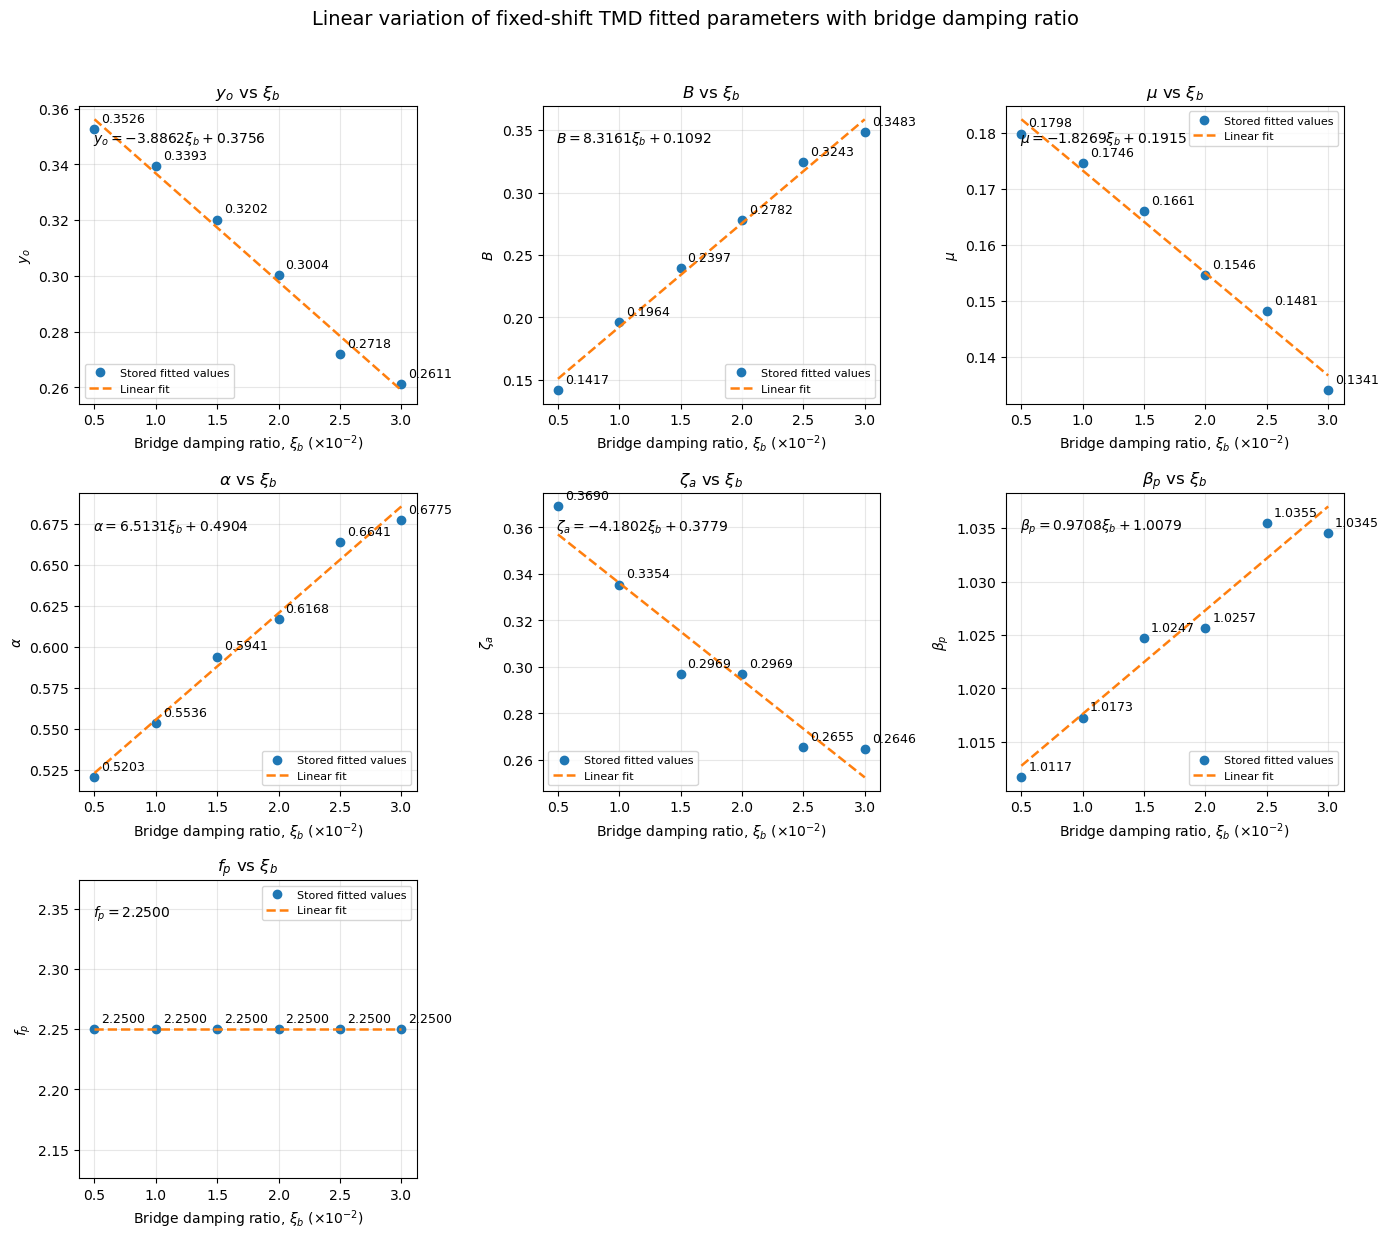

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import glob

# ==================================================
# LOAD / USE NEW FIXED-SHIFT FITTED PARAMETERS
# ==================================================

# Prefer the new fixed-shift file from the previous code
fixed_shift_files = sorted(
    glob.glob("fixed_shift_tmd_fit_parameters_shift*.csv")
)

regular_csv_file = Path("regularized_peak_locked_fit_parameters_all_dampings.csv")

# Priority:
# 1. fixed_shift_tmd_fit_parameters_shift*.csv
# 2. fit_summary_df in memory
# 3. old regularized_peak_locked_fit_parameters_all_dampings.csv

if len(fixed_shift_files) > 0:
    csv_file = Path(fixed_shift_files[-1])
    df_params = pd.read_csv(csv_file)
    print(f"Loaded NEW fixed-shift fitted parameters from: {csv_file}")

elif "fit_summary_df" in globals():
    df_params = fit_summary_df.copy()
    print("Using fit_summary_df from notebook memory.")

elif regular_csv_file.exists():
    df_params = pd.read_csv(regular_csv_file)
    print(f"Loaded OLD fitted parameters from: {regular_csv_file}")

else:
    raise FileNotFoundError(
        "Could not find fixed-shift parameter CSV, fit_summary_df, "
        "or regularized_peak_locked_fit_parameters_all_dampings.csv."
    )


# ==================================================
# CLEAN COLUMN NAMES
# ==================================================

# Rename damping column to xi_b
if "zeta_b" in df_params.columns:
    df_params = df_params.rename(columns={"zeta_b": "xi_b"})

if "damping" in df_params.columns and "xi_b" not in df_params.columns:
    df_params = df_params.rename(columns={"damping": "xi_b"})

if "xi_b" not in df_params.columns:
    raise KeyError("Could not find damping column: expected xi_b, zeta_b, or damping.")




# ==================================================
# REQUIRED COLUMNS
# ==================================================

required_cols = [
    "xi_b",
    "y0",
    "B",
    "mu",
    "alpha",
    "zeta_a",
    "beta_p",
    "f_p",
]

missing_cols = [c for c in required_cols if c not in df_params.columns]

if missing_cols:
    raise KeyError(f"Missing required columns: {missing_cols}")

df_params = df_params[required_cols].copy()

# Convert to numeric
for col in required_cols:
    df_params[col] = pd.to_numeric(df_params[col], errors="coerce")

df_params = df_params.dropna(subset=required_cols).copy()
df_params = df_params.sort_values("xi_b").reset_index(drop=True)

# Scaled x-axis only for plotting
df_params["xi_b_scaled"] = df_params["xi_b"] * 1e2

print("\nNew fitted parameter table:")
print(df_params.to_string(index=False))


# ==================================================
# LABELS
# ==================================================
symbol_labels = {
    "y0": r"$y_o$",
    "B": r"$B$",
    "mu": r"$\mu$",
    "alpha": r"$\alpha$",
    "zeta_a": r"$\zeta_a$",
    "beta_p": r"$\beta_p$",
    "f_p": r"$f_p$",
    "xi_b": r"$\xi_b$",
}

symbol_raw = {
    "y0": r"y_o",
    "B": r"B",
    "mu": r"\mu",
    "alpha": r"\alpha",
    "zeta_a": r"\zeta_a",
    "beta_p": r"\beta_p",
    "f_p": r"f_p",
    "xi_b": r"\xi_b",
}
params_to_plot = [
    "y0",
    "B",
    "mu",
    "alpha",
    "zeta_a",
    "beta_p",
    "f_p",
]

# ==================================================
# LINEAR FITS: parameter = m * xi_b + c
# ==================================================

linear_equations = {}

print("\nLinear equations using real xi_b")
print("================================")

equation_rows = []

for param in params_to_plot:

    x_real = df_params["xi_b"].to_numpy()
    y = df_params[param].to_numpy()

    if len(np.unique(x_real)) < 2:
        raise ValueError("Need at least two different xi_b values for linear fitting.")

    m, c = np.polyfit(x_real, y, 1)

    linear_equations[param] = {
        "slope": m,
        "intercept": c,
    }

    equation_rows.append({
        "parameter": param,
        "slope_m": m,
        "intercept_c": c,
        "equation": f"{param} = {m:.8f} * xi_b + {c:.8f}",
    })

    print(f"{symbol_labels[param]} = {m:.8f} xi_b + {c:.8f}")

df_equations = pd.DataFrame(equation_rows)

print("\nEquation table:")
print(df_equations.to_string(index=False))

df_equations.to_csv(
    "linear_equations_from_fixed_shift_tmd_fit.csv",
    index=False
)

print("\nSaved: linear_equations_from_fixed_shift_tmd_fit.csv")


# ==================================================
# ALSO SAVE DESIGN EQUATIONS IN OLD-COMPATIBLE FORM
# ==================================================
# This is useful for your later comparison code.
# It expects parameter names:
#   y0, B, mu, alpha, zeta_a, beta_p, f_p
#
# Here y0 is the shifted design y0.
# ==================================================

compat_rows = []

for param in ["y0", "B", "mu", "alpha", "zeta_a", "beta_p", "f_p"]:

    m = linear_equations[param]["slope"]
    c = linear_equations[param]["intercept"]

    compat_name = "y0" if param == "y0" else param

    compat_rows.append({
        "parameter": compat_name,
        "slope_m": m,
        "intercept_c": c,
        "equation": f"{compat_name} = {m:.8f} * xi_b + {c:.8f}",
    })

df_equations_compat = pd.DataFrame(compat_rows)

df_equations_compat.to_csv(
    "linear_equations_from_fixed_shift_tmd_fit_COMPATIBLE.csv",
    index=False
)

print("\nSaved: linear_equations_from_fixed_shift_tmd_fit_COMPATIBLE.csv")
print("\nCompatible equation table:")
print(df_equations_compat.to_string(index=False))


# ==================================================
# PLOT DATA + LINEAR FIT
# ==================================================

n = len(params_to_plot)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(14, 4.2 * nrows)
)

axes = np.asarray(axes).reshape(-1)

# Real xi_b for fitting
xi_fit = np.linspace(
    df_params["xi_b"].min(),
    df_params["xi_b"].max(),
    200
)

# Scaled only for plotting
xi_fit_scaled = xi_fit * 1e2

for ax, param in zip(axes, params_to_plot):

    xi_scaled = df_params["xi_b_scaled"].to_numpy()
    y = df_params[param].to_numpy()

    m = linear_equations[param]["slope"]
    c = linear_equations[param]["intercept"]

    y_fit = m * xi_fit + c

    # Stored fitted points
    ax.plot(
        xi_scaled,
        y,
        marker="o",
        linestyle="",
        markersize=6,
        label="Stored fitted values"
    )

    # Linear fit line
    ax.plot(
        xi_fit_scaled,
        y_fit,
        linestyle="--",
        linewidth=1.8,
        label="Linear fit"
    )

    # Annotate values
    for x_plot, yi in zip(xi_scaled, y):
        ax.annotate(
            f"{yi:.4f}",
            (x_plot, yi),
            textcoords="offset points",
            xytext=(5, 5),
            fontsize=9
        )

    # Equation text
    if abs(m) < 1e-12:
        equation_text = rf"${symbol_raw[param]} = {c:.4f}$"
    else:
        sign = "+" if c >= 0 else "-"
        equation_text = rf"${symbol_raw[param]} = {m:.4f}\xi_b {sign} {abs(c):.4f}$"

    ax.text(
        0.04,
        0.92,
        equation_text,
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment="top"
    )

    ax.set_title(f"{symbol_labels[param]} vs {symbol_labels['xi_b']}")
    ax.set_xlabel(r"Bridge damping ratio, $\xi_b$ $(\times 10^{-2})$")
    ax.set_ylabel(symbol_labels[param])

    ax.set_xticks(df_params["xi_b_scaled"])
    ax.set_xticklabels([f"{val:.1f}" for val in df_params["xi_b_scaled"]])

    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

# Remove unused axes
for j in range(len(params_to_plot), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(
    "Linear variation of fixed-shift TMD fitted parameters with bridge damping ratio",
    fontsize=14
)

fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

Loaded shifted TMD linear equations from:
linear_equations_from_fixed_shift_tmd_fit.csv

Shifted TMD equations being used
y0 = -3.88615871 * xi_b + 0.37558094
B = 8.31610193 * xi_b + 0.10921371
mu = -1.82692650 * xi_b + 0.19152251
alpha = 6.51309317 * xi_b + 0.49041628
zeta_a = -4.18017883 * xi_b + 0.37788228
beta_p = 0.97082847 * xi_b + 1.00790354
f_p = -0.00000000 * xi_b + 2.25000000

Using existing chi_piecewise_equation_model from notebook memory.

Available mass ratios after filtering:
[np.float64(0.01), np.float64(0.05), np.float64(0.1), np.float64(0.15), np.float64(0.2), np.float64(0.25)]

Available damping ratios after filtering:
[np.float64(0.005), np.float64(0.01), np.float64(0.015), np.float64(0.02), np.float64(0.025), np.float64(0.03)]

Using existing p95_cubic_equation_df from notebook memory.

P95 valid mass-ratio range:
mu_min = 0.010
mu_max = 0.250

Bias comparison calculated

Check first rows:
 mass_ratio  target_beamdamp  bridge_frequency                   measure  ch

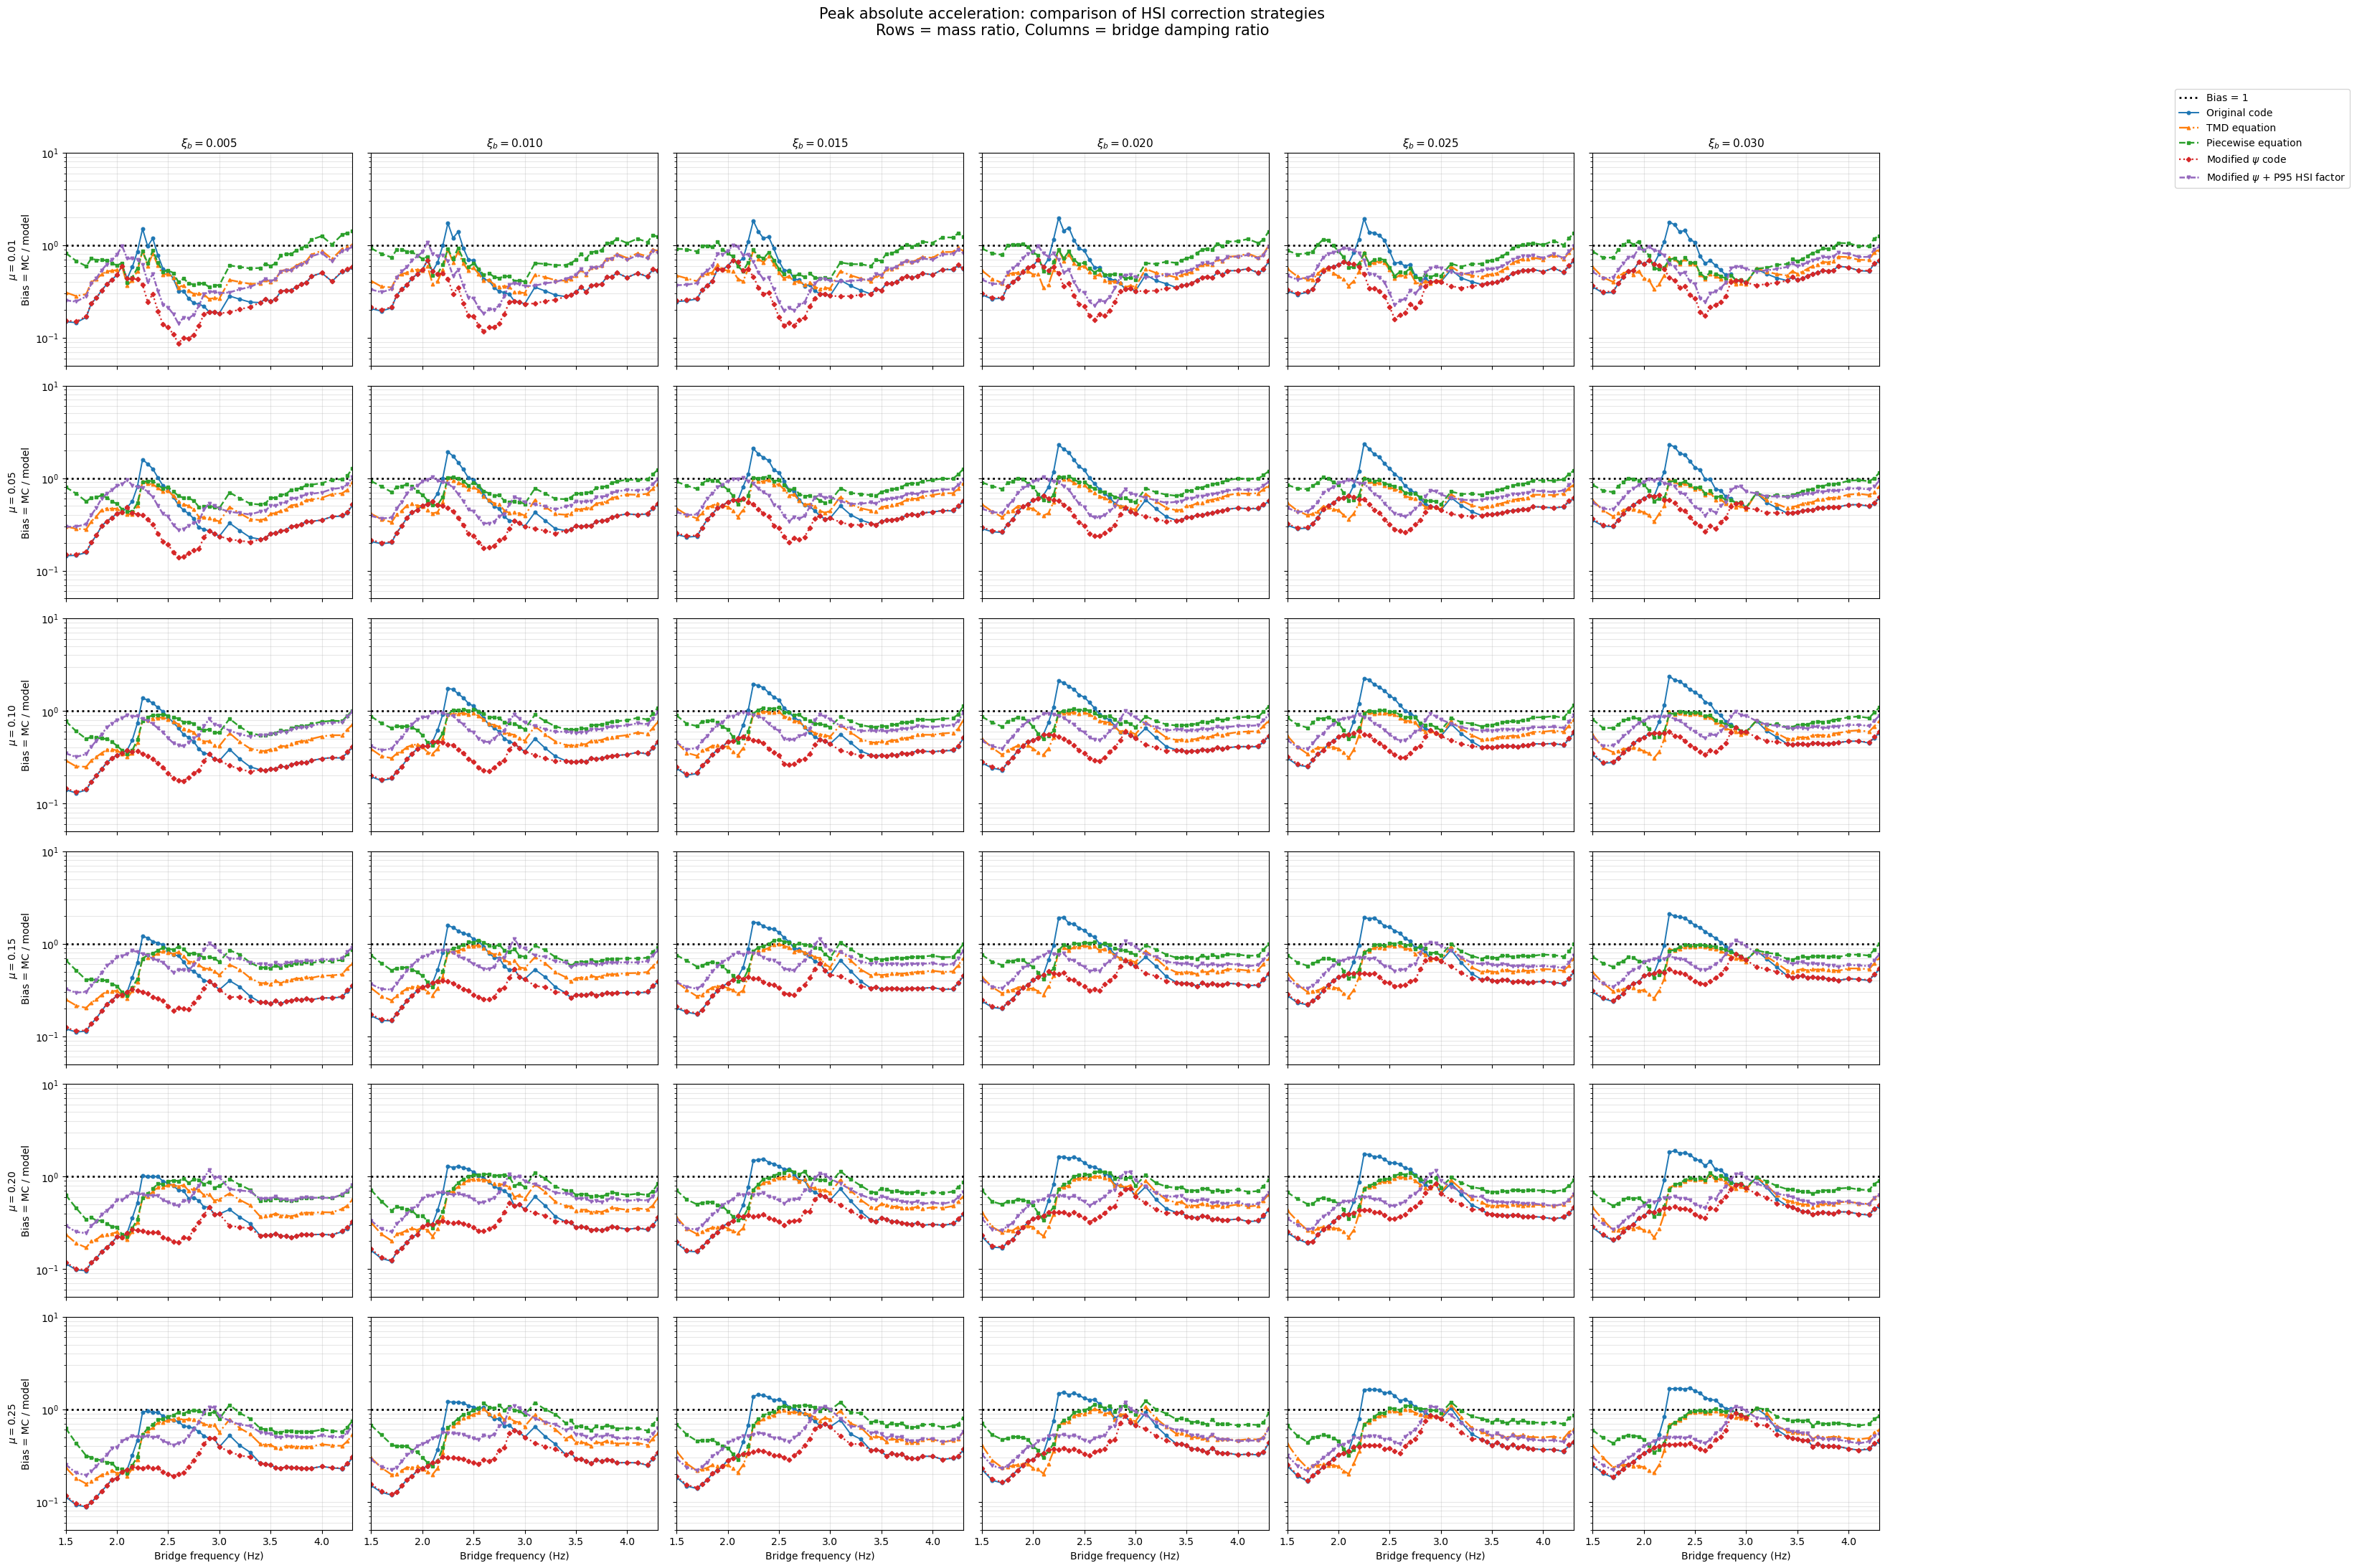


Summary of bias comparison


,measure,mass_ratio,damping,method,n,mean_bias,median_bias,min_bias,max_bias,p05_bias,p95_bias,underprediction_rate_percent,underprediction_gt_1p05_percent,overprediction_rate_percent,very_conservative_lt_0p5_percent,mean_abs_log_bias
0,Peak absolute acceleration,0.01,0.005,Modified psi + P95 HSI factor,48,0.480083,0.432574,0.143209,0.984637,0.169684,0.893444,0.000000,0.000000,100.000000,56.250000,0.860640
1,Peak absolute acceleration,0.01,0.005,Modified psi code,48,0.292143,0.263233,0.087147,0.599178,0.103257,0.543684,0.000000,0.000000,100.000000,89.583333,1.357355
2,Peak absolute acceleration,0.01,0.005,Shifted TMD equation,48,0.509075,0.465991,0.262696,1.014498,0.274336,0.902193,2.083333,0.000000,97.916667,56.250000,0.744298
3,Peak absolute acceleration,0.01,0.005,Original code,48,0.418582,0.327243,0.145988,1.507806,0.172886,0.936190,4.166667,4.166667,95.833333,72.916667,1.042247
4,Peak absolute acceleration,0.01,0.005,Piecewise equation,48,0.690763,0.637758,0.353794,1.435364,0.371945,1.288645,12.500000,10.416667,87.500000,22.916667,0.494683
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,Peak absolute acceleration,0.25,0.030,Modified psi code,48,0.440851,0.408925,0.186691,0.906432,0.216793,0.826807,0.000000,0.000000,100.000000,79.166667,0.879909
176,Peak absolute acceleration,0.25,0.030,Shifted TMD equation,48,0.585962,0.559101,0.205911,1.037356,0.236489,0.942656,2.083333,0.000000,97.916667,37.500000,0.644493
177,Peak absolute acceleration,0.25,0.030,Modified psi + P95 HSI factor,48,0.523032,0.485154,0.221492,1.075403,0.257207,0.980935,4.166667,2.083333,95.833333,62.500000,0.713005
178,Peak absolute acceleration,0.25,0.030,Piecewise equation,48,0.728949,0.737983,0.343950,1.031602,0.414776,0.994282,6.250000,0.000000,93.750000,16.666667,0.357662


In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import math

# ==================================================
# SETTINGS
# ==================================================

Y_COL_FACTOR = "final_modification_factor"

TARGET_DAMPINGS = [0.005, 0.010, 0.015, 0.020, 0.025, 0.030]

MEASURES_TO_PLOT = [
    "Peak absolute acceleration",
]

PLOT_FMIN = 1.50
PLOT_FMAX = 4.30

YMIN = 0.05
YMAX = 10.0

EPS = 1e-12
PSI_MIN = 0.02

SAVE_PLOTS = False

# If your P95 cubic fit excluded mu = 0.30, keep this False.
ALLOW_P95_EXTRAPOLATION = False
CAP_P95_AT_ONE = True

# If p95_cubic_equation_df is not already in memory, this code can rebuild it.
AUTO_BUILD_P95_CUBIC_IF_MISSING = True

P95_SAFETY_MARGIN = 0.00
EXCLUDE_MU_030_FOR_P95_FIT = True


# ==================================================
# MASS RATIO MAPPING
# ==================================================

density_to_mass_ratio = {
    0.0333: 0.01,
    0.1667: 0.05,
    0.3333: 0.10,
    0.5000: 0.15,
    0.6667: 0.20,
    0.8333: 0.25,
    # 1.0000: 0.30,   # add this if you want mu = 0.30
}

density_to_mass_ratio = {
    round(k, 4): v for k, v in density_to_mass_ratio.items()
}

TARGET_MASS_RATIOS = [
    0.01,
    0.05,
    0.10,
    0.15,
    0.20,
    0.25,
    # 0.30,
]


# ==================================================
# PART 1
# LOAD SHIFTED TMD LINEAR EQUATIONS
# ==================================================

TMD_SHIFTED_EQUATION_FILE = Path("linear_equations_from_fixed_shift_tmd_fit.csv")

if not TMD_SHIFTED_EQUATION_FILE.exists():
    raise FileNotFoundError(
        f"Could not find {TMD_SHIFTED_EQUATION_FILE}. "
        "Run the fixed-shift TMD parameter linearization code first."
    )

tmd_eq_df = pd.read_csv(TMD_SHIFTED_EQUATION_FILE)

print("Loaded shifted TMD linear equations from:")
print(TMD_SHIFTED_EQUATION_FILE)

required_eq_cols = ["parameter", "slope_m", "intercept_c"]
missing_eq_cols = [c for c in required_eq_cols if c not in tmd_eq_df.columns]

if missing_eq_cols:
    raise KeyError(f"Missing columns in shifted TMD equation file: {missing_eq_cols}")

tmd_eq_df["parameter"] = tmd_eq_df["parameter"].astype(str).str.strip()
tmd_eq_df["slope_m"] = pd.to_numeric(tmd_eq_df["slope_m"], errors="coerce")
tmd_eq_df["intercept_c"] = pd.to_numeric(tmd_eq_df["intercept_c"], errors="coerce")

tmd_eq_df = tmd_eq_df.dropna(
    subset=["parameter", "slope_m", "intercept_c"]
).copy()

required_tmd_params = ["y0", "B", "mu", "alpha", "zeta_a", "beta_p", "f_p"]

missing_tmd_params = [
    p for p in required_tmd_params
    if p not in tmd_eq_df["parameter"].values
]

if missing_tmd_params:
    raise KeyError(
        f"Missing TMD parameters in shifted equation file: {missing_tmd_params}. "
        "Make sure the fixed-shift linearization file stores shifted y0 as parameter='y0'."
    )

tmd_linear_equations = {}

for _, row in tmd_eq_df.iterrows():

    param = row["parameter"]

    if param in required_tmd_params:
        tmd_linear_equations[param] = {
            "slope": float(row["slope_m"]),
            "intercept": float(row["intercept_c"]),
        }

print("\nShifted TMD equations being used")
print("=" * 70)

for p in required_tmd_params:
    m = tmd_linear_equations[p]["slope"]
    c = tmd_linear_equations[p]["intercept"]
    print(f"{p} = {m:.8f} * xi_b + {c:.8f}")


# ==================================================
# PART 2
# TMD MODEL FUNCTIONS USING SHIFTED y0
# ==================================================

def tmd_parameters_from_shifted_equations(xi_b):

    xi_b = float(xi_b)

    p = {}

    for name in required_tmd_params:
        m = tmd_linear_equations[name]["slope"]
        c = tmd_linear_equations[name]["intercept"]
        p[name] = m * xi_b + c

    p["y0"] = max(p["y0"], EPS)
    p["B"] = max(p["B"], EPS)
    p["mu"] = max(p["mu"], EPS)
    p["alpha"] = max(p["alpha"], EPS)
    p["zeta_a"] = max(p["zeta_a"], EPS)
    p["beta_p"] = max(p["beta_p"], EPS)
    p["f_p"] = max(p["f_p"], EPS)

    return p


def Q_mmd(beta, mu, alpha, zeta_b, zeta_a):

    beta = np.asarray(beta, dtype=float)

    N_R = alpha**2 - beta**2
    N_I = 2.0 * zeta_a * alpha * beta

    D_R = (
        (1.0 - beta**2) * (alpha**2 - beta**2)
        - 4.0 * zeta_b * zeta_a * alpha * beta**2
        - mu * alpha**2 * beta**2
    )

    D_I = (
        2.0 * beta
        * (
            zeta_a * alpha * (1.0 - (1.0 + mu) * beta**2)
            + zeta_b * (alpha**2 - beta**2)
        )
    )

    numerator_abs = np.sqrt(N_R**2 + N_I**2)
    denominator_abs = np.sqrt(D_R**2 + D_I**2)

    return beta**2 * numerator_abs / (denominator_abs + 1e-14)


def chi_tmd_equation_model(f_bridge, xi_b):
    """
    Shifted-y0 TMD equation model.

    chi_TMD(f_b) = y0_shifted + B * Q(beta_eff)
    """

    f_bridge = np.asarray(f_bridge, dtype=float)

    p = tmd_parameters_from_shifted_equations(xi_b)

    beta_eff = p["beta_p"] * f_bridge / p["f_p"]

    Q_eff = Q_mmd(
        beta=beta_eff,
        mu=p["mu"],
        alpha=p["alpha"],
        zeta_b=float(xi_b),
        zeta_a=p["zeta_a"],
    )

    chi = p["y0"] + p["B"] * Q_eff

    return np.clip(chi, EPS, None)


# ==================================================
# PART 3
# PIECEWISE EQUATION MODEL
# Build from piecewise_param_df if needed
# ==================================================

if "chi_piecewise_equation_model" not in globals():

    if "piecewise_param_df" not in globals():
        raise NameError(
            "piecewise_param_df not found and chi_piecewise_equation_model "
            "is not already defined. Run your piecewise fit code first."
        )

    pw_df = piecewise_param_df.copy()

    required_pw_cols = [
        "damping",
        "chi_low",
        "chi_peak",
        "n_left",
        "chi_inf",
        "c_right",
        "f_p",
    ]

    missing_pw_cols = [c for c in required_pw_cols if c not in pw_df.columns]

    if missing_pw_cols:
        raise KeyError(f"piecewise_param_df missing columns: {missing_pw_cols}")

    for col in required_pw_cols:
        pw_df[col] = pd.to_numeric(pw_df[col], errors="coerce")

    pw_df = pw_df.dropna(subset=required_pw_cols).copy()

    optional_pw_cols = ["bump_amp", "safety_shift"]

    for col in optional_pw_cols:
        if col not in pw_df.columns:
            pw_df[col] = 0.0
        pw_df[col] = pd.to_numeric(pw_df[col], errors="coerce").fillna(0.0)

    piecewise_linear_fits = {}

    pw_params_to_fit = [
        "chi_low",
        "chi_peak",
        "n_left",
        "chi_inf",
        "c_right",
        "f_p",
        "bump_amp",
        "safety_shift",
    ]

    for param in pw_params_to_fit:

        x = pw_df["damping"].to_numpy(dtype=float)
        y = pw_df[param].to_numpy(dtype=float)

        if len(np.unique(x)) >= 2:
            m, c = np.polyfit(x, y, 1)
        else:
            m, c = 0.0, float(y[0])

        piecewise_linear_fits[param] = {
            "slope": float(m),
            "intercept": float(c),
        }

    def piecewise_parameters_from_equations(xi_b):

        p = {}

        for name in pw_params_to_fit:
            m = piecewise_linear_fits[name]["slope"]
            c = piecewise_linear_fits[name]["intercept"]
            p[name] = m * float(xi_b) + c

        p["chi_low"] = max(p["chi_low"], EPS)
        p["chi_peak"] = max(p["chi_peak"], EPS)
        p["n_left"] = max(p["n_left"], EPS)
        p["chi_inf"] = max(p["chi_inf"], EPS)
        p["c_right"] = max(p["c_right"], EPS)
        p["f_p"] = max(p["f_p"], EPS)

        return p

    def chi_piecewise_equation_model(f_bridge, xi_b):

        f_bridge = np.asarray(f_bridge, dtype=float)

        p = piecewise_parameters_from_equations(xi_b)

        chi_low = p["chi_low"]
        chi_peak = p["chi_peak"]
        n_left = p["n_left"]
        chi_inf = p["chi_inf"]
        c_right = p["c_right"]
        f_p = p["f_p"]
        bump_amp = p["bump_amp"]
        safety_shift = p["safety_shift"]

        chi = np.zeros_like(f_bridge, dtype=float)

        left = f_bridge <= f_p
        right = f_bridge > f_p

        if np.any(left):
            t = (f_bridge[left] - PLOT_FMIN) / max(f_p - PLOT_FMIN, EPS)
            t = np.clip(t, 0.0, 1.0)
            chi[left] = chi_low + (chi_peak - chi_low) * t**n_left

        if np.any(right):
            chi[right] = chi_inf + (chi_peak - chi_inf) * np.exp(
                -c_right * (f_bridge[right] - f_p)
            )

        # optional small bump if your fitted model used it
        if abs(bump_amp) > 0:
            chi = chi + bump_amp * np.exp(-0.5 * ((f_bridge - 3.10) / 0.10)**2)

        chi = chi + safety_shift

        return np.clip(chi, EPS, None)

    print("\nBuilt chi_piecewise_equation_model from piecewise_param_df.")

else:
    print("\nUsing existing chi_piecewise_equation_model from notebook memory.")


# ==================================================
# PART 4
# OLD AND NEW psi FUNCTIONS
# ==================================================

def psi_w_h1_old(x):

    x = np.asarray(x, dtype=float)
    psi = np.zeros_like(x)

    m = (x >= 1.25) & (x < 1.70)
    psi[m] = (x[m] - 1.25) / (1.70 - 1.25)

    m = (x >= 1.70) & (x <= 2.10)
    psi[m] = 1.0

    m = (x > 2.10) & (x < 2.30)
    psi[m] = 1.0 - (x[m] - 2.10) / (2.30 - 2.10)

    m = (x > 2.50) & (x < 3.40)
    psi[m] = 0.25 * (x[m] - 2.50) / (3.40 - 2.50)

    m = (x >= 3.40) & (x <= 4.20)
    psi[m] = 0.25

    m = (x > 4.20) & (x <= 4.60)
    psi[m] = 0.25 * (1.0 - (x[m] - 4.20) / (4.60 - 4.20))

    # Your additional plateau
    m = (x >= 2.25) & (x <= 3.0)
    psi[m] = np.maximum(psi[m], 0.25)

    return psi


def psi_env_new(x):

    x = np.asarray(x, dtype=float)
    psi = np.zeros_like(x)

    m = (x >= 1.258) & (x <= 1.709)
    psi[m] = 2.2039 * x[m] - 2.7686

    m = (x > 1.709) & (x <= 1.711)
    psi[m] = 0.9382 * x[m] - 0.6056

    m = (x > 1.711) & (x <= 2.566)
    psi[m] = 1.0

    m = (x > 2.566) & (x <= 2.568)
    psi[m] = -0.6319 * x[m] + 2.6213

    m = (x > 2.568) & (x <= 2.872)
    psi[m] = -2.4653 * x[m] + 7.3299

    m = (x > 2.872) & (x <= 2.874)
    psi[m] = -0.0991 * x[m] + 0.5347

    m = (x > 2.874) & (x <= 4.191)
    psi[m] = 0.25

    m = (x > 4.191) & (x <= 4.193)
    psi[m] = -0.0880 * x[m] + 0.6190

    m = (x > 4.193) & (x <= 4.593)
    psi[m] = -0.6250 * x[m] + 2.8706

    return np.clip(psi, 0.0, 1.0)


# ==================================================
# PART 5
# PREPARE corrected_df FOR ALL MASS RATIOS
# ==================================================

df = corrected_df.copy()

required_columns = [
    "bridge_frequency",
    "target_beamdamp",
    "target_density",
    "measure",
    Y_COL_FACTOR,
    "code_bias_mean",
    "code_bias_p5",
    "code_bias_p95",
    "corrected_bias_mean",
    "corrected_bias_p5",
    "corrected_bias_p95",
]

missing_columns = [c for c in required_columns if c not in df.columns]

if missing_columns:
    raise KeyError(f"Missing columns in corrected_df: {missing_columns}")

df["measure"] = df["measure"].astype(str).str.strip()

for col in [
    "bridge_frequency",
    "target_beamdamp",
    "target_density",
    Y_COL_FACTOR,
    "code_bias_mean",
    "code_bias_p5",
    "code_bias_p95",
    "corrected_bias_mean",
    "corrected_bias_p5",
    "corrected_bias_p95",
]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=required_columns).copy()

if "density_key" not in df.columns:
    df["density_key"] = df["target_density"].round(4)

if "damping_key" not in df.columns:
    df["damping_key"] = df["target_beamdamp"].round(3)

df["mass_ratio"] = df["density_key"].map(density_to_mass_ratio)
df = df.dropna(subset=["mass_ratio"]).copy()


# ==================================================
# FILTER TARGET DAMPINGS, MASS RATIOS, AND FREQUENCY RANGE
# ==================================================

damping_mask = np.zeros(len(df), dtype=bool)

for damp in TARGET_DAMPINGS:
    damping_mask |= np.isclose(df["target_beamdamp"], damp)

mass_mask = np.zeros(len(df), dtype=bool)

for mu in TARGET_MASS_RATIOS:
    mass_mask |= np.isclose(df["mass_ratio"], mu)

plot_all_df = df[damping_mask & mass_mask].copy()

plot_all_df = plot_all_df[
    (plot_all_df["bridge_frequency"] >= PLOT_FMIN)
    & (plot_all_df["bridge_frequency"] <= PLOT_FMAX)
].copy()

if plot_all_df.empty:
    raise ValueError(
        "No rows found after filtering. Check TARGET_DAMPINGS, "
        "TARGET_MASS_RATIOS, and frequency range."
    )

plot_all_df["chi_final"] = plot_all_df[Y_COL_FACTOR].clip(lower=EPS)

print("\nAvailable mass ratios after filtering:")
print(sorted(plot_all_df["mass_ratio"].unique()))

print("\nAvailable damping ratios after filtering:")
print(sorted(plot_all_df["target_beamdamp"].round(3).unique()))


# ==================================================
# PART 6
# CALCULATE TMD AND PIECEWISE EQUATION FACTORS
# ==================================================

plot_all_df["chi_tmd_equation"] = np.nan
plot_all_df["chi_piecewise_equation"] = np.nan

for damp in TARGET_DAMPINGS:

    mask = np.isclose(plot_all_df["target_beamdamp"], damp)

    if mask.any():

        f_values = plot_all_df.loc[mask, "bridge_frequency"].to_numpy()

        plot_all_df.loc[mask, "chi_tmd_equation"] = chi_tmd_equation_model(
            f_bridge=f_values,
            xi_b=damp,
        )

        plot_all_df.loc[mask, "chi_piecewise_equation"] = chi_piecewise_equation_model(
            f_bridge=f_values,
            xi_b=damp,
        )

plot_all_df["chi_tmd_equation"] = plot_all_df["chi_tmd_equation"].clip(lower=EPS)
plot_all_df["chi_piecewise_equation"] = plot_all_df["chi_piecewise_equation"].clip(lower=EPS)


# ==================================================
# PART 7
# CALCULATE BIAS AFTER TMD AND PIECEWISE EQUATIONS
# ==================================================
# Existing corrected_bias_mean is based on chi_final.
#
# New equation bias:
#   B_equation = B_corrected * chi_final / chi_equation
# ==================================================

plot_all_df["scale_final_to_tmd"] = (
    plot_all_df["chi_final"] / plot_all_df["chi_tmd_equation"]
)

plot_all_df["scale_final_to_piecewise"] = (
    plot_all_df["chi_final"] / plot_all_df["chi_piecewise_equation"]
)

for stat in ["mean", "p5", "p95"]:

    plot_all_df[f"tmd_bias_{stat}"] = (
        plot_all_df[f"corrected_bias_{stat}"]
        * plot_all_df["scale_final_to_tmd"]
    )

    plot_all_df[f"piecewise_bias_{stat}"] = (
        plot_all_df[f"corrected_bias_{stat}"]
        * plot_all_df["scale_final_to_piecewise"]
    )

    plot_all_df[f"tmd_bias_{stat}"] = (
        plot_all_df[f"tmd_bias_{stat}"]
        .replace([np.inf, -np.inf], np.nan)
    )

    plot_all_df[f"piecewise_bias_{stat}"] = (
        plot_all_df[f"piecewise_bias_{stat}"]
        .replace([np.inf, -np.inf], np.nan)
    )


# ==================================================
# PART 8
# CALCULATE MODIFIED-psi BIAS
# ==================================================

plot_all_df["psi_old"] = psi_w_h1_old(
    plot_all_df["bridge_frequency"].to_numpy()
)

plot_all_df["psi_env"] = psi_env_new(
    plot_all_df["bridge_frequency"].to_numpy()
)

valid_psi = (
    np.isfinite(plot_all_df["psi_old"])
    & np.isfinite(plot_all_df["psi_env"])
    & (plot_all_df["psi_old"] > PSI_MIN)
    & (plot_all_df["psi_env"] > PSI_MIN)
)

plot_all_df["psi_ratio_old_to_env"] = np.nan

plot_all_df.loc[valid_psi, "psi_ratio_old_to_env"] = (
    plot_all_df.loc[valid_psi, "psi_old"]
    / plot_all_df.loc[valid_psi, "psi_env"]
)

plot_all_df["newpsi_bias_mean"] = (
    plot_all_df["code_bias_mean"]
    * plot_all_df["psi_ratio_old_to_env"]
)

plot_all_df["newpsi_bias_mean"] = (
    plot_all_df["newpsi_bias_mean"]
    .replace([np.inf, -np.inf], np.nan)
)


# ==================================================
# PART 9
# GET OR AUTO-BUILD IDEALIZED P95 FACTOR
# ==================================================

if "p95_cubic_equation_df" in globals():

    print("\nUsing existing p95_cubic_equation_df from notebook memory.")
    p95_eq_df = p95_cubic_equation_df.copy()

else:

    if not AUTO_BUILD_P95_CUBIC_IF_MISSING:
        raise NameError(
            "p95_cubic_equation_df not found. "
            "Run your P95 cubic idealization code first."
        )

    print("\np95_cubic_equation_df not found.")
    print("Auto-building P95 cubic equations from current plot_all_df.")

    p95_factor_rows = []

    for (damping, mu), sub in plot_all_df.groupby(
        ["target_beamdamp", "mass_ratio"]
    ):

        y = sub["newpsi_bias_mean"].to_numpy(dtype=float)
        y = y[np.isfinite(y) & (y > EPS)]

        if len(y) == 0:
            continue

        p95_factor_rows.append({
            "damping": round(float(damping), 3),
            "mass_ratio": float(mu),
            "p95_factor": np.percentile(y, 95),
            "n_points": len(y),
        })

    p95_factor_df_auto = pd.DataFrame(p95_factor_rows)

    if p95_factor_df_auto.empty:
        raise ValueError("Could not calculate any P95 factors from newpsi_bias_mean.")

    fit_df = p95_factor_df_auto.copy()

    if EXCLUDE_MU_030_FOR_P95_FIT:
        fit_df = fit_df[~np.isclose(fit_df["mass_ratio"], 0.30)].copy()

    equation_rows = []
    idealized_rows = []

    for damping in sorted(fit_df["damping"].unique()):

        sub = fit_df[np.isclose(fit_df["damping"], damping)].copy()
        sub = sub.sort_values("mass_ratio")

        x = sub["mass_ratio"].to_numpy(dtype=float)
        y = sub["p95_factor"].to_numpy(dtype=float)

        if len(x) < 4:
            print(
                f"Skipping damping = {damping:.3f}: "
                "cubic fit needs at least 4 mass-ratio points."
            )
            continue

        a, b, c, d = np.polyfit(x, y, 3)

        y_fit_at_data = a * x**3 + b * x**2 + c * x + d
        upward_shift = np.max(y - y_fit_at_data)

        d_safe = d + upward_shift + P95_SAFETY_MARGIN

        y_ideal_at_data = a * x**3 + b * x**2 + c * x + d_safe

        if CAP_P95_AT_ONE:
            y_ideal_at_data = np.minimum(y_ideal_at_data, 1.0)

        for mu_i, raw_factor, ideal_factor in zip(x, y, y_ideal_at_data):
            idealized_rows.append({
                "damping": damping,
                "mass_ratio": mu_i,
                "p95_factor_raw": raw_factor,
                "p95_factor_ideal_cubic": ideal_factor,
            })

        equation_rows.append({
            "damping": damping,
            "a": a,
            "b": b,
            "c": c,
            "d_safe": d_safe,
            "equation": (
                f"C95 = {a:.6f}*mu^3 "
                f"+ {b:.6f}*mu^2 "
                f"+ {c:.6f}*mu "
                f"+ {d_safe:.6f}"
            ),
        })

    p95_cubic_equation_df = pd.DataFrame(equation_rows)
    p95_idealized_cubic_df = pd.DataFrame(idealized_rows)

    if p95_cubic_equation_df.empty:
        raise ValueError(
            "Could not fit any P95 cubic equations. "
            "Check that each damping has at least 4 mass-ratio points."
        )

    p95_eq_df = p95_cubic_equation_df.copy()

    print("\nAuto-built P95 cubic equations:")
    print(p95_cubic_equation_df.to_string(index=False))


required_p95_cols = ["damping", "a", "b", "c", "d_safe"]
missing_p95_cols = [c for c in required_p95_cols if c not in p95_eq_df.columns]

if missing_p95_cols:
    raise KeyError(f"p95_cubic_equation_df missing columns: {missing_p95_cols}")

for col in required_p95_cols:
    p95_eq_df[col] = pd.to_numeric(p95_eq_df[col], errors="coerce")

p95_eq_df = p95_eq_df.dropna(subset=required_p95_cols).copy()

if "p95_idealized_cubic_df" in globals() and not p95_idealized_cubic_df.empty:
    p95_mu_min = float(p95_idealized_cubic_df["mass_ratio"].min())
    p95_mu_max = float(p95_idealized_cubic_df["mass_ratio"].max())
else:
    p95_mu_min = float(plot_all_df["mass_ratio"].min())
    p95_mu_max = float(plot_all_df["mass_ratio"].max())

print("\nP95 valid mass-ratio range:")
print(f"mu_min = {p95_mu_min:.3f}")
print(f"mu_max = {p95_mu_max:.3f}")


def p95_idealized_factor(mu, damping):

    mu = float(mu)
    damping = round(float(damping), 3)

    if (not ALLOW_P95_EXTRAPOLATION) and (
        (mu < p95_mu_min - 1e-12) or (mu > p95_mu_max + 1e-12)
    ):
        return np.nan

    sub = p95_eq_df[np.isclose(p95_eq_df["damping"], damping)].copy()

    if sub.empty:
        return np.nan

    a = float(sub["a"].iloc[0])
    b = float(sub["b"].iloc[0])
    c = float(sub["c"].iloc[0])
    d_safe = float(sub["d_safe"].iloc[0])

    factor = a * mu**3 + b * mu**2 + c * mu + d_safe

    if CAP_P95_AT_ONE:
        factor = min(factor, 1.0)

    return max(factor, EPS)


plot_all_df["p95_ideal_factor"] = np.nan

for idx, row in plot_all_df.iterrows():

    plot_all_df.loc[idx, "p95_ideal_factor"] = p95_idealized_factor(
        mu=float(row["mass_ratio"]),
        damping=float(row["target_beamdamp"]),
    )


# ==================================================
# PART 10
# CALCULATE MODIFIED-psi + P95 IDEALIZED BIAS
# ==================================================

plot_all_df["newpsi_p95ideal_bias_mean"] = (
    plot_all_df["newpsi_bias_mean"]
    / plot_all_df["p95_ideal_factor"]
)

plot_all_df["newpsi_p95ideal_bias_mean"] = (
    plot_all_df["newpsi_p95ideal_bias_mean"]
    .replace([np.inf, -np.inf], np.nan)
)


print("\nBias comparison calculated")
print("=" * 70)

print("\nCheck first rows:")
print(
    plot_all_df[
        [
            "mass_ratio",
            "target_beamdamp",
            "bridge_frequency",
            "measure",
            "chi_final",
            "chi_tmd_equation",
            "chi_piecewise_equation",
            "code_bias_mean",
            "corrected_bias_mean",
            "tmd_bias_mean",
            "piecewise_bias_mean",
            "newpsi_bias_mean",
            "p95_ideal_factor",
            "newpsi_p95ideal_bias_mean",
        ]
    ]
    .sort_values(["measure", "mass_ratio", "target_beamdamp", "bridge_frequency"])
    .head(50)
    .to_string(index=False)
)


# ==================================================
# PART 11
# PLOT FUNCTION
# Rows    = mass ratios
# Columns = damping ratios
# Lines   = all correction strategies
# ==================================================

def plot_measure_all_mass_ratios_and_dampings(measure_name):

    measure_df = plot_all_df[
        plot_all_df["measure"].astype(str).str.strip() == measure_name
    ].copy()

    if measure_df.empty:
        print(f"Skipping measure because no rows found: {measure_name}")
        return

    mass_ratios_available = [
        mu for mu in TARGET_MASS_RATIOS
        if np.any(np.isclose(measure_df["mass_ratio"], mu))
    ]

    dampings_available = [
        damp for damp in TARGET_DAMPINGS
        if np.any(np.isclose(measure_df["target_beamdamp"], damp))
    ]

    n_rows = len(mass_ratios_available)
    n_cols = len(dampings_available)

    fig, axes = plt.subplots(
        nrows=n_rows,
        ncols=n_cols,
        figsize=(5.0 * n_cols, 3.6 * n_rows),
        sharex=True,
        sharey=True,
    )

    if n_rows == 1 and n_cols == 1:
        axes = np.array([[axes]])
    elif n_rows == 1:
        axes = np.array([axes])
    elif n_cols == 1:
        axes = np.array([[ax] for ax in axes])

    for i, mu in enumerate(mass_ratios_available):

        for j, damp in enumerate(dampings_available):

            ax = axes[i, j]

            sub = measure_df[
                np.isclose(measure_df["mass_ratio"], mu)
                & np.isclose(measure_df["target_beamdamp"], damp)
            ].copy()

            if sub.empty:
                ax.set_title(
                    rf"$\mu={mu:.2f}$, $\xi_b={damp:.3f}$" + "\nNo data",
                    fontsize=9,
                )
                ax.axis("off")
                continue

            sub = sub.sort_values("bridge_frequency")

            ax.axhline(
                1.0,
                linestyle=":",
                linewidth=2.0,
                color="black",
                label="Bias = 1" if (i == 0 and j == 0) else None,
            )

            ax.plot(
                sub["bridge_frequency"],
                sub["code_bias_mean"],
                marker="o",
                markersize=3.3,
                linewidth=1.4,
                label="Original code" if (i == 0 and j == 0) else None,
            )

            ax.plot(
                sub["bridge_frequency"],
                sub["tmd_bias_mean"],
                marker="^",
                markersize=3.3,
                linewidth=1.7,
                linestyle="-.",
                label="TMD equation" if (i == 0 and j == 0) else None,
            )

            ax.plot(
                sub["bridge_frequency"],
                sub["piecewise_bias_mean"],
                marker="s",
                markersize=3.3,
                linewidth=1.7,
                linestyle="--",
                label="Piecewise equation" if (i == 0 and j == 0) else None,
            )

            ax.plot(
                sub["bridge_frequency"],
                sub["newpsi_bias_mean"],
                marker="D",
                markersize=3.3,
                linewidth=1.6,
                linestyle=":",
                label=r"Modified $\psi$ code" if (i == 0 and j == 0) else None,
            )

            ax.plot(
                sub["bridge_frequency"],
                sub["newpsi_p95ideal_bias_mean"],
                marker="v",
                markersize=3.3,
                linewidth=1.8,
                linestyle=(0, (3, 1, 1, 1)),
                label=r"Modified $\psi$ + P95 HSI factor" if (i == 0 and j == 0) else None,
            )

            if i == 0:
                ax.set_title(rf"$\xi_b={damp:.3f}$", fontsize=11)

            if j == 0:
                ax.set_ylabel(
                    rf"$\mu={mu:.2f}$" + "\nBias = MC / model",
                    fontsize=10,
                )

            if i == n_rows - 1:
                ax.set_xlabel("Bridge frequency (Hz)")

            ax.set_xlim(PLOT_FMIN, PLOT_FMAX)
            ax.set_yscale("log")
            ax.set_ylim(YMIN, YMAX)
            ax.grid(True, which="both", alpha=0.30)

    handles, labels = axes[0, 0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        bbox_to_anchor=(1.01, 0.96),
        loc="upper left",
    )

    fig.suptitle(
        f"{measure_name}: comparison of HSI correction strategies\n"
        "Rows = mass ratio, Columns = bridge damping ratio",
        fontsize=15,
        y=1.01,
    )

    fig.tight_layout(rect=[0, 0, 0.88, 0.96])

    if SAVE_PLOTS:

        safe_measure = (
            measure_name
            .replace(" ", "_")
            .replace("%", "pct")
            .replace("/", "_")
        )

        fig_name = (
            f"bias_all_mass_ratios_all_dampings_"
            f"{safe_measure}_all_methods_shifted_tmd.png"
        )

        fig.savefig(fig_name, dpi=300, bbox_inches="tight")
        print("Saved:", fig_name)

    plt.show()


# ==================================================
# PART 12
# MAKE FIGURES
# ==================================================

for measure_name in MEASURES_TO_PLOT:
    plot_measure_all_mass_ratios_and_dampings(measure_name)


# ==================================================
# PART 13
# SUMMARY TABLE
# Bias = MC / model
#
# bias > 1 : underprediction / unsafe side
# bias < 1 : overprediction / conservative side
# ==================================================

summary_rows = []

METHOD_COLUMNS = [
    ("Original code", "code_bias_mean"),
    ("Shifted TMD equation", "tmd_bias_mean"),
    ("Piecewise equation", "piecewise_bias_mean"),
    ("Modified psi code", "newpsi_bias_mean"),
    ("Modified psi + P95 HSI factor", "newpsi_p95ideal_bias_mean"),
]

for measure_name in MEASURES_TO_PLOT:

    measure_df = plot_all_df[
        plot_all_df["measure"].astype(str).str.strip() == measure_name
    ].copy()

    for mu in TARGET_MASS_RATIOS:

        for damp in TARGET_DAMPINGS:

            sub = measure_df[
                np.isclose(measure_df["mass_ratio"], mu)
                & np.isclose(measure_df["target_beamdamp"], damp)
            ].copy()

            if sub.empty:
                continue

            for method_label, col in METHOD_COLUMNS:

                if col not in sub.columns:
                    continue

                vals = (
                    sub[col]
                    .replace([np.inf, -np.inf], np.nan)
                    .dropna()
                    .to_numpy(dtype=float)
                )

                vals = vals[np.isfinite(vals) & (vals > 0)]

                if len(vals) == 0:
                    continue

                summary_rows.append({
                    "measure": measure_name,
                    "mass_ratio": mu,
                    "damping": damp,
                    "method": method_label,
                    "n": len(vals),
                    "mean_bias": np.mean(vals),
                    "median_bias": np.median(vals),
                    "min_bias": np.min(vals),
                    "max_bias": np.max(vals),
                    "p05_bias": np.percentile(vals, 5),
                    "p95_bias": np.percentile(vals, 95),
                    "underprediction_rate_percent": 100.0 * np.mean(vals > 1.0),
                    "underprediction_gt_1p05_percent": 100.0 * np.mean(vals > 1.05),
                    "overprediction_rate_percent": 100.0 * np.mean(vals < 1.0),
                    "very_conservative_lt_0p5_percent": 100.0 * np.mean(vals < 0.50),
                    "mean_abs_log_bias": np.mean(np.abs(np.log(vals))),
                })

summary_df = pd.DataFrame(summary_rows)

print("\nSummary of bias comparison")
print("=" * 70)

if summary_df.empty:

    print("No summary rows generated.")

else:

    summary_df = summary_df.sort_values(
        [
            "mass_ratio",
            "damping",
            "underprediction_rate_percent",
            "mean_abs_log_bias",
        ]
    ).reset_index(drop=True)

    display(summary_df)

    if SAVE_PLOTS:
        summary_df.to_csv(
            "bias_summary_all_methods_shifted_tmd.csv",
            index=False
        )
        print("Saved: bias_summary_all_methods_shifted_tmd.csv")